# FINAL / 마지막본 — S&P500 안정성 → 3가지 수익성 종목추천

**기준 코드:** `sp500_stability_v17_interpreted_reinforced.ipynb`

이번 마지막본에서 허용한 변경은 아래뿐입니다.

1. v17 분석 순서를 논리적으로 재배치
2. K=3 군집화 후 **군집 내부 안정성 순위** 추가
3. Stable / Middle / Risky에서 **각 1~3위만 추출 = 총 9개**, Ticker + 종목명 + Sector 표시
4. Stability Gate 이후 종목추천을 **3개 방법으로 각각 분리**
   - Momentum
   - RSI
   - Momentum + RSI
5. 기존 v17 Markdown의 stale 숫자는 실제 v17 code output 기준으로 해석

### 제거한 것
- 군집별 Top10 × 3 = 30개
- `cluster_top10`
- centroid 기반 대표 9개를 별도 핵심단계로 사용하는 구조
- 최종 추천을 Momentum+RSI 한 가지로만 끝내는 구조

### 최종 실행 순서
`지표 정의 → Lookback 비교 → 120d 선택 → Vol/Beta 검증 → K 선택 → K=3 → 군집 내 순위 → 군집별 3개씩 총 9개(종목명 포함) → 기존 v17 검증 → Handoff → Momentum 추천 / RSI 추천 / Momentum+RSI 추천`

> 기존 v17에서 그대로 가져온 code cell의 output은 원본에 존재할 수 있습니다.  
> 새로 재배치·분리·추가한 cell은 **Restart & Run All 후 최종 숫자를 확정**합니다.


## [수정 확인] Unknown 제외 및 해석문 제거

- `Sector` 값이 `Unknown / NaN / None / 빈 문자열`이면 산업 K-Means 전에 결측 처리하여 분석 대상에서 제외합니다.
- 수익성 Handoff 직전에도 `Sector` 또는 `industry_status`가 Unknown/미매핑인 행을 다시 제외합니다.
- 기존 실행값을 인용한 해석·판정·결론 Markdown은 제거했습니다.
- 재실행 후 실제 출력값을 기준으로만 해석합니다.


## 분석/발표용 INDEX

| PART | 내용 |
|---:|---|
| 0 | 데이터 및 공통 설정 |
| 1 | 사용할 지표 정의 |
| 2 | 20/60/120/252 Lookback 비교 → 120d 선택 |
| 3 | 120d Volatility / \|Beta\| 검증 |
| 4 | K=2~6 비교 → K=3 선택 |
| 5 | K=3 군집화: Stable / Middle / Risky |
| 6 | 군집 내부 안정성 순위 → 각 군집 3개씩 총 9개 + Ticker/종목명/Sector |
| 7 | 미래위험 / False-Stable / Ablation |
| 8 | 252d 보강 / Shock |
| 9 | Industry 보강 |
| 10 | ML 보조검증 |
| 11 | Stability Handoff |
| 12-A | Momentum 단독 종목추천 |
| 12-B | RSI 단독 종목추천 |
| 12-C | Momentum + RSI 조합 종목추천 |
| 13 | 세 추천방식 Top10 / Top3 비교 |


# PART 0. 데이터 / 공통 분석조건 — v17 유지


##H0. 공통 분석조건


### ML 시간분할 기준 — 실제 실행 기준으로 단일화

이 노트북의 Classification / Regression은 랜덤 분할을 사용하지 않습니다.

- **Train:** 2023년까지
- **Validation:** 2024년
- **Test:** 2025년
- 원본 가격 데이터 종료일: **2026-06-30**
- 미래 검증 Horizon: **120 거래일**

2026년 관측치는 동일한 120거래일 미래 target을 충분히 확보할 수 없으므로 최종 Test로 사용하지 않습니다.

> **해석 주의:** Validation/Test는 각각 실제 평가일 수가 매우 적을 수 있습니다. 행 수가 많더라도 같은 날짜 종목들은 동일 시장국면을 공유하므로 완전한 독립 표본으로 해석하지 않습니다.


In [5]:
# [변경] Sector paired 검증용 clone / exact binomial test import 추가
import os, sys, math, json, warnings, importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest

from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    f1_score, recall_score, precision_score, accuracy_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier, AdaBoostClassifier,
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor, AdaBoostRegressor
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
MAIN_WINDOW = 120
LONG_WINDOW = 252
WINDOWS = [20, 60, 120, 252]
UPSTREAM_WINDOWS = [20, 60, 120, 252]
K_CANDIDATES = [2, 3, 4, 5, 6]
SELECTED_K = 3

PRIMARY_FUTURE_HORIZON = 120
FUTURE_HORIZONS = [20, 60, 120, 252]
MDD_THRESHOLDS = [-0.10, -0.15, -0.20]

BASE_FUTURE_RISK_Q = 0.30
FUTURE_RISK_Q_SENSITIVITY = [0.20, 0.30, 0.40]
CURRENT_STABLE_TOP_PCTS = [0.10, 0.20, 0.30]


In [6]:
#1-2. 한글 폰트 설정

import os
import sys
import subprocess

from matplotlib import font_manager, rcParams
import seaborn as sns


# 1. 사용할 한글 폰트 후보
font_candidates = [
    'Malgun Gothic',      # Windows
    'AppleGothic',        # macOS
    'NanumGothic',        # Linux / Colab
    'Noto Sans CJK KR'
]


# 2. 현재 matplotlib에 등록된 폰트 탐색
def find_korean_font():

    installed_fonts = {
        font.name
        for font in font_manager.fontManager.ttflist
    }

    return next(
        (
            name
            for name in font_candidates
            if name in installed_fonts
        ),
        None
    )


# 여기서 FONT_NAME이 처음 정의됨
FONT_NAME = find_korean_font()


# 3. Linux / Colab이고 한글 폰트가 없으면 NanumGothic 설치
if FONT_NAME is None and sys.platform.startswith('linux'):

    print('📦 한글 폰트가 없어 NanumGothic을 설치합니다.')

    try:
        subprocess.run(['apt-get', 'update', '-qq'],check=True )

        subprocess.run(
            [
                'apt-get',
                'install',
                '-y',
                'fonts-nanum',
                'fonts-nanum-coding',
                'fonts-nanum-extra'
            ],
            check=True,
            stdout=subprocess.DEVNULL
        )

        # matplotlib에 새 폰트 등록
        nanum_dir = '/usr/share/fonts/truetype/nanum'

        if os.path.exists(nanum_dir):

            for file_name in os.listdir(nanum_dir):
                if file_name.lower().endswith(('.ttf', '.otf')):
                    font_path = os.path.join(nanum_dir, file_name )

                    try:
                        font_manager.fontManager.addfont(font_path)
                    except Exception:
                        pass

        # 설치 후 다시 탐색
        FONT_NAME = find_korean_font()

    except Exception as e:
        print('⚠️ 한글 폰트 자동 설치 실패:', type(e).__name__,str(e))


# 4. Seaborn 스타일 설정
sns.set_theme(style='whitegrid')


# 5. 한글 폰트 적용
if FONT_NAME:
    plt.rcParams['font.family'] = FONT_NAME
    print( f'✅ 한글 그래프 폰트 설정 완료: {FONT_NAME}')

else:
    print( '⚠️ 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')


# 6. 그래프 공통 설정
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100


print('그래프 폰트:',FONT_NAME if FONT_NAME else 'matplotlib 기본폰트')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
print('✅ 분석 라이브러리 준비 완료')


✅ 한글 그래프 폰트 설정 완료: NanumGothic
그래프 폰트: NanumGothic
✅ 분석 라이브러리 준비 완료


## [v15 연결 원칙] 팀 Upstream 산출물을 공식 입력으로 사용

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


### 프로젝트 경로와 공식 Upstream 데이터 로드

프로젝트 루트 아래 `data/share/data`를 공식 입력 경로로 사용합니다.

필수 입력:
- `data/share/data/final_df*.parquet`
- `data/share/data/rebalance_60df*.parquet`
- `data/share/data/rebalance_120df*.parquet`
- `data/share/data/rebalance_252df*.parquet`

보조 입력:
- `data/share/data/sp500_beta_df*.parquet`
- `data/share/data/sp500_total_return_df*.parquet`
- Sector 분석용 `sp500_universe.csv`는 기존 `data/raw` 또는 `data/share/data`에서 탐색합니다.

파일명 뒤에 날짜/버전 문자열이 붙어도 자동 탐색하도록 구성합니다.


In [7]:
# ============================================================
# [v15] 프로젝트 경로 자동 탐색 + share/data 공식 입력 경로 설정
# ============================================================
from pathlib import Path
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

EXCLUDE_PATH_KEYWORDS = {
    'to_be_delete','tobedelete','delete','deleted','backup','bak',
    'old','copy','temp','tmp','archive'
}

def is_excluded_candidate(p: Path) -> bool:
    text = str(Path(p)).lower()
    return any(k in text for k in EXCLUDE_PATH_KEYWORDS)

def has_upstream_structure(root: Path) -> bool:
    share = Path(root) / 'data' / 'share' / 'data'
    if not share.exists():
        return False
    return (
        any(share.glob('final_df*.parquet')) and
        any(share.glob('rebalance_60df*.parquet')) and
        any(share.glob('rebalance_120df*.parquet')) and
        any(share.glob('rebalance_252df*.parquet'))
    )

def find_project_root() -> Path:
    env = os.environ.get('PROJECT_ROOT')
    if env and has_upstream_structure(Path(env)):
        return Path(env).expanduser().resolve()

    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if has_upstream_structure(p) and not is_excluded_candidate(p):
            return p

    # Google Drive / Colab에서 rebalance_120df를 기준으로 프로젝트 탐색
    candidates = []
    for search_root in [Path('/content/drive/MyDrive'), Path('/content')]:
        if not search_root.exists():
            continue
        try:
            for fp in search_root.glob('**/data/share/data/rebalance_120df*.parquet'):
                # .../PROJECT/data/share/data/file -> parents[3] == PROJECT
                project = fp.parents[3]
                if has_upstream_structure(project) and not is_excluded_candidate(project):
                    candidates.append(project.resolve())
        except Exception:
            pass

    unique = []
    for p in candidates:
        if p not in unique:
            unique.append(p)
    if not unique:
        raise FileNotFoundError(
            'data/share/data 아래 final_df, rebalance_60df, rebalance_120df, '
            'rebalance_252df가 있는 프로젝트를 찾지 못했습니다.\n'
            '필요하면 PROJECT_ROOT 환경변수에 프로젝트 루트를 지정하세요.'
        )
    unique.sort(key=lambda p: (len(p.parts), str(p)))
    if len(unique) > 1:
        print('[PROJECT_ROOT 후보]')
        for p in unique:
            print(' -', p)
    return unique[0]

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / 'data'
SHARE_DATA_DIR = DATA_ROOT / 'share' / 'data'
RAW_DIR = DATA_ROOT / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_one(directory: Path, patterns, required=True):
    """정확한 파일명이 아니어도 버전/날짜 suffix가 붙은 파일을 1개 선택."""
    matches = []
    for pat in patterns:
        matches.extend(directory.glob(pat))
    matches = sorted(set(matches), key=lambda p: (p.stat().st_mtime, p.name), reverse=True)
    if not matches:
        if required:
            raise FileNotFoundError(f'{directory}에서 파일을 찾지 못했습니다: {patterns}')
        return None
    if len(matches) > 1:
        print(f'[주의] {patterns} 후보 {len(matches)}개 -> 최신 수정 파일 선택: {matches[0].name}')
    return matches[0]

FINAL_PATH = resolve_one(SHARE_DATA_DIR, ['final_df.parquet', 'final_df*.parquet'])
REBALANCE_60_PATH = resolve_one(SHARE_DATA_DIR, ['rebalance_60df.parquet', 'rebalance_60df*.parquet'])
REBALANCE_120_PATH = resolve_one(SHARE_DATA_DIR, ['rebalance_120df.parquet', 'rebalance_120df*.parquet'])
REBALANCE_252_PATH = resolve_one(SHARE_DATA_DIR, ['rebalance_252df.parquet', 'rebalance_252df*.parquet'])
BETA_PATH = resolve_one(SHARE_DATA_DIR, ['sp500_beta_df.parquet', 'sp500_beta_df*.parquet'], required=False)
TOTAL_RETURN_PATH = resolve_one(SHARE_DATA_DIR, ['sp500_total_return_df.parquet', 'sp500_total_return_df*.parquet'], required=False)

# Sector 파일은 share/data 우선, 없으면 기존 raw 경로 사용
SECTOR_PATH = resolve_one(SHARE_DATA_DIR, ['sp500_universe.csv', 'sp500_universe*.csv'], required=False)
if SECTOR_PATH is None:
    candidate = RAW_DIR / 'sp500_universe.csv'
    if candidate.exists():
        SECTOR_PATH = candidate
    else:
        raise FileNotFoundError('Sector 분석에 필요한 sp500_universe.csv를 찾지 못했습니다.')

print('\n==============================')
print('PROJECT_ROOT')
print('==============================')
print(PROJECT_ROOT)

print('\n==============================')
print('공식 입력 파일')
print('==============================')
for name, path in {
    'final_df': FINAL_PATH,
    'rebalance_60': REBALANCE_60_PATH,
    'rebalance_120': REBALANCE_120_PATH,
    'rebalance_252': REBALANCE_252_PATH,
    'sp500_beta(ref)': BETA_PATH,
    'total_return(ref)': TOTAL_RETURN_PATH,
    'sector': SECTOR_PATH,
}.items():
    print(f'{name:18s}: {path if path is not None else "(없음/선택)"}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PROJECT_ROOT
/content/drive/MyDrive/Colab Notebooks/lab_middle_project

공식 입력 파일
final_df          : /content/drive/MyDrive/Colab Notebooks/lab_middle_project/data/share/data/final_df.parquet
rebalance_60      : /content/drive/MyDrive/Colab Notebooks/lab_middle_project/data/share/data/rebalance_60df.parquet
rebalance_120     : /content/drive/MyDrive/Colab Notebooks/lab_middle_project/data/share/data/rebalance_120df.parquet
rebalance_252     : /content/drive/MyDrive/Colab Notebooks/lab_middle_project/data/share/data/rebalance_252df.parquet
sp500_beta(ref)   : /content/drive/MyDrive/Colab Notebooks/lab_middle_project/data/share/data/sp500_beta_df.parquet
total_return(ref) : /content/drive/MyDrive/Colab Notebooks/lab_middle_project/data/share/data/sp500_total_return_df.parquet
sector            : /content/drive/MyDrive/Colab Notebooks/lab_middle_project/data/ra

### 데이터 계약 검증

이 단계는 **새 upstream 파일이 기존 v14.9의 H1~H5 입력 계약을 만족하는지 확인**합니다.

검증 항목:
1. `final_df`: `Date`, `Ticker`, `Close`
2. 각 `rebalance_*df`: `Date`, `Ticker` + 20/60/120/252일 `volatility`, `beta`
3. `Date+Ticker` 중복 여부
4. 날짜 범위 / 종목 수 / 결측률

중요: 여기서는 Feature를 다시 계산하거나 membership을 다시 적용하지 않습니다.


In [8]:
# ============================================================
# [v15] 공식 upstream 데이터 로드 + 공통 정규화
# ============================================================
TRUSTED_RENAMES = {
    'ABC':'COR','ANTM':'ELV','BLL':'BALL','CDAY':'DAY','FB':'META','FBHS':'FBIN',
    'FLT':'CPAY','FISV':'FI','GPS':'GAP','NLOK':'GEN','PKI':'RVTY','RE':'EG',
    'VIAC':'PARA','WLTW':'WTW','WRK':'SW'
}

def normalize_ticker(series):
    return (
        series.astype(str).str.strip().str.upper()
        .str.replace('.', '-', regex=False)
        .map(lambda t: TRUSTED_RENAMES.get(t, t))
    )

def require_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f'{name} 필수 컬럼 누락: {missing}')

final_df = pd.read_parquet(FINAL_PATH).copy()
rebalance_60df = pd.read_parquet(REBALANCE_60_PATH).copy()
rebalance_120df = pd.read_parquet(REBALANCE_120_PATH).copy()
rebalance_252df = pd.read_parquet(REBALANCE_252_PATH).copy()

benchmark_df = pd.read_parquet(BETA_PATH).copy() if BETA_PATH is not None else None
total_return_df = pd.read_parquet(TOTAL_RETURN_PATH).copy() if TOTAL_RETURN_PATH is not None else None
sp500_universe = pd.read_csv(SECTOR_PATH)

# Lookback window와 rebalance interval을 명시적으로 분리
WINDOWS = [20, 60, 120, 252]
UPSTREAM_WINDOWS = [20, 60, 120, 252]
REBALANCE_INTERVALS = [60, 120, 252]

require_columns(final_df, ['Date','Ticker','Close'], 'final_df')

core_cols = [
    c for w in WINDOWS
    for c in [f'volatility_{w}d', f'beta_{w}d']
]

for name, df in {
    'rebalance_60df': rebalance_60df,
    'rebalance_120df': rebalance_120df,
    'rebalance_252df': rebalance_252df,
}.items():
    require_columns(df, ['Date','Ticker',*core_cols], name)

# 정규화
for df in [final_df, rebalance_60df, rebalance_120df, rebalance_252df]:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Ticker'] = normalize_ticker(df['Ticker'])

final_df['Close'] = pd.to_numeric(final_df['Close'], errors='coerce')
for df in [rebalance_60df, rebalance_120df, rebalance_252df]:
    for c in core_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# final_df 품질
quality = pd.DataFrame([
    {'check':'rows', 'value':len(final_df)},
    {'check':'tickers', 'value':final_df['Ticker'].nunique()},
    {'check':'first_date', 'value':final_df['Date'].min()},
    {'check':'last_date', 'value':final_df['Date'].max()},
    {'check':'Date+Ticker duplicates', 'value':int(final_df.duplicated(['Date','Ticker']).sum())},
    {'check':'Close missing', 'value':int(final_df['Close'].isna().sum())},
    {'check':'Close <= 0', 'value':int((final_df['Close'] <= 0).sum())},
])
display(quality)

if final_df.duplicated(['Date','Ticker']).any():
    raise ValueError('final_df에 Date+Ticker 중복이 있습니다. 미래 outcome 계산 전에 원인을 확인하세요.')

# 미래위험/보조검증에서 사용하는 일별 가격표
daily_prices = (
    final_df[['Date','Ticker','Close']]
    .dropna(subset=['Date','Ticker','Close'])
    .loc[lambda x: x['Close'] > 0]
    .drop_duplicates(['Date','Ticker'])
    .sort_values(['Ticker','Date'])
    .reset_index(drop=True)
)

print('daily_prices:', daily_prices.shape)
print('분석기간:', daily_prices['Date'].min(), '~', daily_prices['Date'].max())


,check,value
0,rows,1669599
1,tickers,710
2,first_date,2016-01-04 00:00:00
3,last_date,2026-06-30 00:00:00
4,Date+Ticker duplicates,0
5,Close missing,0
6,Close <= 0,0


daily_prices: (1669599, 3)
분석기간: 2016-01-04 00:00:00 ~ 2026-06-30 00:00:00


### 공식 Upstream Feature 계약 확인 — 재계산하지 않음

기존 v14.9는 `final_df`와 S&P500 benchmark를 이용해 Volatility/Beta를 다시 계산했습니다.

**v15에서는 이 재계산을 본선에서 하지 않습니다.** 팀에서 전달받은 `rebalance_60/120/252df` 안의 아래 컬럼을 공식 입력으로 사용합니다.

- `volatility_20d`, `beta_20d`
- `volatility_60d`, `beta_60d`
- `volatility_120d`, `beta_120d`
- `volatility_252d`, `beta_252d`

`sp500_beta_df`는 필요하면 upstream Beta 계산을 별도 재현/감사할 때만 사용합니다.


In [9]:
# ============================================================
# [v15] Upstream Feature Coverage / 값 범위 감사
# - Feature 재계산 없음
# ============================================================
rebalance_tables = {
    60: rebalance_60df,
    120: rebalance_120df,
    252: rebalance_252df,
}

coverage_audit_rows = []
for interval, df in rebalance_tables.items():
    for w in WINDOWS:
        pair = [f'volatility_{w}d', f'beta_{w}d']
        coverage_audit_rows.append({
            'rebalance_interval': interval,
            'lookback_window': w,
            'rows': len(df),
            'valid_rows': int(df[pair].notna().all(axis=1).sum()),
            'coverage': float(df[pair].notna().all(axis=1).mean()),
        })

feature_coverage_upstream = pd.DataFrame(coverage_audit_rows)
display(feature_coverage_upstream)

# 이상값을 자동 수정하지 않고 감사용으로만 표시
range_rows = []
for interval, df in rebalance_tables.items():
    for w in WINDOWS:
        v = df[f'volatility_{w}d']
        b = df[f'beta_{w}d']
        range_rows.append({
            'rebalance_interval': interval,
            'lookback_window': w,
            'vol_min': v.min(),
            'vol_median': v.median(),
            'vol_max': v.max(),
            'beta_min': b.min(),
            'beta_median': b.median(),
            'beta_max': b.max(),
        })

display(pd.DataFrame(range_rows))


,rebalance_interval,lookback_window,rows,valid_rows,coverage
0,60,20,21733,21263,0.9784
1,60,60,21733,21245,0.9775
2,60,120,21733,20755,0.9550
3,60,252,21733,19284,0.8873
4,120,20,10857,10388,0.9568
5,120,60,10857,10380,0.9561
6,120,120,10857,10370,0.9551
7,120,252,10857,9397,0.8655
8,252,20,5422,4953,0.9135
9,252,60,5422,4952,0.9133


,rebalance_interval,lookback_window,vol_min,vol_median,vol_max,beta_min,beta_median,beta_max
0,60,20,0.0075,0.2488,2.4217,-8.4133,0.9101,8.7046
1,60,60,0.0199,0.2602,1.9178,-1.7504,0.9211,6.5085
2,60,120,0.0241,0.2668,1.7462,-0.9035,0.9374,5.6897
3,60,252,0.0726,0.2775,1.3207,-0.4787,0.9460,3.7480
4,120,20,0.0157,0.2482,2.4217,-8.4133,0.8886,8.7013
5,120,60,0.0199,0.2562,1.9178,-1.7504,0.9039,6.5085
6,120,120,0.0241,0.2697,1.4509,-0.7933,0.9407,5.6897
7,120,252,0.0946,0.2811,1.2539,-0.4787,0.9470,3.7480
8,252,20,0.0075,0.2170,1.3755,-3.3916,0.9236,8.7013
9,252,60,0.0223,0.2634,1.5614,-1.9850,0.9237,6.5085


In [10]:
# ============================================================
# [v15] 공식 rebalance 데이터 계약 감사
# - membership 재적용 X
# - rebalance 재생성 X
# ============================================================
rebalance_frames = {
    60: rebalance_60df,
    120: rebalance_120df,
    252: rebalance_252df,
}

audit_rows = []
for interval, df in rebalance_frames.items():
    dup = int(df.duplicated(['Date','Ticker']).sum())
    audit_rows.append({
        'rebalance_interval': interval,
        'rows': len(df),
        'tickers': df['Ticker'].nunique(),
        'dates': df['Date'].nunique(),
        'first_date': df['Date'].min(),
        'last_date': df['Date'].max(),
        'Date+Ticker_duplicates': dup,
    })
    if dup:
        raise ValueError(f'rebalance_{interval}df에 Date+Ticker 중복 {dup}건이 있습니다.')

rebalance_audit = pd.DataFrame(audit_rows)
display(rebalance_audit)

print('[v15] 공식 rebalance 입력 사용 완료')
print(' - Feature lookback :', WINDOWS)
print(' - Rebalance interval:', REBALANCE_INTERVALS)


,rebalance_interval,rows,tickers,dates,first_date,last_date,Date+Ticker_duplicates
0,60,21733,683,44,2016-01-04,2026-04-09,0
1,120,10857,675,22,2016-01-04,2026-01-12,0
2,252,5422,676,11,2016-01-04,2026-01-12,0


[v15] 공식 rebalance 입력 사용 완료
 - Feature lookback : [20, 60, 120, 252]
 - Rebalance interval: [60, 120, 252]


### Main 패널과 4-Window 비교 패널

- `main_120_panel`: 공식 `rebalance_120df`에서 120일 Volatility/Beta가 존재하는 **Main 분석표**
- `common_4window_panel`: 같은 120일 평가 grid에서 20/60/120/252 Lookback을 공정 비교하기 위한 표
- **20일은 Lookback window이며 별도 `rebalance_20df`를 요구하지 않습니다.**


,window,valid_rows,total_rows,coverage
0,20,10388,10857,0.9568
1,60,10380,10857,0.9561
2,120,10370,10857,0.9551
3,252,9397,10857,0.8655


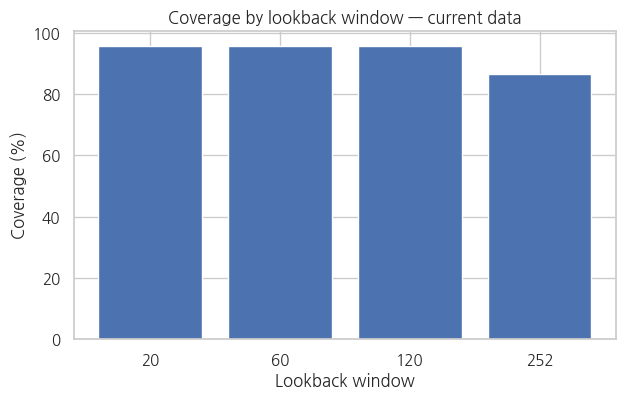

main_120_panel: (10370, 19)
common_4window_panel: (9397, 18)


In [11]:

# base120: 120일 리밸런싱 평가일에 20/60/120/252 Core 피처가 모두 존재하는 원본 패널
base120 = rebalance_120df.copy()

main_120_panel = base120.dropna(
    subset=["volatility_120d","beta_120d"]
).copy()
main_120_panel["abs_beta_120d"] = main_120_panel["beta_120d"].abs()

all_required = []
for w in WINDOWS:
    all_required += [f"volatility_{w}d", f"beta_{w}d"]

common_4window_panel = base120.dropna(subset=all_required).copy()

coverage_rows = []
for w in WINDOWS:
    valid = base120[[f"volatility_{w}d", f"beta_{w}d"]].notna().all(axis=1)
    coverage_rows.append({
        "window": w,
        "valid_rows": int(valid.sum()),
        "total_rows": len(base120),
        "coverage": valid.mean()
    })

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

plt.figure(figsize=(7,4))
plt.bar(coverage_df["window"].astype(str), coverage_df["coverage"] * 100)
plt.ylabel("Coverage (%)")
plt.xlabel("Lookback window")
plt.title("Coverage by lookback window — current data")
plt.show()

print("main_120_panel:", main_120_panel.shape)
print("common_4window_panel:", common_4window_panel.shape)


### [사전검증] 공식 리밸런싱 평가 기준일 확인

새 upstream 파일이 실제로 어떤 평가일을 포함하는지 확인합니다.

1. 공식 리밸런싱 간격 60/120/252별 평가일 개수·최초일·최종일
2. 평가일 Timeline
3. H3용 `120일 grid + 4-window complete Date/Ticker` 비율

> 20/60/120/252는 H3의 **Lookback window**, 60/120/252는 현재 제공된 **Rebalance interval**입니다.


,rebalance_interval,date_count,first_date,last_date
0,60,44,2016-01-04,2026-04-09
1,120,22,2016-01-04,2026-01-12
2,252,11,2016-01-04,2026-01-12


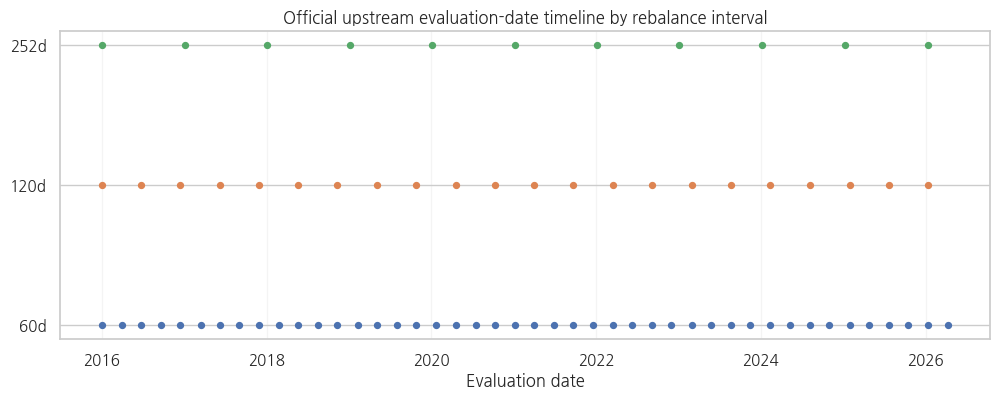

120d grid rows        : 10857
4-window complete rows: 9397
4-window complete ratio: 86.55%
4-window 비교 가능 평가일: 19
최신 비교 가능 평가일: 2026-01-12 00:00:00


In [12]:
eval_rows = []
for interval, df in rebalance_frames.items():
    dates = pd.Index(sorted(pd.to_datetime(df['Date'].dropna().unique())))
    eval_rows.append({
        'rebalance_interval': interval,
        'date_count': len(dates),
        'first_date': dates.min() if len(dates) else pd.NaT,
        'last_date': dates.max() if len(dates) else pd.NaT,
    })

eval_date_summary = pd.DataFrame(eval_rows)
display(eval_date_summary)

plt.figure(figsize=(12,4))
for i, interval in enumerate(REBALANCE_INTERVALS):
    dates = pd.Index(sorted(pd.to_datetime(rebalance_frames[interval]['Date'].dropna().unique())))
    plt.scatter(dates, np.full(len(dates), i), s=18, label=f'{interval}d rebalance')
plt.yticks(range(len(REBALANCE_INTERVALS)), [f'{x}d' for x in REBALANCE_INTERVALS])
plt.xlabel('Evaluation date')
plt.title('Official upstream evaluation-date timeline by rebalance interval')
plt.grid(axis='x', alpha=.2)
plt.show()

complete_ratio = len(common_4window_panel) / len(base120) if len(base120) else np.nan
print('120d grid rows        :', len(base120))
print('4-window complete rows:', len(common_4window_panel))
print('4-window complete ratio:', f'{complete_ratio:.2%}' if pd.notna(complete_ratio) else 'NA')

valid_count_by_date = (
    base120.assign(_complete=base120[all_required].notna().all(axis=1))
    .groupby('Date')['_complete'].sum()
)
usable_eval_dates = pd.Index(valid_count_by_date[valid_count_by_date >= 12].index).sort_values()
print('4-window 비교 가능 평가일:', len(usable_eval_dates))
print('최신 비교 가능 평가일:', usable_eval_dates.max() if len(usable_eval_dates) else None)


## [H0 실행 후 확인할 항목]

이 v15 파일은 새 upstream 데이터로 **재실행하기 위한 준비본**이므로, 기존 v14.9의 H0 수치 해석을 그대로 두지 않습니다.

위 셀 실행 후 다음을 확인합니다.

1. `final_df`의 기간 / 종목 수 / `Date+Ticker` 중복 / Close 결측
2. `rebalance_60/120/252df` 각각의 행 수 / 종목 수 / 평가일 수 / 중복
3. 각 리밸런싱 파일의 20/60/120/252 Volatility+Beta Coverage
4. Main `rebalance_120df`에서 `main_120_panel`과 `common_4window_panel` 표본 수
5. 공식 60/120/252 리밸런싱 평가일 Timeline

**이 결과를 확인한 뒤 H1~H5 결과를 새 데이터 기준으로 다시 해석합니다.**


# PART 1. 지표 정의

## 안정성 군집 입력
- **Volatility**: 낮을수록 상대적으로 안정
- **|Beta|**: 0에 가까울수록 시장민감도가 낮음

## 마지막 종목추천 지표
- **Momentum 120d**: `Close / Close.shift(120) - 1`
- **RSI 56d**: 56거래일 평균 상승폭/하락폭 기반 RSI

마지막에는 두 지표를 하나로 합쳐 한 번만 추천하지 않습니다.

1. **Momentum 단독**
2. **RSI 단독**
3. **Momentum + RSI 조합**

세 방식으로 각각 Top10 / Top3를 제시합니다.


In [13]:
indicator_definition = pd.DataFrame([
    ["Stability", "Volatility", "낮을수록 안정"],
    ["Stability", "|Beta|", "0에 가까울수록 안정"],
    ["Recommendation", "Momentum 120d", "높을수록 높은 순위"],
    ["Recommendation", "RSI 56d", "높을수록 높은 순위"],
], columns=["role", "indicator", "direction"])
display(indicator_definition)


,role,indicator,direction
0,Stability,Volatility,낮을수록 안정
1,Stability,|Beta|,0에 가까울수록 안정
2,Recommendation,Momentum 120d,높을수록 높은 순위
3,Recommendation,RSI 56d,높을수록 높은 순위


## 공통 실행 함수 준비

Lookback 비교를 K 선택보다 먼저 실행하기 위해, v17에서 뒤쪽에 있던 **K-Means snapshot / 미래 outcome / 날짜내 z-score 함수만 앞쪽으로 이동**합니다.

이 셀은 분석판정을 추가하지 않습니다.  
수식은 v17 기존 정의를 유지합니다.


In [14]:
def fit_kmeans_snapshot(g, window, k):
    temp = g.dropna(subset=[f"volatility_{window}d", f"beta_{window}d"]).copy()
    if len(temp) < max(k*4, 12):
        return None, None, None

    temp["abs_beta"] = temp[f"beta_{window}d"].abs()
    X = temp[[f"volatility_{window}d", "abs_beta"]]
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    raw = km.fit_predict(Xs)

    centers = pd.DataFrame(km.cluster_centers_, columns=["z_vol", "z_abs_beta"])
    centers["risk_center"] = centers.mean(axis=1)
    risk_order = centers["risk_center"].sort_values().index.tolist()
    rank_map = {raw_id: rank+1 for rank, raw_id in enumerate(risk_order)}

    temp["cluster_raw"] = raw
    temp["risk_rank"] = temp["cluster_raw"].map(rank_map)
    return temp, Xs, km


def within_date_z(df, col):
    def _z(s):
        sd = s.std(ddof=0)
        if pd.isna(sd) or sd == 0:
            return pd.Series(0.0, index=s.index)
        return (s - s.mean()) / sd
    return df.groupby("Date")[col].transform(_z)


price_panel = (
    daily_prices[["Date", "Ticker", "Close"]]
    .drop_duplicates(["Date", "Ticker"])
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
    .copy()
)


def calc_forward_mdd(close_array, horizon):
    n = len(close_array)
    result = np.full(n, np.nan, dtype=float)

    for i in range(n):
        path = close_array[i:i + horizon + 1]
        if len(path) < horizon + 1:
            continue
        running_peak = np.maximum.accumulate(path)
        drawdown = path / running_peak - 1.0
        result[i] = np.min(drawdown)

    return result


def calc_forward_volatility(close_array, horizon):
    n = len(close_array)
    result = np.full(n, np.nan, dtype=float)

    for i in range(n):
        path = close_array[i:i + horizon + 1]
        if len(path) < horizon + 1:
            continue

        returns = path[1:] / path[:-1] - 1.0
        if len(returns) < 2:
            continue

        result[i] = np.std(returns, ddof=1) * np.sqrt(252)

    return result


def build_forward_outcomes(price_df, horizons=(20, 60, 120, 252)):
    result_parts = []

    for ticker, ticker_df in price_df.groupby("Ticker", sort=False):
        ticker_df = ticker_df.sort_values("Date").copy()
        close_array = ticker_df["Close"].to_numpy(dtype=float)

        for h in horizons:
            ticker_df[f"future_vol_{h}d"] = calc_forward_volatility(close_array, h)
            ticker_df[f"future_mdd_{h}d"] = calc_forward_mdd(close_array, h)

        result_parts.append(ticker_df)

    result = pd.concat(result_parts, ignore_index=True)
    outcome_cols = []
    for h in horizons:
        outcome_cols += [f"future_vol_{h}d", f"future_mdd_{h}d"]

    return result[["Date", "Ticker"] + outcome_cols]


# 미래값은 군집 입력이 아니라 사후검증 outcome으로만 사용
forward_daily = build_forward_outcomes(
    price_panel,
    horizons=FUTURE_HORIZONS
)
print("forward_daily shape:", forward_daily.shape)


forward_daily shape: (1669599, 10)


# PART 2. Lookback 비교 — 20 / 60 / 120 / 252 → 120일 선택

먼저 기간을 비교합니다.

비교 항목:
- Coverage
- Stable 후보비율
- False-Stable
- Stable의 미래 120d MDD 중앙값
- MDD ≤ -15% 비율

**120일을 먼저 정하고 검증하는 순서가 아니라, 기간 비교 후 120일을 Main으로 선택합니다.**


,window,stable_share,stable_future_mdd_mean,stable_future_mdd_median,stable_mdd_le_15pct,false_stable,coverage
0,20,0.5437,-0.1667,-0.1459,0.4488,0.1771,0.9568
1,60,0.4771,-0.1581,-0.1380,0.4066,0.1283,0.9561
2,120,0.4266,-0.1566,-0.1365,0.3984,0.1170,0.9551
3,252,0.4069,-0.1543,-0.1339,0.3933,0.1091,0.8655


[표본 분모 주의]
- coverage 분모       : base120 전체 rows = 10857
- 성능 비교 공통표본  : common_4window_panel rows = 9397
※ coverage와 false_stable은 같은 분모가 아니므로 한 표에서 직접 비율 크기만 비교하지 않습니다.


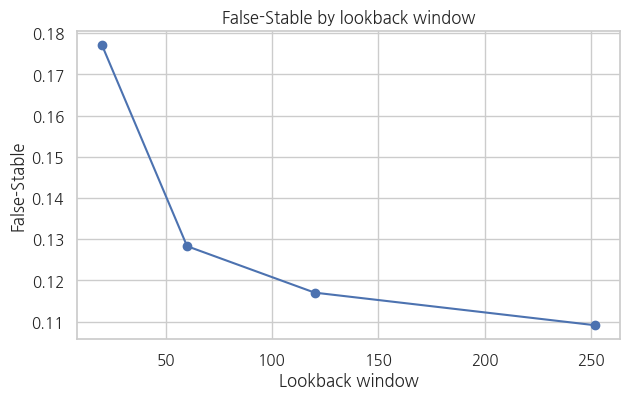

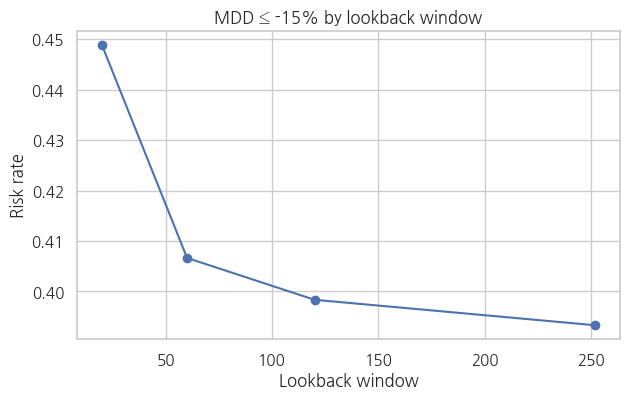

In [15]:
def label_window(panel, w):
    p = panel.dropna(subset=[f"volatility_{w}d", f"beta_{w}d"]).copy()
    out = []
    for dt, g in p.groupby("Date"):
        fitted, Xs, km = fit_kmeans_snapshot(g, w, 3)
        if fitted is None:
            continue
        fitted["stability_group"] = fitted["risk_rank"].map({1:"Stable",2:"Middle",3:"Risky"})
        fitted["window"] = w
        out.append(fitted[["Date","Ticker","stability_group","window"]])
    return pd.concat(out, ignore_index=True)

window_rows = []
window_detail = []

for w in WINDOWS:
    lab = label_window(common_4window_panel, w)
    h = 120
    temp = lab.merge(
        forward_daily[["Date","Ticker",f"future_mdd_{h}d",f"future_vol_{h}d"]],
        on=["Date","Ticker"], how="left"
    )
    stable = temp[temp["stability_group"].eq("Stable")].copy()

    # 같은 미래 risk 정의
    tmp2 = temp.dropna(subset=[f"future_mdd_{h}d",f"future_vol_{h}d"]).copy()
    tmp2["zv"] = within_date_z(tmp2, f"future_vol_{h}d")
    tmp2["zm"] = within_date_z(tmp2, f"future_mdd_{h}d")
    tmp2["fr"] = (tmp2["zv"] - tmp2["zm"]) / 2
    tmp2["future_risky"] = tmp2.groupby("Date")["fr"].transform(
        lambda s: s >= s.quantile(1-BASE_FUTURE_RISK_Q)
    )
    fs = tmp2.loc[tmp2["stability_group"].eq("Stable"), "future_risky"].mean()

    window_rows.append({
        "window": w,
        "stable_share": temp["stability_group"].eq("Stable").mean(),
        "stable_future_mdd_mean": stable[f"future_mdd_{h}d"].mean(),
        "stable_future_mdd_median": stable[f"future_mdd_{h}d"].median(),
        "stable_mdd_le_15pct": (stable[f"future_mdd_{h}d"] <= -0.15).mean(),
        "false_stable": fs
    })
    window_detail.append(temp)

window_compare = pd.DataFrame(window_rows).merge(
    coverage_df[["window","coverage"]], on="window", how="left"
)
display(window_compare)

print("[표본 분모 주의]")
print("- coverage 분모       : base120 전체 rows =", len(base120))
print("- 성능 비교 공통표본  : common_4window_panel rows =", len(common_4window_panel))
print("※ coverage와 false_stable은 같은 분모가 아니므로 한 표에서 직접 비율 크기만 비교하지 않습니다.")

fig_data = window_compare.copy()
for col, title, ylabel in [
    ("false_stable","False-Stable by lookback window","False-Stable"),
    ("stable_mdd_le_15pct","MDD ≤ -15% by lookback window","Risk rate"),
]:
    plt.figure(figsize=(7,4))
    plt.plot(fig_data["window"], fig_data[col], marker="o")
    plt.xlabel("Lookback window")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


## Lookback 해석

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


# PART 3. 선택된 120d 안정성 지표 검증 — Volatility + |Beta|


##Core 지표 2개 선택 근거 재확인 — 상관관계

이 노트북에서는 실제 120일 `Volatility`와 `|Beta|`의 Pearson / Spearman 상관계수를 확인합니다.

- 상관이 매우 높으면 두 변수가 비슷한 정보를 줄 수 있습니다.
- 상관이 낮거나 중간 정도면 서로 다른 위험축을 보완한다고 볼 수 있습니다.


Volatility vs Beta      Pearson  = 0.5261
Volatility vs Beta      Spearman = 0.5479
Volatility vs |Beta|    Pearson  = 0.5323
Volatility vs |Beta|    Spearman = 0.5484
2-feature 참고 VIF(|Beta| 기준) = 1.395

날짜별 Volatility vs |Beta| 상관 요약


,0
count,21.0000
mean,0.6735
std,0.1438
min,0.2666
25%,0.6135
50%,0.7093
75%,0.7725
max,0.8764


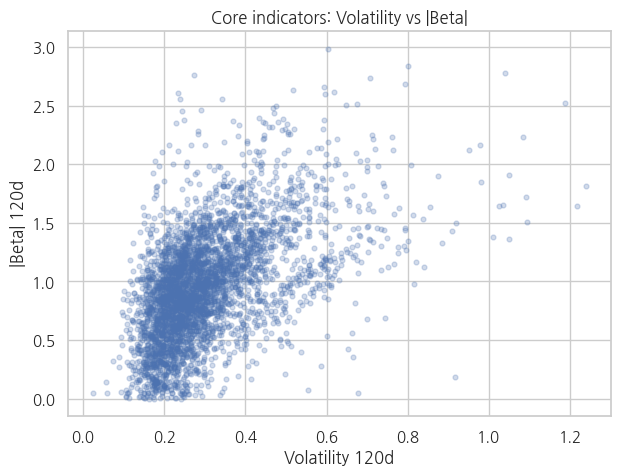

In [16]:
# corr_check: Volatility와 signed Beta / |Beta|의 중복 정도를 확인하는 표본
corr_check = main_120_panel[
    ["volatility_120d", "beta_120d", "abs_beta_120d"]
].dropna()

# signed_corr_*: 원래 Beta 부호를 유지했을 때의 상관
signed_corr_pearson = corr_check[
    ["volatility_120d", "beta_120d"]
].corr(method="pearson").iloc[0,1]
signed_corr_spearman = corr_check[
    ["volatility_120d", "beta_120d"]
].corr(method="spearman").iloc[0,1]

# abs_corr_*: 실제 K-Means 입력인 |Beta|와 Volatility의 상관
abs_corr_pearson = corr_check[
    ["volatility_120d", "abs_beta_120d"]
].corr(method="pearson").iloc[0,1]
abs_corr_spearman = corr_check[
    ["volatility_120d", "abs_beta_120d"]
].corr(method="spearman").iloc[0,1]

# vif_two_feature: 2변수일 때 r만으로 보는 참고용 공선성 지표
vif_two_feature = 1 / (1 - abs_corr_pearson**2) if abs(abs_corr_pearson) < 1 else np.inf

print(f"Volatility vs Beta      Pearson  = {signed_corr_pearson:.4f}")
print(f"Volatility vs Beta      Spearman = {signed_corr_spearman:.4f}")
print(f"Volatility vs |Beta|    Pearson  = {abs_corr_pearson:.4f}")
print(f"Volatility vs |Beta|    Spearman = {abs_corr_spearman:.4f}")
print(f"2-feature 참고 VIF(|Beta| 기준) = {vif_two_feature:.3f}")

# date_corr_abs: 날짜마다 Volatility와 |Beta| 상관이 얼마나 달라지는지 확인
date_corr_abs = (
    main_120_panel
    .groupby("Date")
    .apply(lambda g: g["volatility_120d"].corr(g["abs_beta_120d"]))
)
print("\n날짜별 Volatility vs |Beta| 상관 요약")
display(date_corr_abs.describe())

# plot_sample: 산점도 확인용 최대 4,000행 표본
plot_sample = corr_check.sample(
    min(4000, len(corr_check)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(7,5))
plt.scatter(
    plot_sample["volatility_120d"],
    plot_sample["abs_beta_120d"],
    alpha=0.25,
    s=12
)
plt.xlabel("Volatility 120d")
plt.ylabel("|Beta| 120d")
plt.title("Core indicators: Volatility vs |Beta|")
plt.show()

## 120d Volatility / |Beta| 해석

v17 실제 code output 기준:
- Pearson **0.5323**
- Spearman **0.5484**
- 참고 VIF **1.395**

두 축은 무관하지 않지만 완전히 같은 정보도 아닙니다.  
따라서 `Volatility + |Beta|`를 위험의 두 설명축으로 유지하되, 이후 Ablation에서 **2-Core가 단일지표보다 성능상 우월한지 별도 검증**합니다.


# PART 4. K=2~6 비교 → K=3 선택


,k,silhouette,dbi,ch,min_cluster_share,dates
0,2,0.4861,0.8109,535.7015,0.3262,21
1,3,0.4317,0.7979,556.5670,0.1312,21
2,4,0.3921,0.8458,544.9934,0.0746,21
3,5,0.3985,0.8013,544.8769,0.0503,21
4,6,0.3933,0.7798,551.6689,0.0307,21


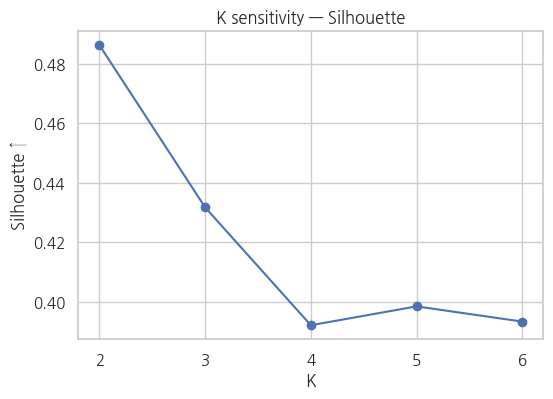

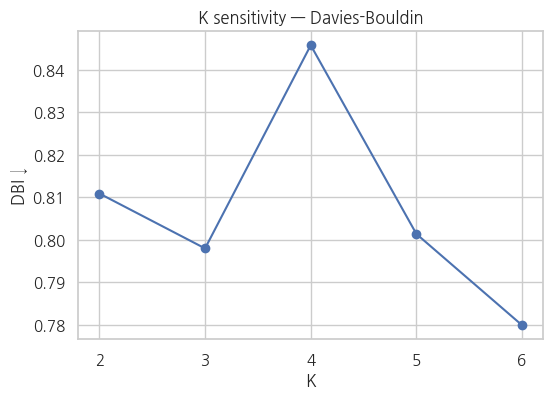

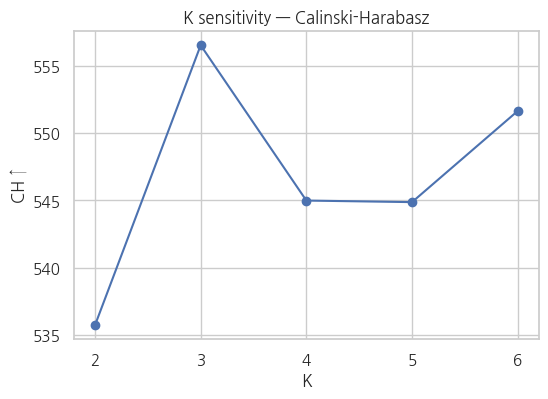

In [17]:
def fit_kmeans_snapshot(g, window, k):
    temp = g.dropna(subset=[f"volatility_{window}d", f"beta_{window}d"]).copy()
    if len(temp) < max(k*4, 12):
        return None, None, None

    temp["abs_beta"] = temp[f"beta_{window}d"].abs()
    X = temp[[f"volatility_{window}d", "abs_beta"]]
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    raw = km.fit_predict(Xs)

    # [기존 유지 + 설명 보강]
    # K-Means centroid는 표준화 공간에서 각 군집 관측치의 산술평균 위치입니다.
    # 두 축은 StandardScaler로 같은 z-score 단위가 되었고,
    # risk_center=(z_vol+z_abs_beta)/2는 "개별 종목 점수"가 아니라
    # 라벨이 없는 cluster ID를 Stable→Risky 순서로 정렬하기 위한 중심값입니다.
    # 이 1:1 평균은 미래성과에 맞춰 튜닝한 가중치가 아니며, 기존 v9 설정을 유지합니다.
    centers = pd.DataFrame(km.cluster_centers_, columns=["z_vol", "z_abs_beta"])
    centers["risk_center"] = centers.mean(axis=1)
    risk_order = centers["risk_center"].sort_values().index.tolist()
    rank_map = {raw_id: rank+1 for rank, raw_id in enumerate(risk_order)}

    temp["cluster_raw"] = raw
    temp["risk_rank"] = temp["cluster_raw"].map(rank_map)
    return temp, Xs, km

def evaluate_k(panel, window=120):
    rows = []
    for dt, g in panel.groupby("Date"):
        for k in K_CANDIDATES:
            fitted, Xs, km = fit_kmeans_snapshot(g, window, k)
            if fitted is None:
                continue
            shares = pd.Series(km.labels_).value_counts(normalize=True)
            rows.append({
                "Date": dt,
                "k": k,
                "silhouette": silhouette_score(Xs, km.labels_),
                "dbi": davies_bouldin_score(Xs, km.labels_),
                "ch": calinski_harabasz_score(Xs, km.labels_),
                "min_cluster_share": shares.min()
            })
    return pd.DataFrame(rows)

k_detail = evaluate_k(main_120_panel, 120)
k_summary = k_detail.groupby("k").agg(
    silhouette=("silhouette","mean"),
    dbi=("dbi","mean"),
    ch=("ch","mean"),
    min_cluster_share=("min_cluster_share","mean"),
    dates=("Date","nunique")
).reset_index()

display(k_summary)

for metric, title, ylabel in [
    ("silhouette", "K sensitivity — Silhouette", "Silhouette ↑"),
    ("dbi", "K sensitivity — Davies-Bouldin", "DBI ↓"),
    ("ch", "K sensitivity — Calinski-Harabasz", "CH ↑")
]:
    plt.figure(figsize=(6,4))
    plt.plot(k_summary["k"], k_summary[metric], marker="o")
    plt.xlabel("K")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(K_CANDIDATES)
    plt.show()

## K=2~6 내부지표 종합 순위

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


※ 별도 가중치는 사용하지 않았습니다. 평균순위가 낮을수록 여러 내부지표에서 전반적으로 상위입니다.


,k,silhouette,dbi,ch,min_cluster_share,silhouette_rank,dbi_rank,ch_rank,balance_rank,mean_rank,rank_wins
1,3,0.4317,0.7979,556.5670,0.1312,2.0000,2.0000,1.0000,2.0000,1.7500,1
0,2,0.4861,0.8109,535.7015,0.3262,1.0000,4.0000,5.0000,1.0000,2.7500,2
4,6,0.3933,0.7798,551.6689,0.0307,4.0000,1.0000,2.0000,5.0000,3.0000,1
3,5,0.3985,0.8013,544.8769,0.0503,3.0000,3.0000,4.0000,4.0000,3.5000,0
2,4,0.3921,0.8458,544.9934,0.0746,5.0000,5.0000,3.0000,3.0000,4.0000,0


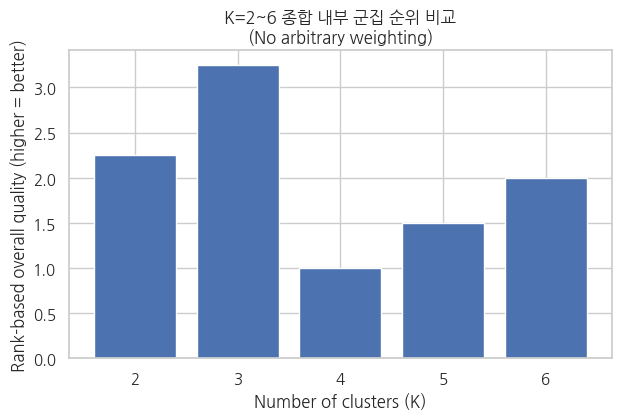


내부지표 평균순위 기준 가장 상위 K = 3
※ 이 결과만으로 최종 K를 확정하지 않고, 이후 Future MDD 단계성까지 함께 판단합니다.


In [18]:
# ============================================================
# [K 종합 순위] 임의 가중치 없이 내부 군집지표를 요약
# ============================================================

# k_rank: K별 내부 군집평가 결과를 복사한 순위 계산용 표
k_rank = k_summary.copy()

# silhouette_rank: Silhouette가 높을수록 1위
k_rank["silhouette_rank"] = (
    k_rank["silhouette"]
    .rank(ascending=False, method="min")
)

# dbi_rank: DBI는 낮을수록 1위
k_rank["dbi_rank"] = (
    k_rank["dbi"]
    .rank(ascending=True, method="min")
)

# ch_rank: CH가 높을수록 1위
k_rank["ch_rank"] = (
    k_rank["ch"]
    .rank(ascending=False, method="min")
)

# balance_rank: 최소 군집비율이 높을수록 극소 군집 위험이 적다는 보조순위
k_rank["balance_rank"] = (
    k_rank["min_cluster_share"]
    .rank(ascending=False, method="min")
)

# mean_rank: 네 내부지표의 순위를 단순 평균한 요약값
# 임의 가중치 없이 각 지표의 순위만 동일하게 집계합니다.
k_rank["mean_rank"] = (
    k_rank[
        [
            "silhouette_rank",
            "dbi_rank",
            "ch_rank",
            "balance_rank"
        ]
    ]
    .mean(axis=1)
)

# rank_wins: 각 K가 1위를 기록한 내부지표 개수
k_rank["rank_wins"] = (
    (
        k_rank[
            [
                "silhouette_rank",
                "dbi_rank",
                "ch_rank",
                "balance_rank"
            ]
        ] == 1
    )
    .sum(axis=1)
)

# k_rank_display: 발표/검토용 종합 순위표
k_rank_display = k_rank[
    [
        "k",
        "silhouette",
        "dbi",
        "ch",
        "min_cluster_share",
        "silhouette_rank",
        "dbi_rank",
        "ch_rank",
        "balance_rank",
        "mean_rank",
        "rank_wins"
    ]
].sort_values(
    ["mean_rank", "rank_wins"],
    ascending=[True, False]
)

print(
    "※ 별도 가중치는 사용하지 않았습니다. "
    "평균순위가 낮을수록 여러 내부지표에서 전반적으로 상위입니다."
)

display(k_rank_display)


# ------------------------------------------------------------
# 종합 순위 그래프
# ------------------------------------------------------------
# 평균순위는 낮을수록 좋으므로,
# 그래프에서는 해석을 쉽게 하기 위해 '종합 우수도 = 최대평균순위 - 평균순위 + 1'
# 로 방향만 뒤집습니다.
#
# 이 값은 임의 가중치가 아니라 평균순위의 표시방향만 바꾼 값입니다.
# ------------------------------------------------------------

max_mean_rank = k_rank["mean_rank"].max()

# rank_quality_score: 평균순위가 낮을수록 막대가 높게 보이도록 방향만 반전한 표시값
k_rank["rank_quality_score"] = (
    max_mean_rank - k_rank["mean_rank"] + 1
)

plt.figure(figsize=(7,4))

plt.bar(
    k_rank["k"].astype(str),
    k_rank["rank_quality_score"]
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Rank-based overall quality (higher = better)")
plt.title(
    "K=2~6 종합 내부 군집 순위 비교\n"
    "(No arbitrary weighting)"
)

plt.show()


# best_internal_k_rank: 내부지표 평균순위가 가장 좋은 K
best_internal_k_rank = int(
    k_rank
    .sort_values(
        ["mean_rank", "rank_wins"],
        ascending=[True, False]
    )
    .iloc[0]["k"]
)

print()
print(
    f"내부지표 평균순위 기준 가장 상위 K = "
    f"{best_internal_k_rank}"
)

print(
    "※ 이 결과만으로 최종 K를 확정하지 않고, "
    "이후 Future MDD 단계성까지 함께 판단합니다."
)

## K 선택 해석

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


# PART 5. K=3 군집화 — Stable / Middle / Risky


volatility_120d              abs_beta             
                           mean median count     mean median count
stability_group                                                   
Middle                   0.3198 0.2993  4498   1.1447 1.1172  4498
Risky                    0.5099 0.4660  1362   1.5736 1.5537  1362
Stable                   0.2261 0.2150  4510   0.5866 0.6118  4510

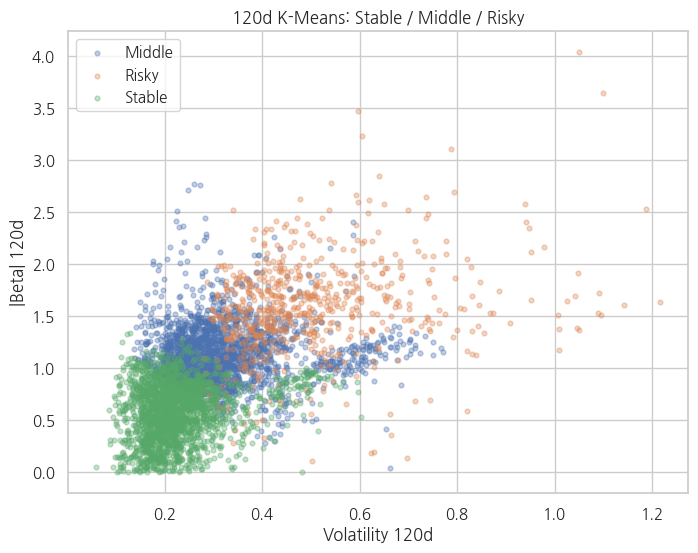

In [19]:
def label_three_clusters(panel, window=120):
    out = []
    for dt, g in panel.groupby("Date"):
        fitted, Xs, km = fit_kmeans_snapshot(g, window, 3)
        if fitted is None:
            continue
        rank_to_name = {1:"Stable", 2:"Middle", 3:"Risky"}
        fitted["stability_group"] = fitted["risk_rank"].map(rank_to_name)
        out.append(fitted)
    return pd.concat(out, ignore_index=True)

# market_clustered: 120일 Core K-Means로 Stable/Middle/Risky를 붙인 현재시점 결과
market_clustered = label_three_clusters(main_120_panel, 120)
market_clustered["market_stable"] = market_clustered["stability_group"].eq("Stable")

display(
    market_clustered.groupby("stability_group")[["volatility_120d","abs_beta"]]
    .agg(["mean","median","count"])
)

plot_df = market_clustered.sample(min(5000, len(market_clustered)), random_state=RANDOM_STATE)
plt.figure(figsize=(8,6))
for group, g in plot_df.groupby("stability_group"):
    plt.scatter(g["volatility_120d"], g["abs_beta"], s=12, alpha=0.35, label=group)
plt.xlabel("Volatility 120d")
plt.ylabel("|Beta| 120d")
plt.title("120d K-Means: Stable / Middle / Risky")
plt.legend()
plt.show()

In [20]:
# ============================================================
# [추가] 22개 rebalance 평가일 vs K-Means 실제 실행일 진단
# ============================================================
rebalance_dates = pd.Index(pd.to_datetime(rebalance_120df["Date"].dropna().unique())).sort_values()
clustered_dates = pd.Index(pd.to_datetime(market_clustered["Date"].dropna().unique())).sort_values()
missing_kmeans_dates = rebalance_dates.difference(clustered_dates)

print("rebalance_120 평가일 수 :", len(rebalance_dates))
print("K-Means 라벨 생성일 수  :", len(clustered_dates))
print("누락 평가일 수           :", len(missing_kmeans_dates))

diag_rows = []
for dt in missing_kmeans_dates:
    raw_g = rebalance_120df[pd.to_datetime(rebalance_120df["Date"]).eq(dt)].copy()
    valid_g = raw_g.dropna(subset=["volatility_120d", "beta_120d"]).copy()
    diag_rows.append({
        "Date": dt,
        "rebalance_rows": len(raw_g),
        "valid_core_rows": len(valid_g),
        "fit_min_required": 12,
        "diagnosis": (
            "VALID_CORE_ROWS_LT_12" if len(valid_g) < 12
            else "CHECK_FIT_OR_UPSTREAM_PANEL"
        )
    })

kmeans_date_diagnosis = pd.DataFrame(diag_rows)
display(kmeans_date_diagnosis)

rebalance_120 평가일 수 : 22
K-Means 라벨 생성일 수  : 21
누락 평가일 수           : 1


,Date,rebalance_rows,valid_core_rows,fit_min_required,diagnosis
0,2016-01-04,468,0,12,VALID_CORE_ROWS_LT_12


z_vol               z_abs_beta               risk_center              
                   mean  median count       mean  median count        mean  median count
stability_group                                                                         
Middle           0.1353  0.1074    21     0.4158  0.3778    21      0.2755  0.2536    21
Risky            2.0561  1.9168    21     1.5296  1.6120    21      1.7929  1.7081    21
Stable          -0.6984 -0.6863    21    -0.8590 -0.8356    21     -0.7787 -0.7844    21

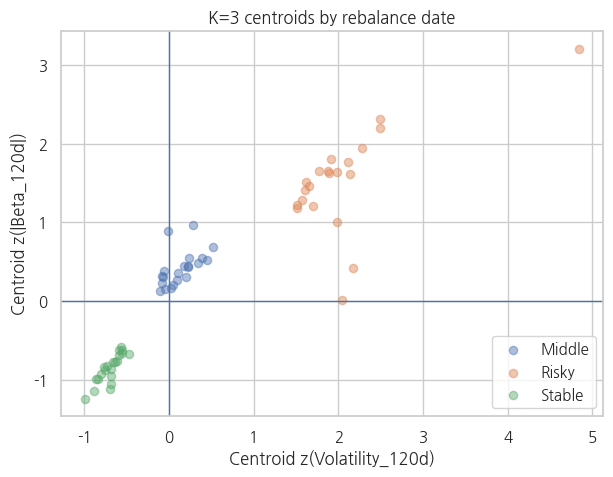

In [21]:
# ============================================================
# [추가] 날짜별 K=3 centroid 진단 — 기존 Core를 다시 선택하지 않음
# ============================================================
center_rows = []
for dt, g in main_120_panel.groupby("Date"):
    fitted, Xs, km = fit_kmeans_snapshot(g, 120, 3)
    if fitted is None:
        continue
    centers = pd.DataFrame(km.cluster_centers_, columns=["z_vol", "z_abs_beta"])
    centers["risk_center"] = centers[["z_vol", "z_abs_beta"]].mean(axis=1)
    risk_order = centers["risk_center"].sort_values().index.tolist()
    rank_map = {raw_id: rank + 1 for rank, raw_id in enumerate(risk_order)}
    centers["risk_rank"] = centers.index.map(rank_map)
    centers["stability_group"] = centers["risk_rank"].map({1:"Stable", 2:"Middle", 3:"Risky"})
    centers["Date"] = dt
    center_rows.append(centers.reset_index(names="cluster_raw"))

center_diagnostic_df = pd.concat(center_rows, ignore_index=True)
center_summary = center_diagnostic_df.groupby("stability_group")[["z_vol", "z_abs_beta", "risk_center"]].agg(["mean", "median", "count"])
display(center_summary)

plt.figure(figsize=(7, 5))
for group, g in center_diagnostic_df.groupby("stability_group"):
    plt.scatter(g["z_vol"], g["z_abs_beta"], alpha=0.45, s=35, label=group)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Centroid z(Volatility_120d)")
plt.ylabel("Centroid z(|Beta_120d|)")
plt.title("K=3 centroids by rebalance date")
plt.legend()
plt.show()

## K=3 군집구조 — 기존 실행 기준

v17 실제 code output 기준:
- Stable: Vol **0.2261** / |Beta| **0.5866** / n **4,510**
- Middle: **0.3198 / 1.1447 / 4,498**
- Risky: **0.5099 / 1.5736 / 1,362**
- 평균 risk_center: **-0.7787 / 0.2755 / 1.7929**

이 값은 FINAL Run All 후 재현 여부를 다시 확인합니다.


# PART 6. 군집 내 순위 → 각 군집 3개씩만 추출

여기서는 **Top30을 만들지 않습니다.**

각 평가일·각 군집 안에서:
1. Volatility가 낮을수록 높은 안정성 순위
2. |Beta|가 낮을수록 높은 안정성 순위
3. 두 percentile rank를 1:1 평균
4. 평균값이 낮을수록 `within_cluster_stability_rank`가 높음

최신 평가일에서:
- Stable 1~3위
- Middle 1~3위
- Risky 1~3위

**총 9개만 추출하고 Ticker를 직접 표시**합니다.

이 9개는 군집별 순위 예시이며, 마지막 수익성 추천 후보군을 9개로 제한하지 않습니다.


군집별 3개 선정 기준일: 2026-01-12
Stable 3 + Middle 3 + Risky 3 = 9 종목


,stability_group,within_cluster_stability_rank,Ticker,Company,Sector,volatility_120d,abs_beta,vol_rank_pct,abs_beta_rank_pct,within_cluster_stability_score
0,Stable,1,FE,FirstEnergy,Utilities,0.1327,0.0030,0.0036,0.0071,0.0053
1,Stable,2,BRK-B,Berkshire Hathaway,Financials,0.1369,0.0114,0.0107,0.0178,0.0142
2,Stable,3,WEC,WEC Energy Group,Utilities,0.1374,0.0186,0.0142,0.0391,0.0267
3,Middle,1,WAT,Waters Corporation,Health Care,0.2879,0.7272,0.2701,0.1379,0.2040
4,Middle,2,MAS,Masco,Industrials,0.2725,0.8063,0.1782,0.2414,0.2098
5,Middle,3,PCAR,Paccar,Industrials,0.2562,0.9323,0.1092,0.3161,0.2126
6,Risky,1,NCLH,Norwegian Cruise Line Holdings,Consumer Discretionary,0.4521,1.6532,0.1489,0.2340,0.1915
7,Risky,2,BLDR,Builders FirstSource,Industrials,0.4797,1.5305,0.3191,0.1915,0.2553
8,Risky,3,MCHP,Microchip Technology,Information Technology,0.4532,1.8639,0.1702,0.3830,0.2766


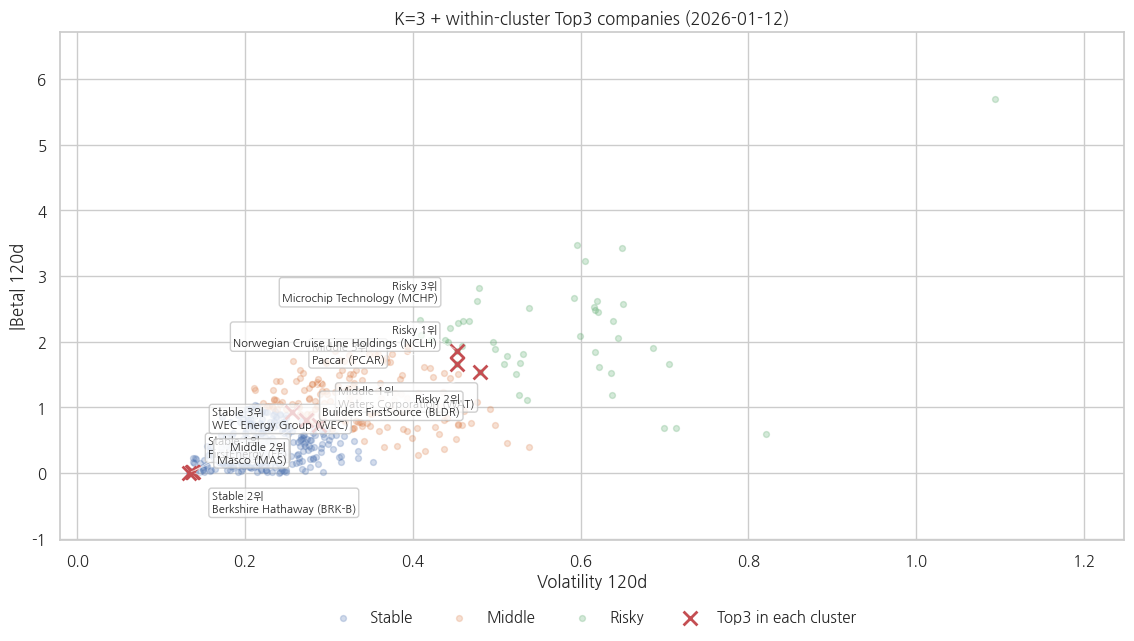

In [22]:
# ============================================================
# PART 6 — 군집 내부 안정성 순위 + 각 군집 Top3만 추출
# [수정] 기존 군집/순위 계산은 유지하고, 출력에 종목명/산업만 보강
# ============================================================
cluster_ranked = market_clustered.copy()
group_keys = ["Date", "stability_group"]
group_order = ["Stable", "Middle", "Risky"]

# 같은 군집 안에서 낮은 Vol / 낮은 |Beta|가 높은 안정성 순위
cluster_ranked["vol_rank_pct"] = (
    cluster_ranked.groupby(group_keys)["volatility_120d"]
    .rank(method="average", ascending=True, pct=True)
)
cluster_ranked["abs_beta_rank_pct"] = (
    cluster_ranked.groupby(group_keys)["abs_beta"]
    .rank(method="average", ascending=True, pct=True)
)

cluster_ranked["within_cluster_stability_score"] = (
    cluster_ranked["vol_rank_pct"] + cluster_ranked["abs_beta_rank_pct"]
) / 2

# 동점 재현성을 위해 score → Ticker 순으로 정렬 후 순번 부여
cluster_ranked = cluster_ranked.sort_values(
    ["Date", "stability_group", "within_cluster_stability_score", "Ticker"],
    ascending=[True, True, True, True]
).copy()

cluster_ranked["within_cluster_stability_rank"] = (
    cluster_ranked.groupby(group_keys).cumcount() + 1
)

latest_cluster_rank_date = pd.Timestamp(cluster_ranked["Date"].max())
latest_cluster_ranked = cluster_ranked.loc[
    cluster_ranked["Date"].eq(latest_cluster_rank_date)
].copy()

cluster_top3_each = (
    latest_cluster_ranked
    .loc[latest_cluster_ranked["within_cluster_stability_rank"] <= 3]
    .copy()
)

cluster_top3_each["stability_group"] = pd.Categorical(
    cluster_top3_each["stability_group"],
    categories=group_order,
    ordered=True
)
cluster_top3_each = cluster_top3_each.sort_values(
    ["stability_group", "within_cluster_stability_rank", "Ticker"]
)

# ------------------------------------------------------------
# [추가] Ticker → 종목명(Company) / Sector 매핑
# - 기존 sp500_universe만 사용
# - 내부 미매핑 값은 분석 로직에는 유지하되 발표 표/그래프에서는 노출하지 않음
# ------------------------------------------------------------
_top3_u = sp500_universe.copy()
_top3_u.columns = [str(c).strip().lower() for c in _top3_u.columns]
_top3_ticker_col = next((c for c in ["ticker", "symbol"] if c in _top3_u.columns), None)
_top3_company_col = next((c for c in ["company", "company_name", "security", "name"] if c in _top3_u.columns), None)
_top3_sector_col = next((c for c in ["sector", "gics sector"] if c in _top3_u.columns), None)

if _top3_ticker_col is None:
    raise ValueError(f"sp500_universe에서 Ticker 컬럼을 찾지 못했습니다: {_top3_u.columns.tolist()}")

_top3_cols = [_top3_ticker_col]
if _top3_company_col is not None:
    _top3_cols.append(_top3_company_col)
if _top3_sector_col is not None:
    _top3_cols.append(_top3_sector_col)

_top3_lookup = _top3_u[_top3_cols].copy()
_top3_rename = {_top3_ticker_col: "Ticker"}
if _top3_company_col is not None:
    _top3_rename[_top3_company_col] = "Company"
if _top3_sector_col is not None:
    _top3_rename[_top3_sector_col] = "Sector"
_top3_lookup = _top3_lookup.rename(columns=_top3_rename)
_top3_lookup["Ticker"] = normalize_ticker(_top3_lookup["Ticker"])

if "Company" not in _top3_lookup.columns:
    _top3_lookup["Company"] = _top3_lookup["Ticker"]
else:
    _top3_lookup["Company"] = _top3_lookup["Company"].astype(str).str.strip()
    _top3_lookup.loc[_top3_lookup["Company"].isin(["", "nan", "None"]), "Company"] = _top3_lookup["Ticker"]

if "Sector" not in _top3_lookup.columns:
    _top3_lookup["Sector"] = np.nan
else:
    _top3_lookup["Sector"] = _top3_lookup["Sector"].astype(str).str.strip()
    _top3_lookup.loc[
        _top3_lookup["Sector"].str.upper().isin(["UNKNOWN", "NAN", "NONE", ""]),
        "Sector"
    ] = np.nan

_top3_lookup = _top3_lookup[["Ticker", "Company", "Sector"]].drop_duplicates("Ticker", keep="first")

cluster_top3_each = cluster_top3_each.merge(
    _top3_lookup,
    on="Ticker",
    how="left",
    validate="many_to_one"
)
cluster_top3_each["Company"] = cluster_top3_each["Company"].fillna(cluster_top3_each["Ticker"])

print("군집별 3개 선정 기준일:", latest_cluster_rank_date.date())
print("Stable 3 + Middle 3 + Risky 3 =", len(cluster_top3_each), "종목")

display(
    cluster_top3_each[[
        "stability_group",
        "within_cluster_stability_rank",
        "Ticker",
        "Company",
        "Sector",
        "volatility_120d",
        "abs_beta",
        "vol_rank_pct",
        "abs_beta_rank_pct",
        "within_cluster_stability_score",
    ]]
)

# ------------------------------------------------------------
# [수정] Top3 시각화 — 종목명 + Ticker 표시, 라벨 겹침 최소화
# ------------------------------------------------------------
plt.figure(figsize=(11.5, 7.2))
for group_name in group_order:
    g = latest_cluster_ranked.loc[
        latest_cluster_ranked["stability_group"].eq(group_name)
    ]
    plt.scatter(
        g["volatility_120d"],
        g["abs_beta"],
        s=18,
        alpha=0.25,
        label=group_name
    )

plt.scatter(
    cluster_top3_each["volatility_120d"],
    cluster_top3_each["abs_beta"],
    s=100,
    marker="x",
    linewidths=2,
    label="Top3 in each cluster"
)

# 9개 라벨을 서로 다른 방향으로 배치해 겹침을 최소화
_label_offsets = {
    ("Stable", 1): (14, 18),
    ("Stable", 2): (14, -22),
    ("Stable", 3): (14, 38),
    ("Middle", 1): (14, 20),
    ("Middle", 2): (-14, -24),
    ("Middle", 3): (14, 42),
    ("Risky", 1): (-14, 20),
    ("Risky", 2): (-14, -24),
    ("Risky", 3): (-14, 42),
}

for _, row in cluster_top3_each.iterrows():
    group_name = str(row["stability_group"])
    rank_no = int(row["within_cluster_stability_rank"])
    dx, dy = _label_offsets.get((group_name, rank_no), (10, 10))
    company = str(row["Company"]).strip()
    label = f"{group_name} {rank_no}위\n{company} ({row['Ticker']})"
    plt.annotate(
        label,
        (row["volatility_120d"], row["abs_beta"]),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="left" if dx >= 0 else "right",
        va="center",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.75, ec="0.75"),
        arrowprops=dict(arrowstyle="-", lw=0.7, alpha=0.6),
        annotation_clip=False,
    )

plt.xlabel("Volatility 120d")
plt.ylabel("|Beta| 120d")
plt.title(f"K=3 + within-cluster Top3 companies ({latest_cluster_rank_date.date()})")
plt.margins(x=0.16, y=0.18)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()


# PART 7. 기존 v17 안정성 검증 — 미래위험 / False-Stable / Ablation


In [23]:
# 현재 K=3 라벨과 미래 outcome 연결
# 미래정보는 군집 생성/군집순위에 사용하지 않음
eval_panel = (
    market_clustered
    .merge(
        forward_daily,
        on=["Date", "Ticker"],
        how="left",
        validate="one_to_one"
    )
)

print("미래 위험 merge 완료")
print("eval_panel shape:", eval_panel.shape)

future_cols = [c for c in eval_panel.columns if c.startswith("future_")]
display(eval_panel[future_cols].notna().mean().to_frame("coverage"))


미래 위험 merge 완료
eval_panel shape: (10370, 32)


,coverage
future_vol_20d,0.9988
future_mdd_20d,0.9988
future_vol_60d,0.9967
future_mdd_60d,0.9967
future_vol_120d,0.9460
future_mdd_120d,0.9460
future_vol_252d,0.8922
future_mdd_252d,0.8922


## Stable / Middle / Risky 미래 MDD 직접 검증

이 섹션이 핵심 질문에 답합니다.

> **Volatility + |Beta|만으로 Stable이라고 뽑은 종목이 실제 미래에도 덜 무너졌는가?**

평균/중앙값뿐 아니라 MDD -10/-15/-20% 발생률까지 확인합니다.


,group,n_mdd,n_vol,future_vol_mean,future_mdd_mean,future_mdd_median,mdd_le_10pct,mdd_le_15pct,mdd_le_20pct
0,Middle,4306,4306,0.3174,-0.1944,-0.1701,0.8525,0.6020,0.3751
1,Risky,1306,1306,0.4738,-0.2797,-0.2472,0.9640,0.8254,0.6547
2,Stable,4198,4198,0.2407,-0.1516,-0.1311,0.7025,0.4092,0.2122


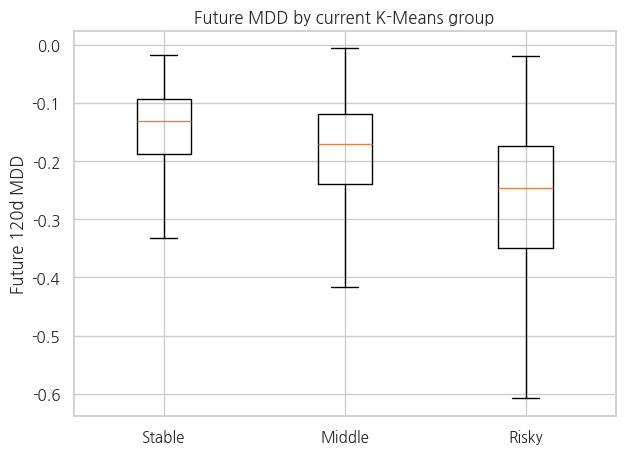

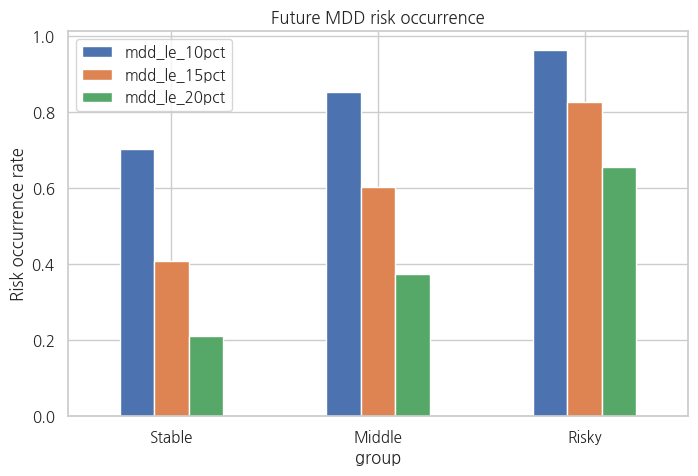

In [24]:
# mdd_rate: 미래 MDD가 실제로 존재하는 행만 분모로 사용해 임계값 초과율 계산
def mdd_rate(series, threshold):
    valid = series.dropna()
    if len(valid) == 0:
        return np.nan
    return (valid <= threshold).mean()

# mdd_group_summary: Stable/Middle/Risky별 미래 Volatility·MDD 결과 요약
def mdd_group_summary(df, horizon=120):
    rows = []
    col_mdd = f"future_mdd_{horizon}d"
    col_vol = f"future_vol_{horizon}d"

    for group, g in df.groupby("stability_group"):
        valid_mdd = g[col_mdd].dropna()
        valid_vol = g[col_vol].dropna()

        row = {
            "group": group,
            "n_mdd": len(valid_mdd),
            "n_vol": len(valid_vol),
            "future_vol_mean": valid_vol.mean(),
            "future_mdd_mean": valid_mdd.mean(),
            "future_mdd_median": valid_mdd.median(),
        }

        for th in MDD_THRESHOLDS:
            row[f"mdd_le_{int(abs(th)*100)}pct"] = mdd_rate(valid_mdd, th)

        rows.append(row)

    return pd.DataFrame(rows)

# mdd_summary_120: 120일 미래위험의 Stable/Middle/Risky 비교표
mdd_summary_120 = mdd_group_summary(eval_panel, 120)
display(mdd_summary_120)

# box_data: 그룹별 유효한 120일 미래 MDD 값
groups_order = ["Stable","Middle","Risky"]
box_data = [
    eval_panel.loc[
        eval_panel["stability_group"].eq(g),
        "future_mdd_120d"
    ].dropna()
    for g in groups_order
]

plt.figure(figsize=(7,5))
plt.boxplot(box_data, labels=groups_order, showfliers=False)
plt.ylabel("Future 120d MDD")
plt.title("Future MDD by current K-Means group")
plt.show()

# risk_plot: 그룹별 -10/-15/-20% MDD 발생률
risk_plot = mdd_summary_120.set_index("group")
cols = ["mdd_le_10pct","mdd_le_15pct","mdd_le_20pct"]
risk_plot.loc[groups_order, cols].plot(kind="bar", figsize=(8,5))
plt.ylabel("Risk occurrence rate")
plt.title("Future MDD risk occurrence")
plt.xticks(rotation=0)
plt.show()

## [H1 미래검증 최종 해석] Stable/Middle/Risky는 미래위험을 상대적으로 구분함

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## K=2 vs K=3 — 미래 MDD 분리력 비교

내부 군집지표에서 K=2가 더 좋더라도, K=3이 Stable/Middle/Risky라는 **단계적 위험구조**를 실제 미래 MDD에서 잘 보여준다면 분석 목적상 K=3을 선택할 근거가 됩니다.


In [25]:
def label_k_for_future(panel, window, k):
    out = []
    for dt, g in panel.groupby("Date"):
        fitted, Xs, km = fit_kmeans_snapshot(g, window, k)
        if fitted is None:
            continue
        fitted["k"] = k
        out.append(fitted[["Date","Ticker","risk_rank","k"]])
    return pd.concat(out, ignore_index=True)

k2 = label_k_for_future(main_120_panel, 120, 2).merge(
    forward_daily[["Date","Ticker","future_mdd_120d"]],
    on=["Date","Ticker"], how="left"
)
k3 = label_k_for_future(main_120_panel, 120, 3).merge(
    forward_daily[["Date","Ticker","future_mdd_120d"]],
    on=["Date","Ticker"], how="left"
)

k_future_compare = pd.concat([
    k2.groupby("risk_rank")["future_mdd_120d"].agg(["mean","median","count"]).assign(k=2),
    k3.groupby("risk_rank")["future_mdd_120d"].agg(["mean","median","count"]).assign(k=3),
]).reset_index()

display(k_future_compare)

,risk_rank,mean,median,count,k
0,1,-0.1622,-0.1415,6564,2
1,2,-0.2386,-0.2073,3246,2
2,1,-0.1516,-0.1311,4198,3
3,2,-0.1944,-0.1701,4306,3
4,3,-0.2797,-0.2472,1306,3


## [H1 K=2 vs K=3] 미래 MDD 기준으로 K=3의 3단계 해상도는 확인됨

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## False-Stable

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


KMeans Stable False-Stable (future top 30%) = 12.0772%


,future_risky_top,false_stable_rate
0,0.2000,0.0669
1,0.3000,0.1208
2,0.4000,0.1837


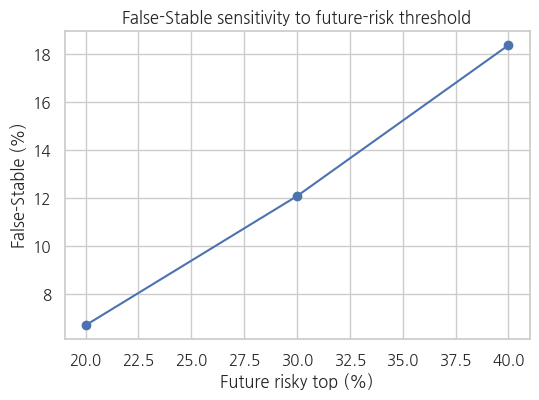

In [26]:
# [변경] std가 NaN/0인 그룹을 명시적으로 처리합니다.
def within_date_z(df, col):
    def _z(s):
        sd = s.std(ddof=0)
        if pd.isna(sd) or sd == 0:
            return pd.Series(0.0, index=s.index)
        return (s - s.mean()) / sd
    return df.groupby("Date")[col].transform(_z)

# risk_eval: 미래 Volatility/MDD가 모두 있는 행에서 False-Stable을 평가하는 표
risk_eval = eval_panel.dropna(subset=["future_vol_120d","future_mdd_120d"]).copy()
risk_eval["z_future_vol"] = within_date_z(risk_eval, "future_vol_120d")
risk_eval["z_future_drawdown"] = within_date_z(risk_eval, "future_mdd_120d")
risk_eval["future_risk_score"] = (risk_eval["z_future_vol"] - risk_eval["z_future_drawdown"]) / 2

# 기본 미래 Risky 상위 30%
risk_eval["future_risky_30"] = risk_eval.groupby("Date")["future_risk_score"].transform(
    lambda s: s >= s.quantile(1 - BASE_FUTURE_RISK_Q)
)

# KMeans Stable의 False-Stable
fs_kmeans = risk_eval.loc[risk_eval["market_stable"], "future_risky_30"].mean()
print(f"KMeans Stable False-Stable (future top 30%) = {fs_kmeans:.4%}")

# 미래 risky threshold 20/30/40%
rows = []
for q in FUTURE_RISK_Q_SENSITIVITY:
    temp = risk_eval.copy()
    flag = temp.groupby("Date")["future_risk_score"].transform(lambda s: s >= s.quantile(1-q))
    fs = flag[temp["market_stable"]].mean()
    rows.append({"future_risky_top": q, "false_stable_rate": fs})
future_threshold_df = pd.DataFrame(rows)
display(future_threshold_df)

plt.figure(figsize=(6,4))
plt.plot(future_threshold_df["future_risky_top"]*100, future_threshold_df["false_stable_rate"]*100, marker="o")
plt.xlabel("Future risky top (%)")
plt.ylabel("False-Stable (%)")
plt.title("False-Stable sensitivity to future-risk threshold")
plt.show()

## [H1 False-Stable 최종 해석]

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


# H2. 2-Core Ablation — Volatility only / |Beta| only / Vol+|Beta|


,policy,n,share,false_stable,future_mdd_mean,future_mdd_median,mdd_le_15
0,Volatility only,4198,0.4279,0.0867,-0.1474,-0.1279,0.3892
1,|Beta| only,4198,0.4279,0.1610,-0.1578,-0.1371,0.4340
2,Volatility + |Beta| K-Means,4198,0.4279,0.1208,-0.1516,-0.1311,0.4092


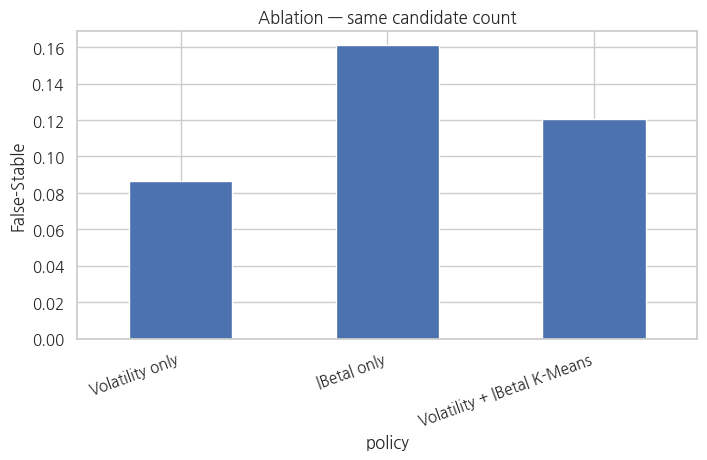

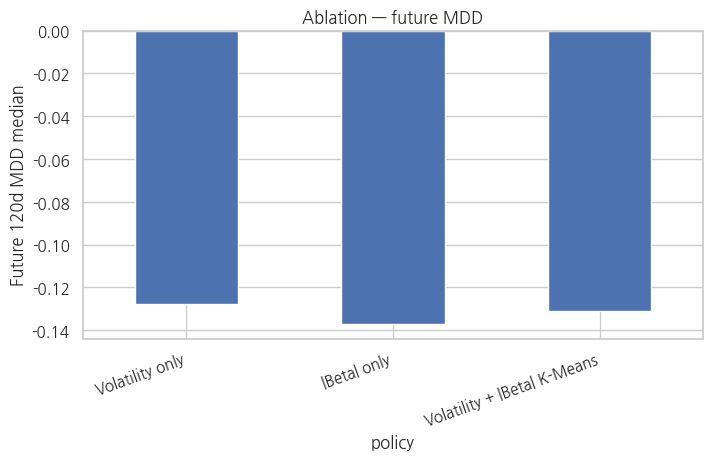

In [27]:
# ============================================================
# [추가] date-wise candidate-count matched Ablation
# ============================================================
ablation = risk_eval[[
    "Date", "Ticker", "volatility_120d", "abs_beta",
    "market_stable", "future_risky_30", "future_mdd_120d"
]].copy()

ablation["vol_only"] = False
ablation["beta_only"] = False

for dt, idx in ablation.groupby("Date").groups.items():
    sub = ablation.loc[idx]
    n_select = int(sub["market_stable"].sum())
    if n_select <= 0:
        continue
    vol_idx = sub.nsmallest(n_select, "volatility_120d").index
    beta_idx = sub.nsmallest(n_select, "abs_beta").index
    ablation.loc[vol_idx, "vol_only"] = True
    ablation.loc[beta_idx, "beta_only"] = True

ablation["two_axis_kmeans"] = ablation["market_stable"]

def summarize_ablation(flag_col, name):
    g = ablation[ablation[flag_col]].copy()
    valid_mdd = g["future_mdd_120d"].dropna()
    return {
        "policy": name,
        "n": len(g),
        "share": ablation[flag_col].mean(),
        "false_stable": g["future_risky_30"].dropna().mean(),
        "future_mdd_mean": valid_mdd.mean(),
        "future_mdd_median": valid_mdd.median(),
        "mdd_le_15": (valid_mdd <= -0.15).mean(),
    }

ablation_summary = pd.DataFrame([
    summarize_ablation("vol_only", "Volatility only"),
    summarize_ablation("beta_only", "|Beta| only"),
    summarize_ablation("two_axis_kmeans", "Volatility + |Beta| K-Means"),
])
display(ablation_summary)

plt.figure(figsize=(8,4))
ablation_summary.set_index("policy")["false_stable"].plot(kind="bar")
plt.ylabel("False-Stable")
plt.title("Ablation — same candidate count")
plt.xticks(rotation=20, ha="right")
plt.show()

plt.figure(figsize=(8,4))
ablation_summary.set_index("policy")["future_mdd_median"].plot(kind="bar")
plt.ylabel("Future 120d MDD median")
plt.title("Ablation — future MDD")
plt.xticks(rotation=20, ha="right")
plt.show()

## Ablation 판정

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


# PART 8. 252일 보강 / Shock — v17 기존 검증


##252일 장기 보강

세 정책을 비교합니다.

1. `120 Stable`
2. `120 Stable + 252 Not Risky`
3. `120 Stable + 252 Stable`

252를 무조건 필터로 쓰지 않습니다.  
후보 수 감소 대비 False-Stable/MDD 개선이 충분할 때만 보강효과가 있다고 판단합니다.


In [28]:
# 252일 그룹 생성
lab252 = label_window(base120.dropna(subset=["volatility_252d","beta_252d"]), 252)
lab252 = lab252.rename(columns={"stability_group":"stability_252"})

policy_252 = eval_panel.merge(
    lab252[["Date","Ticker","stability_252"]],
    on=["Date","Ticker"], how="left"
)

policy_252["p120"] = policy_252["stability_group"].eq("Stable")
policy_252["p120_252_not_risky"] = policy_252["p120"] & ~policy_252["stability_252"].eq("Risky")
policy_252["p120_252_stable"] = policy_252["p120"] & policy_252["stability_252"].eq("Stable")

# future risky merge
policy_252 = policy_252.merge(
    risk_eval[["Date","Ticker","future_risky_30"]],
    on=["Date","Ticker"], how="left"
)

# summarize_policy: 후보 유지율·False-Stable·미래 MDD 위험을 한 번에 비교하는 함수
def summarize_policy(df, flag_col, name):
    g = df[df[flag_col]].copy()

    # valid_mdd: 미래 120일 MDD가 실제로 계산된 후보만 사용
    valid_mdd = g["future_mdd_120d"].dropna()

    return {
        "policy": name,
        "n": len(g),
        "share": df[flag_col].mean(),
        "false_stable": g["future_risky_30"].dropna().mean(),
        "future_mdd_n": len(valid_mdd),
        "future_mdd_mean": valid_mdd.mean(),
        "future_mdd_median": valid_mdd.median(),
        "mdd_le_10": mdd_rate(valid_mdd, -0.10),
        "mdd_le_15": mdd_rate(valid_mdd, -0.15),
        "mdd_le_20": mdd_rate(valid_mdd, -0.20),
    }

policy_252_summary = pd.DataFrame([
    summarize_policy(policy_252, "p120", "120 Stable"),
    summarize_policy(policy_252, "p120_252_not_risky", "120 + 252 Not-Risky"),
    summarize_policy(policy_252, "p120_252_stable", "120 + 252 Stable"),
])
display(policy_252_summary)

,policy,n,share,false_stable,future_mdd_n,future_mdd_mean,future_mdd_median,mdd_le_10,mdd_le_15,mdd_le_20
0,120 Stable,4510,0.4349,0.1208,4198,-0.1516,-0.1311,0.7025,0.4092,0.2122
1,120 + 252 Not-Risky,4495,0.4335,0.1200,4185,-0.1516,-0.1310,0.7020,0.4081,0.2122
2,120 + 252 Stable,3408,0.3286,0.0982,3176,-0.1519,-0.1319,0.7135,0.4099,0.2078


## [H3-1 252일 추가가치] 252일은 확인 플래그로는 의미가 있으나 기본 강제필터 근거는 약함

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


# [추가 검증 — H3 보강] 위험시기 상대방어력 + 군집 유지성 확인

기존 가설 번호를 새로 만들지 않고 **120일 Whole-Market Core의 위기구간 보강검증**으로 유지합니다.

사건:
- 2018 Q4
- COVID-19
- 2022 Bear Market
- 2025 Tariff Shock

검증은 두 질문을 분리합니다.

1. **상대방어력:** 위기 전에 Stable로 분류된 종목이 위기 중 Risky보다 실제 MDD/Volatility가 낮았는가?
2. **군집 유지성:** 위기 전 Stable/Middle/Risky가 위기 중(해당 시점에 평가일이 없으면 직후 첫 평가일)에도 같은 군집에 얼마나 남았고, 어느 군집으로 이동했는가?

기존 MDD/Volatility 계산은 그대로 유지하고, 두 번째 질문의 **유지율/이동률 표와 시각화만 추가**합니다.


In [29]:

SHOCKS = {
    "2018_Q4": ("2018-10-01","2018-12-24"),
    "COVID_2020": ("2020-02-19","2020-04-30"),
    "2022_BEAR": ("2022-01-03","2022-10-12"),
    "2025_TARIFF": ("2025-04-02","2025-05-30"),
}

market_days = pd.Index(sorted(pd.to_datetime(daily_prices["Date"].dropna().unique())))

def equal_trading_day_windows(start, end):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    shock = market_days[(market_days >= start) & (market_days <= end)]
    if len(shock) == 0:
        return None

    n = len(shock)
    before = market_days[market_days < start]
    after = market_days[market_days > end]

    pre = before[-n:] if len(before) >= n else before
    post = after[:n] if len(after) >= n else after

    return {"PRE": pre, "SHOCK": shock, "POST": post}

def shock_period_stats(price_df, dates):
    x = price_df.loc[
        price_df["Date"].isin(dates),
        ["Date","Ticker","Close"]
    ].copy()

    rows = []
    for ticker, g in x.groupby("Ticker"):
        g = g.sort_values("Date")
        if len(g) < 3:
            continue

        ret = g["Close"].pct_change(fill_method=None).dropna()
        realized_vol = (
            ret.std(ddof=1) * np.sqrt(252)
            if len(ret) >= 2 else np.nan
        )

        arr = g["Close"].to_numpy(dtype=float)
        peak = np.maximum.accumulate(arr)
        realized_mdd = np.min(arr / peak - 1.0)

        rows.append({
            "Ticker": ticker,
            "realized_vol": realized_vol,
            "realized_mdd": realized_mdd,
            "obs": len(g),
        })

    return pd.DataFrame(rows)

shock_rows = []
shock_window_rows = []
decision_dates = pd.Index(sorted(pd.to_datetime(market_clustered["Date"].dropna().unique())))

for shock_name, (start, end) in SHOCKS.items():
    shock_start = pd.Timestamp(start)
    previous = decision_dates[decision_dates < shock_start]

    if len(previous) == 0:
        continue

    anchor_date = previous.max()
    anchor_groups = market_clustered.loc[
        market_clustered["Date"].eq(anchor_date),
        ["Ticker","stability_group"]
    ].drop_duplicates("Ticker")

    windows = equal_trading_day_windows(start, end)
    if windows is None:
        continue

    shock_window_rows.append({
        "shock": shock_name,
        "anchor_date": anchor_date,
        "shock_days": len(windows["SHOCK"]),
        "pre_days": len(windows["PRE"]),
        "post_days": len(windows["POST"]),
    })

    for phase, dates in windows.items():
        stats = shock_period_stats(daily_prices, dates)
        stats = stats.merge(anchor_groups, on="Ticker", how="inner")
        if stats.empty:
            continue

        agg = (
            stats.groupby("stability_group")
            .agg(
                mean_vol=("realized_vol","mean"),
                median_vol=("realized_vol","median"),
                mean_mdd=("realized_mdd","mean"),
                median_mdd=("realized_mdd","median"),
                n=("Ticker","size"),
            )
            .reset_index()
        )
        agg["shock"] = shock_name
        agg["phase"] = phase
        agg["anchor_date"] = anchor_date
        shock_rows.append(agg)

shock_window_info = pd.DataFrame(shock_window_rows)
shock_summary = (
    pd.concat(shock_rows, ignore_index=True)
    if shock_rows else pd.DataFrame()
)

display(shock_window_info)
display(shock_summary)

# SHOCK 구간에서 Stable vs Risky를 직접 비교하는 발표용 계산표
shock_event_check = pd.DataFrame()
if len(shock_summary):
    s = shock_summary[shock_summary["phase"].eq("SHOCK")].copy()

    mdd_p = s.pivot(index="shock", columns="stability_group", values="median_mdd")
    vol_p = s.pivot(index="shock", columns="stability_group", values="median_vol")

    rows = []
    for event in sorted(s["shock"].unique()):
        stable_mdd = mdd_p.loc[event, "Stable"] if "Stable" in mdd_p.columns else np.nan
        risky_mdd = mdd_p.loc[event, "Risky"] if "Risky" in mdd_p.columns else np.nan
        stable_vol = vol_p.loc[event, "Stable"] if "Stable" in vol_p.columns else np.nan
        risky_vol = vol_p.loc[event, "Risky"] if "Risky" in vol_p.columns else np.nan

        rows.append({
            "shock": event,
            "Stable_MDD": stable_mdd,
            "Risky_MDD": risky_mdd,
            "Stable_minus_Risky_MDD": stable_mdd - risky_mdd,
            "Stable_Vol": stable_vol,
            "Risky_Vol": risky_vol,
            "Stable_minus_Risky_Vol": stable_vol - risky_vol,
            "Stable_better_MDD": stable_mdd > risky_mdd if pd.notna(stable_mdd) and pd.notna(risky_mdd) else np.nan,
            "Stable_better_Vol": stable_vol < risky_vol if pd.notna(stable_vol) and pd.notna(risky_vol) else np.nan,
        })

    shock_event_check = pd.DataFrame(rows)
    display(shock_event_check)


,shock,anchor_date,shock_days,pre_days,post_days
0,2018_Q4,2018-05-22,59,59,59
1,COVID_2020,2019-10-25,51,51,51
2,2022_BEAR,2021-09-22,196,196,196
3,2025_TARIFF,2025-01-28,41,41,41


,stability_group,mean_vol,median_vol,mean_mdd,median_mdd,n,shock,phase,anchor_date
0,Middle,0.2125,0.1988,-0.0822,-0.0716,278,2018_Q4,PRE,2018-05-22
1,Risky,0.3123,0.2945,-0.1431,-0.1376,62,2018_Q4,PRE,2018-05-22
2,Stable,0.1738,0.1614,-0.0681,-0.0580,149,2018_Q4,PRE,2018-05-22
3,Middle,0.3382,0.3230,-0.2387,-0.2296,277,2018_Q4,SHOCK,2018-05-22
4,Risky,0.4734,0.4521,-0.3216,-0.3149,61,2018_Q4,SHOCK,2018-05-22
5,Stable,0.2759,0.2561,-0.1658,-0.1364,148,2018_Q4,SHOCK,2018-05-22
6,Middle,0.2544,0.2417,-0.0758,-0.0622,275,2018_Q4,POST,2018-05-22
7,Risky,0.3779,0.3412,-0.1188,-0.1009,61,2018_Q4,POST,2018-05-22
8,Stable,0.2140,0.1832,-0.0613,-0.0443,145,2018_Q4,POST,2018-05-22
9,Middle,0.2121,0.2019,-0.0844,-0.0792,237,COVID_2020,PRE,2019-10-25


,shock,Stable_MDD,Risky_MDD,Stable_minus_Risky_MDD,Stable_Vol,Risky_Vol,Stable_minus_Risky_Vol,Stable_better_MDD,Stable_better_Vol
0,2018_Q4,-0.1364,-0.3149,0.1785,0.2561,0.4521,-0.1960,True,True
1,2022_BEAR,-0.2574,-0.4140,0.1566,0.2743,0.5027,-0.2284,True,True
2,2025_TARIFF,-0.1198,-0.1917,0.0719,0.3506,0.7389,-0.3884,True,True
3,COVID_2020,-0.3626,-0.5299,0.1673,0.8167,1.1075,-0.2908,True,True


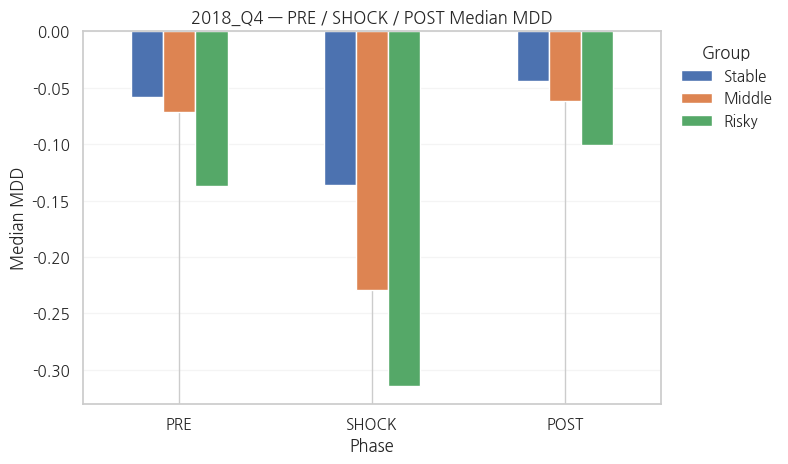

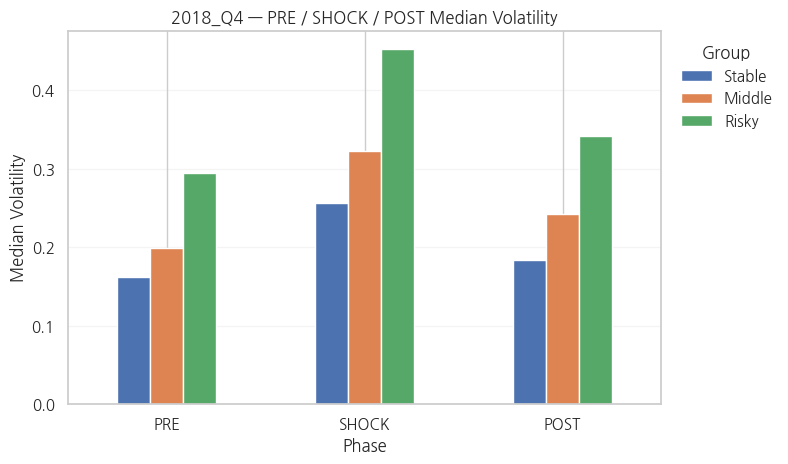

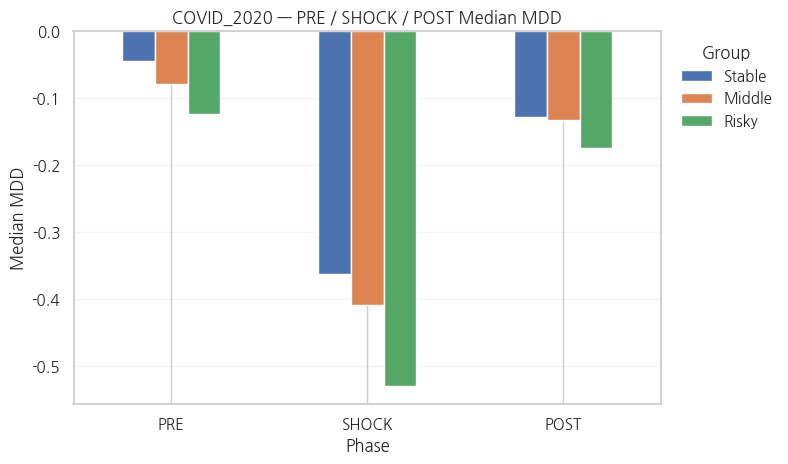

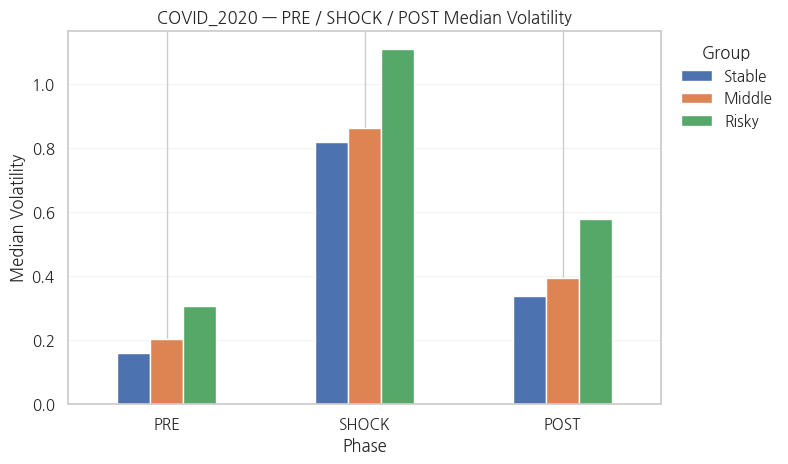

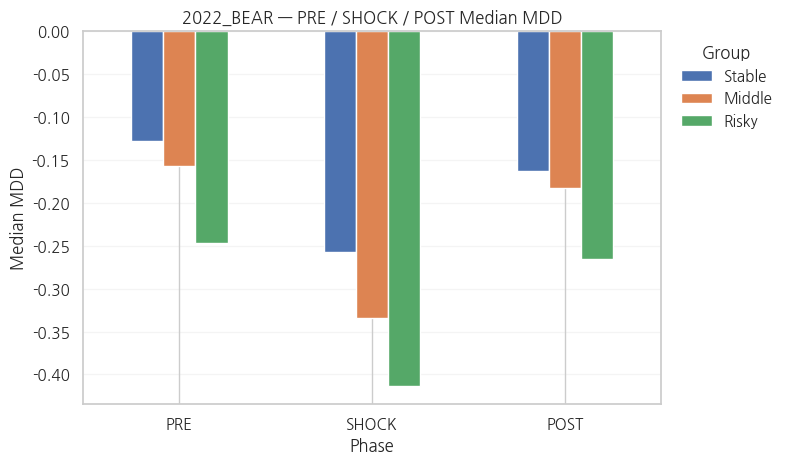

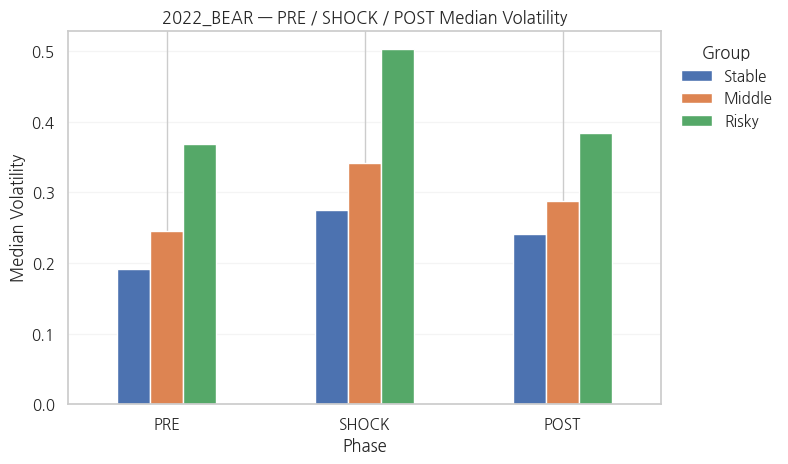

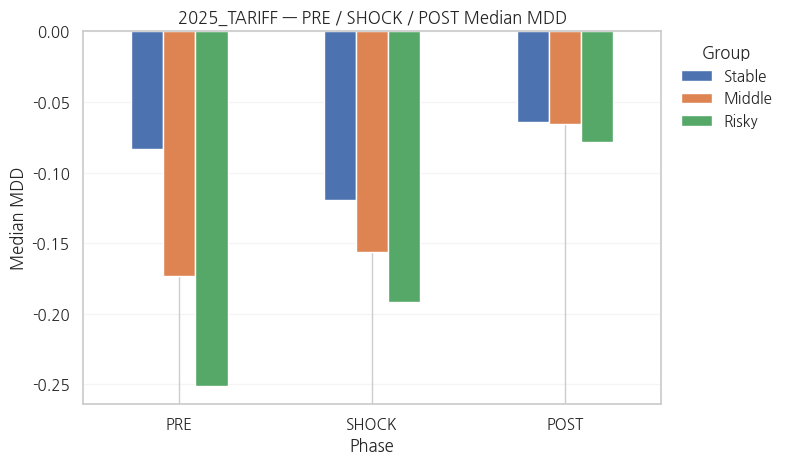

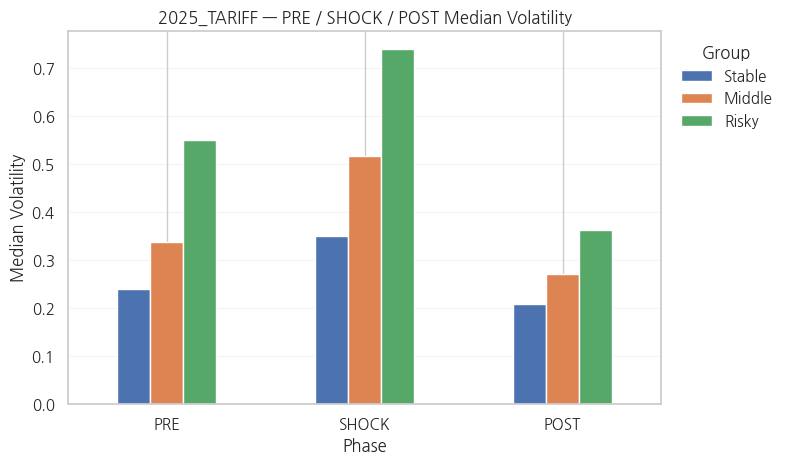

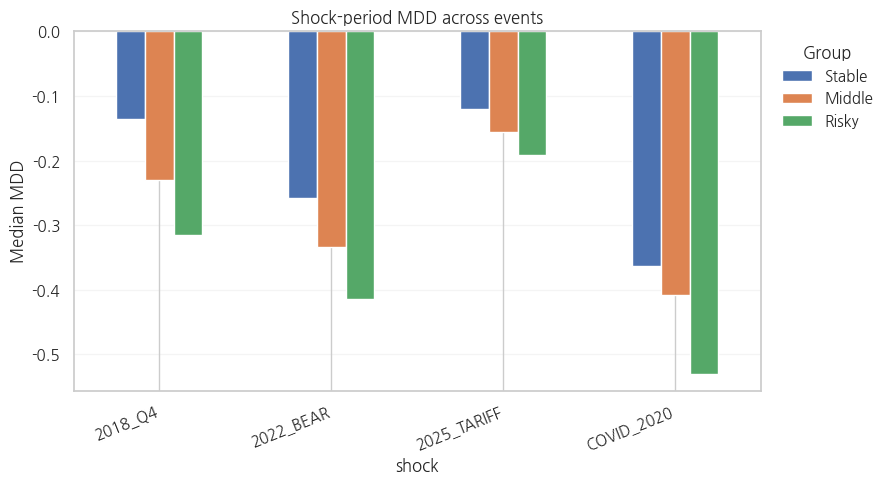

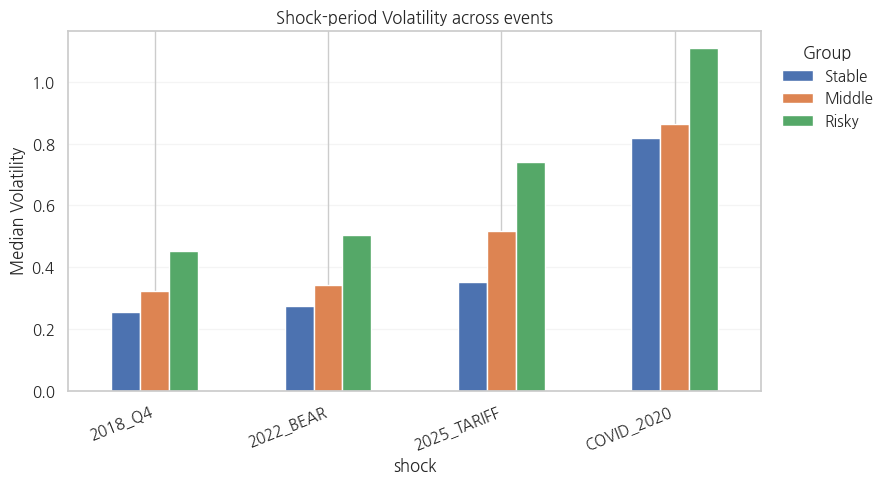

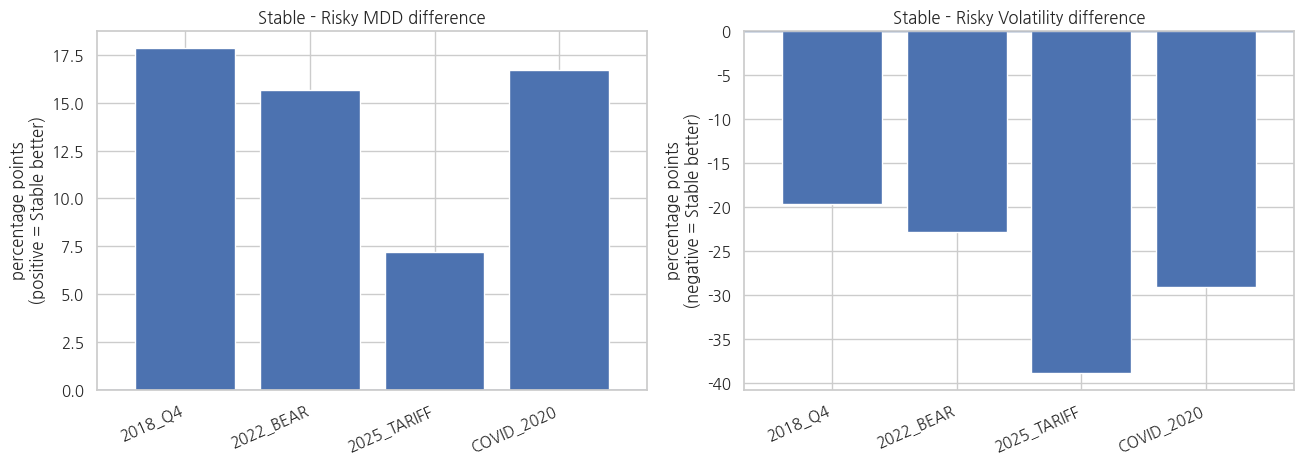

In [30]:
if len(shock_summary):
    phase_order = ["PRE","SHOCK","POST"]
    group_order = ["Stable","Middle","Risky"]

    for shock in shock_summary["shock"].unique():
        temp = shock_summary[shock_summary["shock"].eq(shock)]

        for value, title, ylabel in [
            ("median_mdd", f"{shock} — PRE / SHOCK / POST Median MDD", "Median MDD"),
            ("median_vol", f"{shock} — PRE / SHOCK / POST Median Volatility", "Median Volatility"),
        ]:
            pivot = (
                temp.pivot(index="phase", columns="stability_group", values=value)
                .reindex(phase_order)
            )
            pivot = pivot.reindex(columns=[g for g in group_order if g in pivot.columns])

            ax = pivot.plot(kind="bar", figsize=(9.6,4.8))
            ax.set_title(title)
            ax.set_xlabel("Phase")
            ax.set_ylabel(ylabel)
            plt.xticks(rotation=0)
            ax.legend(title="Group", loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
            plt.grid(axis="y", alpha=.2)
            plt.tight_layout(rect=(0, 0, 0.84, 1))
            plt.show()

    # 사건별 SHOCK만 한 장에 비교
    shock_only = shock_summary[shock_summary["phase"].eq("SHOCK")].copy()

    for value, title, ylabel in [
        ("median_mdd", "Shock-period MDD across events", "Median MDD"),
        ("median_vol", "Shock-period Volatility across events", "Median Volatility"),
    ]:
        pivot = shock_only.pivot(
            index="shock",
            columns="stability_group",
            values=value
        )
        pivot = pivot.reindex(columns=[g for g in group_order if g in pivot.columns])

        ax = pivot.plot(kind="bar", figsize=(10.8,5.0))
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.legend(title="Group", loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
        plt.xticks(rotation=22, ha="right")
        plt.grid(axis="y", alpha=.2)
        plt.tight_layout(rect=(0, 0, 0.84, 1))
        plt.show()

    # Stable - Risky 차이: MDD는 양수일수록 Stable이 덜 하락,
    # Vol은 음수일수록 Stable이 덜 흔들림.
    if len(shock_event_check):
        fig, axes = plt.subplots(1, 2, figsize=(13.2,4.8))

        axes[0].bar(
            shock_event_check["shock"],
            shock_event_check["Stable_minus_Risky_MDD"] * 100
        )
        axes[0].axhline(0, linewidth=1)
        axes[0].set_title("Stable - Risky MDD difference")
        axes[0].set_ylabel("percentage points\n(positive = Stable better)")

        axes[1].bar(
            shock_event_check["shock"],
            shock_event_check["Stable_minus_Risky_Vol"] * 100
        )
        axes[1].axhline(0, linewidth=1)
        axes[1].set_title("Stable - Risky Volatility difference")
        axes[1].set_ylabel("percentage points\n(negative = Stable better)")

        for ax in axes:
            for label in ax.get_xticklabels():
                label.set_rotation(24)
                label.set_ha("right")
            ax.margins(x=0.08)

        plt.tight_layout()
        plt.show()


## [추가 위기검증 해석] 상대방어력과 군집 유지율을 분리해서 설명

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.



### [추가] 위험시기 군집 유지율 / 이동률

각 이벤트마다 **위기 직전 마지막 120d 평가일**과 **위기 중 마지막 120d 평가일**을 비교합니다. 위기구간 안에 평가일이 없으면 **위기 종료 뒤 첫 평가일**을 사용하고 `comparison_phase`에 이를 표시합니다.

- `retention_rate_pct`: 같은 군집에 남은 비율
- `row_pct`: 원래 군집에서 Stable/Middle/Risky로 각각 이동한 비율
- 비교는 두 평가일 모두 존재하는 동일 Ticker만 사용합니다.


[위기별 비교 평가일]


,shock,anchor_date,comparison_date,comparison_phase,comparable_tickers
0,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,478
1,COVID_2020,2019-10-25,2020-04-20,DURING_SHOCK,481
2,2022_BEAR,2021-09-22,2022-09-06,DURING_SHOCK,486
3,2025_TARIFF,2025-01-28,2025-07-22,FIRST_POST_SHOCK_EVAL,494



[군집별 유지율]


from_group,Stable,Middle,Risky
shock,,,
2018_Q4,73.9700,71.0600,64.4100
2022_BEAR,75.1300,62.5600,44.4400
2025_TARIFF,75.1800,71.2000,87.5000
COVID_2020,50.3400,51.9300,51.5200



[군집 이동 상세: 행 기준 %]


,shock,anchor_date,comparison_date,comparison_phase,from_group,to_group,count,row_pct
0,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Stable,Stable,108,73.9726
1,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Stable,Middle,36,24.6575
2,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Stable,Risky,2,1.3699
3,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Middle,Stable,47,17.2161
4,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Middle,Middle,194,71.0623
5,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Middle,Risky,32,11.7216
6,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Risky,Stable,4,6.7797
7,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Risky,Middle,17,28.8136
8,2018_Q4,2018-05-22,2018-11-09,DURING_SHOCK,Risky,Risky,38,64.4068
9,COVID_2020,2019-10-25,2020-04-20,DURING_SHOCK,Stable,Stable,75,50.3356


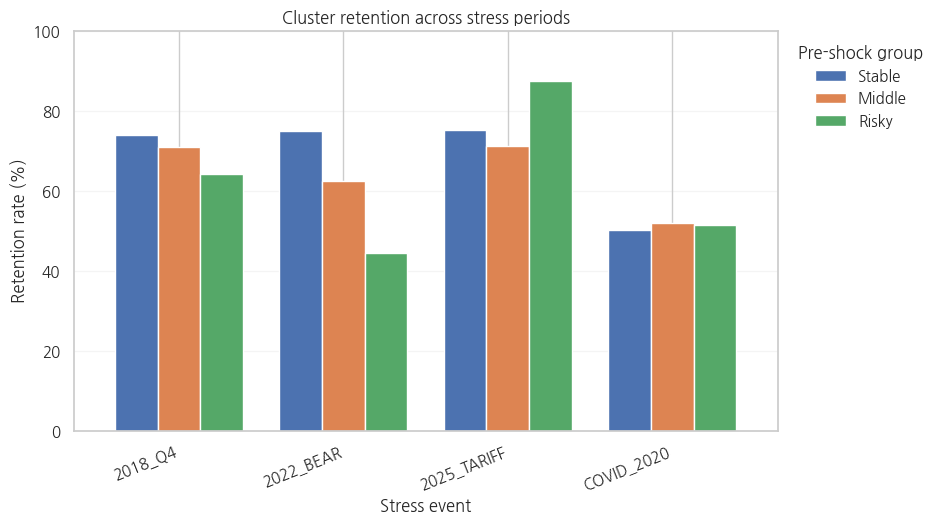

In [31]:

# ============================================================
# [추가] 위험시기 군집 유지율 / 이동률 — 기존 Shock 검증 뒤에만 보강
# ============================================================
_transition_rows = []
_retention_rows = []
_transition_date_rows = []
_group_order = ["Stable", "Middle", "Risky"]
_decision_dates = pd.Index(sorted(pd.to_datetime(market_clustered["Date"].dropna().unique())))

for shock_name, (start, end) in SHOCKS.items():
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    pre_dates = _decision_dates[_decision_dates < start]
    if len(pre_dates) == 0:
        continue
    anchor_date = pre_dates.max()

    during_dates = _decision_dates[(_decision_dates >= start) & (_decision_dates <= end)]
    if len(during_dates):
        comparison_date = during_dates.max()
        comparison_phase = "DURING_SHOCK"
    else:
        post_dates = _decision_dates[_decision_dates > end]
        if len(post_dates) == 0:
            continue
        comparison_date = post_dates.min()
        comparison_phase = "FIRST_POST_SHOCK_EVAL"

    before = market_clustered.loc[
        market_clustered["Date"].eq(anchor_date),
        ["Ticker", "stability_group"]
    ].drop_duplicates("Ticker").rename(columns={"stability_group": "from_group"})

    after = market_clustered.loc[
        market_clustered["Date"].eq(comparison_date),
        ["Ticker", "stability_group"]
    ].drop_duplicates("Ticker").rename(columns={"stability_group": "to_group"})

    paired = before.merge(after, on="Ticker", how="inner", validate="one_to_one")
    paired = paired[
        paired["from_group"].isin(_group_order) & paired["to_group"].isin(_group_order)
    ].copy()

    _transition_date_rows.append({
        "shock": shock_name,
        "anchor_date": anchor_date,
        "comparison_date": comparison_date,
        "comparison_phase": comparison_phase,
        "comparable_tickers": len(paired),
    })

    if paired.empty:
        continue

    counts = pd.crosstab(paired["from_group"], paired["to_group"])
    counts = counts.reindex(index=_group_order, columns=_group_order, fill_value=0)
    row_totals = counts.sum(axis=1).replace(0, np.nan)
    row_pct = counts.div(row_totals, axis=0) * 100

    for from_group in _group_order:
        total_n = int(counts.loc[from_group].sum())
        stayed_n = int(counts.loc[from_group, from_group])
        retention = (stayed_n / total_n * 100) if total_n else np.nan
        _retention_rows.append({
            "shock": shock_name,
            "anchor_date": anchor_date,
            "comparison_date": comparison_date,
            "comparison_phase": comparison_phase,
            "from_group": from_group,
            "comparable_n": total_n,
            "stayed_n": stayed_n,
            "retention_rate_pct": retention,
        })

        for to_group in _group_order:
            _transition_rows.append({
                "shock": shock_name,
                "anchor_date": anchor_date,
                "comparison_date": comparison_date,
                "comparison_phase": comparison_phase,
                "from_group": from_group,
                "to_group": to_group,
                "count": int(counts.loc[from_group, to_group]),
                "row_pct": float(row_pct.loc[from_group, to_group]) if pd.notna(row_pct.loc[from_group, to_group]) else np.nan,
            })

shock_transition_dates = pd.DataFrame(_transition_date_rows)
shock_retention_summary = pd.DataFrame(_retention_rows)
shock_transition_detail = pd.DataFrame(_transition_rows)

print("[위기별 비교 평가일]")
display(shock_transition_dates)

print("\n[군집별 유지율]")
if len(shock_retention_summary):
    retention_table = (
        shock_retention_summary.pivot(
            index="shock", columns="from_group", values="retention_rate_pct"
        )
        .reindex(columns=_group_order)
        .round(2)
    )
    display(retention_table)
else:
    retention_table = pd.DataFrame()
    print("비교 가능한 군집 유지율이 없습니다.")

print("\n[군집 이동 상세: 행 기준 %]")
display(shock_transition_detail)

# ------------------------------------------------------------
# 시각화 1: 이벤트별 Stable/Middle/Risky 유지율 비교
# 라벨 숫자를 막대 위에 모두 붙이지 않아 글자 겹침을 피함
# ------------------------------------------------------------
if len(shock_retention_summary):
    retention_plot = (
        shock_retention_summary.pivot(
            index="shock", columns="from_group", values="retention_rate_pct"
        )
        .reindex(columns=_group_order)
    )

    ax = retention_plot.plot(kind="bar", figsize=(11.4, 5.4), width=0.78)
    ax.set_title("Cluster retention across stress periods")
    ax.set_xlabel("Stress event")
    ax.set_ylabel("Retention rate (%)")
    ax.set_ylim(0, 100)
    ax.legend(title="Pre-shock group", loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
    plt.xticks(rotation=22, ha="right")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout(rect=(0, 0, 0.84, 1))
    plt.show()


[31]
# [추가] 위험시기 군집 유지율 / 이동률
...
shock_transition_dates
shock_retention_summary
shock_transition_detail
...
Cluster retention across stress periods 그래프

[평상시 대비 위기구간 군집 유지성 - 전체 군집]


,shock,comparison_phase,step_gap,from_group,normal_pair_n,normal_retention_mean,retention_rate_pct,retention_delta_pp,normal_to_risky_mean,to_Risky_pct,to_risky_delta_pp,retention_vs_normal,direct_risky_vs_normal
0,2018_Q4,DURING_SHOCK,1,Stable,12,79.7000,73.9700,-5.7300,1.3600,1.3700,0.0100,BELOW_NORMAL,MORE_THAN_NORMAL
1,2018_Q4,DURING_SHOCK,1,Middle,12,66.1600,71.0600,4.9000,9.8500,11.7200,1.8700,ABOVE_OR_EQUAL_NORMAL,MORE_THAN_NORMAL
2,2018_Q4,DURING_SHOCK,1,Risky,12,59.9400,64.4100,4.4700,59.9400,64.4100,4.4700,ABOVE_OR_EQUAL_NORMAL,MORE_THAN_NORMAL
3,COVID_2020,DURING_SHOCK,1,Stable,12,79.7000,50.3400,-29.3700,1.3600,7.3800,6.0200,BELOW_NORMAL,MORE_THAN_NORMAL
4,COVID_2020,DURING_SHOCK,1,Middle,12,66.1600,51.9300,-14.2300,9.8500,13.7300,3.8900,BELOW_NORMAL,MORE_THAN_NORMAL
5,COVID_2020,DURING_SHOCK,1,Risky,12,59.9400,51.5200,-8.4200,59.9400,51.5200,-8.4200,BELOW_NORMAL,NO_MORE_THAN_NORMAL
6,2022_BEAR,DURING_SHOCK,2,Stable,7,76.7800,75.1300,-1.6500,2.2500,3.6300,1.3700,BELOW_NORMAL,MORE_THAN_NORMAL
7,2022_BEAR,DURING_SHOCK,2,Middle,7,60.7700,62.5600,1.7900,10.9800,5.9100,-5.0700,ABOVE_OR_EQUAL_NORMAL,NO_MORE_THAN_NORMAL
8,2022_BEAR,DURING_SHOCK,2,Risky,7,47.6500,44.4400,-3.2000,47.6500,44.4400,-3.2000,BELOW_NORMAL,NO_MORE_THAN_NORMAL
9,2025_TARIFF,FIRST_POST_SHOCK_EVAL,1,Stable,12,79.7000,75.1800,-4.5200,1.3600,1.4400,0.0800,BELOW_NORMAL,MORE_THAN_NORMAL



[발표 핵심표 - Stable 군집]


,shock,comparison_phase,step_gap,normal_pair_n,Normal Stable→Stable (%),Shock Stable→Stable (%),Retention Δ (pp),Normal Stable→Risky (%),Shock Stable→Risky (%),Risky-transition Δ (pp)
0,2018_Q4,DURING_SHOCK,1,12,79.7000,73.9700,-5.7300,1.3600,1.3700,0.0100
6,2022_BEAR,DURING_SHOCK,2,7,76.7800,75.1300,-1.6500,2.2500,3.6300,1.3700
9,2025_TARIFF,FIRST_POST_SHOCK_EVAL,1,12,79.7000,75.1800,-4.5200,1.3600,1.4400,0.0800
3,COVID_2020,DURING_SHOCK,1,12,79.7000,50.3400,-29.3700,1.3600,7.3800,6.0200



[읽는 법]
- Retention Δ > 0 : 위기 때 Stable 유지율이 평상시보다 높음
- Retention Δ < 0 : 위기 때 Stable 유지율이 평상시보다 낮음
- Risky-transition Δ < 0 : 위기 때 Stable→Risky 직접 전환이 평상시보다 적음


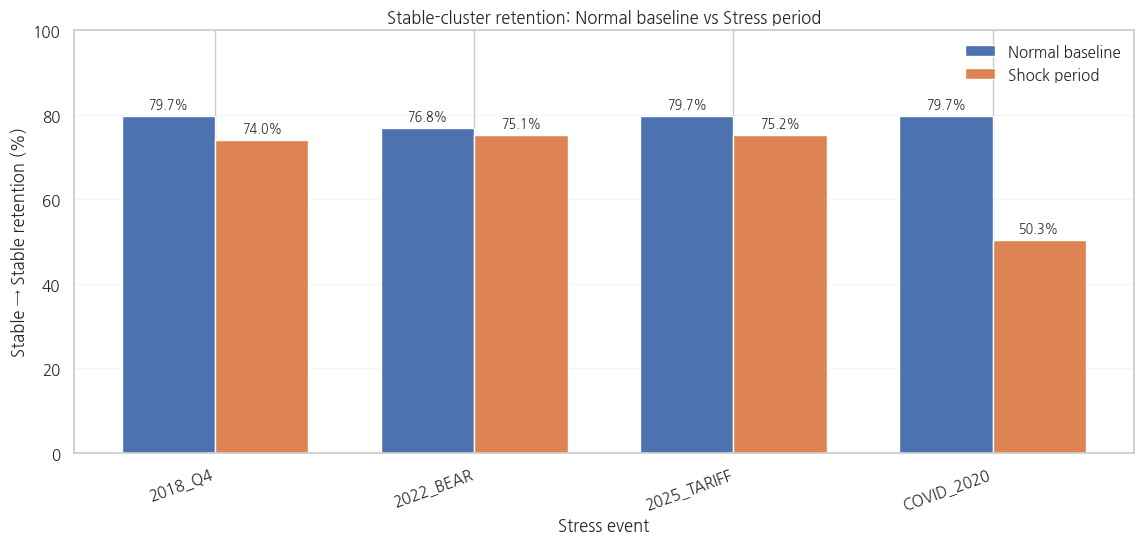

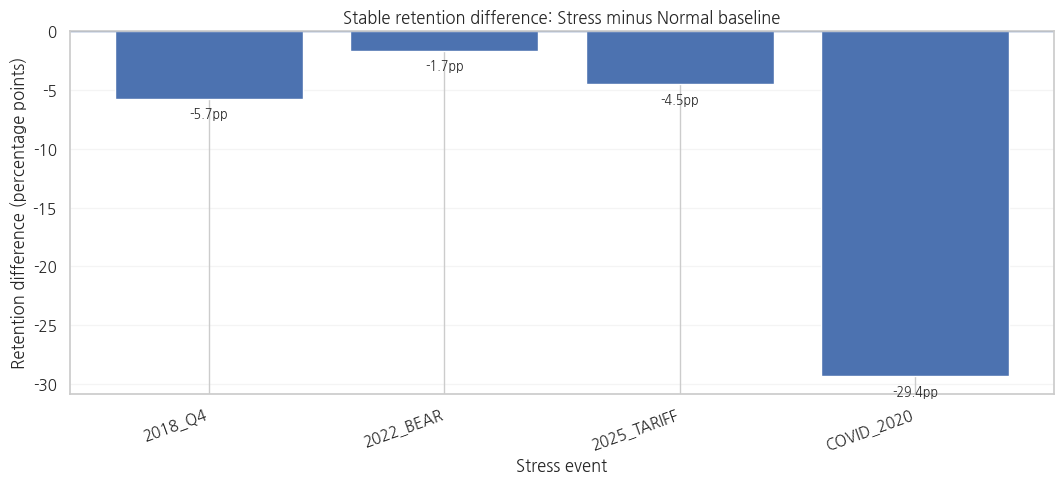

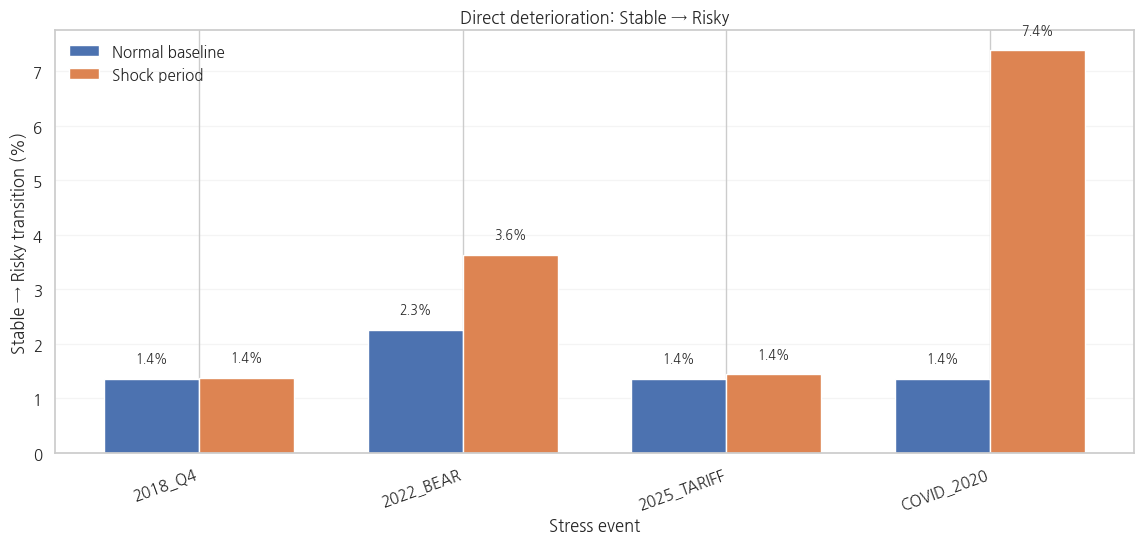

In [62]:
# ============================================================
# [추가 검증] 평상시 대비 위기구간 군집 유지성
# 위치: 기존 Cell 67 바로 뒤 / PART 9 시작 전
#
# 핵심 질문:
# "Stable 군집은 위기 때도 평상시 수준으로 유지되는가?"
#
# 주의:
# - 군집 생성 지표는 그대로 Volatility 120d + |Beta| 120d
# - MDD는 사용하지 않음
# - 기존 market_clustered의 Stable/Middle/Risky 라벨만 이용
# ============================================================

_group_order = ["Stable", "Middle", "Risky"]

_decision_dates = pd.Index(
    sorted(
        pd.to_datetime(
            market_clustered["Date"].dropna().unique()
        )
    )
)


# ============================================================
# 1. 두 평가일 사이 군집 이동 계산
# ============================================================

def calc_cluster_transition(date_from, date_to):

    before = (
        market_clustered.loc[
            market_clustered["Date"].eq(pd.Timestamp(date_from)),
            ["Ticker", "stability_group"]
        ]
        .drop_duplicates("Ticker")
        .rename(columns={
            "stability_group": "from_group"
        })
    )

    after = (
        market_clustered.loc[
            market_clustered["Date"].eq(pd.Timestamp(date_to)),
            ["Ticker", "stability_group"]
        ]
        .drop_duplicates("Ticker")
        .rename(columns={
            "stability_group": "to_group"
        })
    )

    paired = before.merge(
        after,
        on="Ticker",
        how="inner",
        validate="one_to_one"
    )

    paired = paired[
        paired["from_group"].isin(_group_order)
        &
        paired["to_group"].isin(_group_order)
    ].copy()

    if paired.empty:
        return pd.DataFrame()

    counts = pd.crosstab(
        paired["from_group"],
        paired["to_group"]
    )

    counts = counts.reindex(
        index=_group_order,
        columns=_group_order,
        fill_value=0
    )

    rows = []

    for from_group in _group_order:

        total_n = int(
            counts.loc[from_group].sum()
        )

        if total_n == 0:
            continue

        rows.append({

            "from_group": from_group,

            "comparable_n": total_n,

            # 같은 군집에 남은 비율
            "retention_rate_pct":
                counts.loc[from_group, from_group]
                / total_n * 100,

            # 이동 상세
            "to_Stable_pct":
                counts.loc[from_group, "Stable"]
                / total_n * 100,

            "to_Middle_pct":
                counts.loc[from_group, "Middle"]
                / total_n * 100,

            "to_Risky_pct":
                counts.loc[from_group, "Risky"]
                / total_n * 100,
        })

    return pd.DataFrame(rows)


# ============================================================
# 2. 평상시 baseline에서
#    우리가 지정한 4개 위기구간 제외
# ============================================================

def overlaps_known_shock(date_from, date_to):

    left = pd.Timestamp(date_from)
    right = pd.Timestamp(date_to)

    for shock_name, (start, end) in SHOCKS.items():

        start = pd.Timestamp(start)
        end = pd.Timestamp(end)

        # 비교기간 중 위기구간이 하나라도 겹치면
        # 평상시 baseline에서 제외
        if left <= end and right >= start:
            return True

    return False


# ============================================================
# 3. 위기와 동일한 평가일 간격(step gap)의
#    평상시 구간을 찾아 baseline 생성
# ============================================================

_compare_rows = []
_normal_detail_rows = []


for _, shock_info in shock_transition_dates.iterrows():

    shock_name = shock_info["shock"]

    anchor_date = pd.Timestamp(
        shock_info["anchor_date"]
    )

    comparison_date = pd.Timestamp(
        shock_info["comparison_date"]
    )

    comparison_phase = (
        shock_info["comparison_phase"]
    )


    # --------------------------------------------------------
    # 위기 비교가 평가일 몇 칸 차이인지 계산
    # --------------------------------------------------------

    anchor_pos = _decision_dates.get_indexer(
        [anchor_date]
    )[0]

    comparison_pos = _decision_dates.get_indexer(
        [comparison_date]
    )[0]


    if anchor_pos < 0 or comparison_pos < 0:

        print(
            f"[SKIP] {shock_name}: "
            "평가일을 찾지 못했습니다."
        )

        continue


    step_gap = comparison_pos - anchor_pos


    if step_gap <= 0:
        continue


    # --------------------------------------------------------
    # 실제 위기구간 유지율
    # --------------------------------------------------------

    shock_stats = calc_cluster_transition(
        anchor_date,
        comparison_date
    )

    if shock_stats.empty:
        continue


    # --------------------------------------------------------
    # 동일한 step gap을 가진 평상시 비교구간 수집
    # --------------------------------------------------------

    normal_parts = []


    for i in range(
        len(_decision_dates) - step_gap
    ):

        d0 = _decision_dates[i]
        d1 = _decision_dates[i + step_gap]


        # 지정한 위기와 겹치는 기간 제거
        if overlaps_known_shock(d0, d1):
            continue


        temp = calc_cluster_transition(
            d0,
            d1
        )


        if temp.empty:
            continue


        temp["normal_from_date"] = d0
        temp["normal_to_date"] = d1

        temp["shock_reference"] = (
            shock_name
        )

        temp["step_gap"] = step_gap


        normal_parts.append(temp)

        _normal_detail_rows.extend(
            temp.to_dict("records")
        )


    if len(normal_parts) == 0:

        print(
            f"[WARN] {shock_name}: "
            f"step_gap={step_gap} "
            "평상시 비교구간 없음"
        )

        continue


    normal_stats = pd.concat(
        normal_parts,
        ignore_index=True
    )


    # --------------------------------------------------------
    # 평상시 baseline
    # --------------------------------------------------------

    normal_summary = (
        normal_stats
        .groupby("from_group")
        .agg(

            normal_pair_n=(
                "retention_rate_pct",
                "size"
            ),

            normal_retention_mean=(
                "retention_rate_pct",
                "mean"
            ),

            normal_retention_median=(
                "retention_rate_pct",
                "median"
            ),

            normal_retention_std=(
                "retention_rate_pct",
                "std"
            ),

            normal_to_risky_mean=(
                "to_Risky_pct",
                "mean"
            ),

            normal_to_risky_median=(
                "to_Risky_pct",
                "median"
            ),
        )
        .reset_index()
    )


    comp = shock_stats.merge(
        normal_summary,
        on="from_group",
        how="left"
    )


    comp["shock"] = shock_name

    comp["anchor_date"] = anchor_date

    comp["comparison_date"] = (
        comparison_date
    )

    comp["comparison_phase"] = (
        comparison_phase
    )

    comp["step_gap"] = step_gap


    # --------------------------------------------------------
    # 위기 - 평상시 차이
    # --------------------------------------------------------

    comp["retention_delta_pp"] = (
        comp["retention_rate_pct"]
        -
        comp["normal_retention_mean"]
    )


    comp["to_risky_delta_pp"] = (
        comp["to_Risky_pct"]
        -
        comp["normal_to_risky_mean"]
    )


    # 단순 판독용
    comp["retention_vs_normal"] = np.where(

        comp["retention_delta_pp"] >= 0,

        "ABOVE_OR_EQUAL_NORMAL",

        "BELOW_NORMAL"
    )


    comp["direct_risky_vs_normal"] = np.where(

        comp["to_risky_delta_pp"] <= 0,

        "NO_MORE_THAN_NORMAL",

        "MORE_THAN_NORMAL"
    )


    _compare_rows.append(comp)



# ============================================================
# 4. 결과 데이터프레임 생성
# ============================================================

normal_transition_detail = pd.DataFrame(
    _normal_detail_rows
)


crisis_vs_normal_by_group = (

    pd.concat(
        _compare_rows,
        ignore_index=True
    )

    if _compare_rows

    else pd.DataFrame()
)



# ============================================================
# 5. 전체 군집 결과
# ============================================================

print(
    "[평상시 대비 위기구간 군집 유지성 - 전체 군집]"
)


if len(crisis_vs_normal_by_group):

    display(

        crisis_vs_normal_by_group[[

            "shock",
            "comparison_phase",
            "step_gap",

            "from_group",

            "normal_pair_n",

            "normal_retention_mean",
            "retention_rate_pct",
            "retention_delta_pp",

            "normal_to_risky_mean",
            "to_Risky_pct",
            "to_risky_delta_pp",

            "retention_vs_normal",
            "direct_risky_vs_normal",

        ]].round(2)

    )



# ============================================================
# 6. 발표에서 가장 중요한 Stable만 추출
# ============================================================

stable_crisis_vs_normal = (

    crisis_vs_normal_by_group[

        crisis_vs_normal_by_group[
            "from_group"
        ].eq("Stable")

    ]

    .copy()

    .sort_values("shock")

)


print(
    "\n[발표 핵심표 - Stable 군집]"
)


if len(stable_crisis_vs_normal):

    stable_presentation_table = (

        stable_crisis_vs_normal[[

            "shock",
            "comparison_phase",

            "step_gap",
            "normal_pair_n",

            "normal_retention_mean",
            "retention_rate_pct",
            "retention_delta_pp",

            "normal_to_risky_mean",
            "to_Risky_pct",
            "to_risky_delta_pp",

        ]]

        .copy()
    )


    stable_presentation_table = (
        stable_presentation_table.rename(
            columns={

                "normal_retention_mean":
                    "Normal Stable→Stable (%)",

                "retention_rate_pct":
                    "Shock Stable→Stable (%)",

                "retention_delta_pp":
                    "Retention Δ (pp)",

                "normal_to_risky_mean":
                    "Normal Stable→Risky (%)",

                "to_Risky_pct":
                    "Shock Stable→Risky (%)",

                "to_risky_delta_pp":
                    "Risky-transition Δ (pp)",
            }
        )
    )


    display(
        stable_presentation_table.round(2)
    )


    print("\n[읽는 법]")

    print(
        "- Retention Δ > 0 : "
        "위기 때 Stable 유지율이 평상시보다 높음"
    )

    print(
        "- Retention Δ < 0 : "
        "위기 때 Stable 유지율이 평상시보다 낮음"
    )

    print(
        "- Risky-transition Δ < 0 : "
        "위기 때 Stable→Risky 직접 전환이 "
        "평상시보다 적음"
    )



# ============================================================
# 7. 시각화 1
#    평상시 Stable 유지율 vs 위기 Stable 유지율
# ============================================================

if len(stable_crisis_vs_normal):

    plot_df = (
        stable_crisis_vs_normal
        .reset_index(drop=True)
    )

    x = np.arange(len(plot_df))

    width = 0.36


    fig, ax = plt.subplots(
        figsize=(11.6, 5.6)
    )


    normal_bars = ax.bar(

        x - width / 2,

        plot_df[
            "normal_retention_mean"
        ],

        width,

        label="Normal baseline"
    )


    shock_bars = ax.bar(

        x + width / 2,

        plot_df[
            "retention_rate_pct"
        ],

        width,

        label="Shock period"
    )


    ax.set_title(
        "Stable-cluster retention: "
        "Normal baseline vs Stress period"
    )

    ax.set_xlabel(
        "Stress event"
    )

    ax.set_ylabel(
        "Stable → Stable retention (%)"
    )

    ax.set_ylim(
        0,
        100
    )

    ax.set_xticks(x)

    ax.set_xticklabels(

        plot_df["shock"],

        rotation=20,

        ha="right"
    )

    ax.legend(
        frameon=False
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )


    # 막대 위 숫자
    for bars in [
        normal_bars,
        shock_bars
    ]:

        for bar in bars:

            h = bar.get_height()

            if pd.notna(h):

                ax.text(

                    bar.get_x()
                    + bar.get_width() / 2,

                    h + 1.2,

                    f"{h:.1f}%",

                    ha="center",

                    va="bottom",

                    fontsize=9
                )


    plt.tight_layout()

    plt.show()



# ============================================================
# 8. 시각화 2
#    위기 유지율 - 평상시 유지율
#
#    + : 위기에서도 평상시보다 잘 유지
#    - : 평상시보다 유지율 하락
# ============================================================

if len(stable_crisis_vs_normal):

    plot_df = (
        stable_crisis_vs_normal
        .reset_index(drop=True)
    )


    plt.figure(
        figsize=(10.8, 5.0)
    )


    bars = plt.bar(

        plot_df["shock"],

        plot_df["retention_delta_pp"]
    )


    plt.axhline(
        0,
        linewidth=1
    )


    plt.title(
        "Stable retention difference: "
        "Stress minus Normal baseline"
    )


    plt.xlabel(
        "Stress event"
    )


    plt.ylabel(
        "Retention difference "
        "(percentage points)"
    )


    plt.xticks(
        rotation=20,
        ha="right"
    )


    plt.grid(
        axis="y",
        alpha=0.2
    )


    for bar, value in zip(

        bars,

        plot_df["retention_delta_pp"]
    ):

        if pd.notna(value):

            if value >= 0:

                va = "bottom"
                offset = 0.8

            else:

                va = "top"
                offset = -0.8


            plt.text(

                bar.get_x()
                + bar.get_width() / 2,

                value + offset,

                f"{value:+.1f}pp",

                ha="center",

                va=va,

                fontsize=9
            )


    plt.tight_layout()

    plt.show()



# ============================================================
# 9. 시각화 3
#    Stable → Risky 직접 추락률
#
#    낮을수록 좋음
# ============================================================

if len(stable_crisis_vs_normal):

    plot_df = (
        stable_crisis_vs_normal
        .reset_index(drop=True)
    )

    x = np.arange(
        len(plot_df)
    )

    width = 0.36


    fig, ax = plt.subplots(
        figsize=(11.6, 5.6)
    )


    normal_bars = ax.bar(

        x - width / 2,

        plot_df[
            "normal_to_risky_mean"
        ],

        width,

        label="Normal baseline"
    )


    shock_bars = ax.bar(

        x + width / 2,

        plot_df[
            "to_Risky_pct"
        ],

        width,

        label="Shock period"
    )


    ax.set_title(
        "Direct deterioration: "
        "Stable → Risky"
    )


    ax.set_xlabel(
        "Stress event"
    )


    ax.set_ylabel(
        "Stable → Risky transition (%)"
    )


    ax.set_xticks(x)


    ax.set_xticklabels(

        plot_df["shock"],

        rotation=20,

        ha="right"
    )


    ax.legend(
        frameon=False
    )


    ax.grid(
        axis="y",
        alpha=0.2
    )


    for bars in [
        normal_bars,
        shock_bars
    ]:

        for bar in bars:

            h = bar.get_height()

            if pd.notna(h):

                ax.text(

                    bar.get_x()
                    + bar.get_width() / 2,

                    h + 0.25,

                    f"{h:.1f}%",

                    ha="center",

                    va="bottom",

                    fontsize=9
                )


    plt.tight_layout()

    plt.show()

# PART 9. Industry 보강 — v17 기존 검증


# H4. 산업 내 상대안정성 보강은 False-Stable을 줄이는가?
**원본 v13: 셀 63~70 + 104~106**

- 가설: Market Stable 중 같은 Sector에서도 Stable인 종목을 남기면 False-Stable이 감소할 것이다.
- 검증: Market Stable vs Balanced Verified/Eligible, 미매핑/분류불가 영향 분리
- 추가 검증: Date-block bootstrap
- 판단: **개선 방향은 관측됨**
- 단, Industry K-Means만의 순수 인과효과로 단정하지 않음.
- 수익성과 공통축: Sector/업종 집중 및 안정군 후보 정의.


##산업별 안정성 보강

`sp500_universe.csv`의 Sector를 사용합니다.

### 역할
- Market Stable: 시장 전체에서 안정적
- Industry Stable: 같은 산업 안에서도 상대적으로 안정적
- Balanced Stable: 둘 다 만족

### 중요한 처리
Sector가 없는 종목은 내부적으로 미매핑 상태로 보존합니다.  
**산업정보가 없다는 이유만으로 위험하다고 처리하지 않습니다.**


In [32]:
u = sp500_universe.copy()
u.columns = [str(c).strip().lower() for c in u.columns]

ticker_col = next((c for c in ["ticker","symbol"] if c in u.columns), None)
sector_col = next((c for c in ["sector","gics sector"] if c in u.columns), None)

if ticker_col is None or sector_col is None:
    raise ValueError(f"sp500_universe 컬럼 확인 필요: {u.columns.tolist()}")

sector_map = u[[ticker_col, sector_col]].copy()
sector_map.columns = ["Ticker","Sector"]
sector_map["Ticker"] = normalize_ticker(sector_map["Ticker"])
sector_map["Sector"] = sector_map["Sector"].astype(str).str.strip()

# [FIX] Unknown 계열 Sector는 실제 산업군으로 사용하지 않음
sector_map.loc[
    sector_map["Sector"].str.upper().isin(["UNKNOWN", "NAN", "NONE", ""]),
    "Sector"
] = np.nan

sector_map = sector_map.drop_duplicates("Ticker", keep="first")

sector_panel = market_clustered.merge(sector_map, on="Ticker", how="left")
sector_panel["Sector"] = sector_panel["Sector"].replace({"nan":np.nan, "None":np.nan, "":np.nan})
sector_panel["industry_status"] = "UNKNOWN"

print("Sector mapping rate:", sector_panel["Sector"].notna().mean())

industry_out = []
industry_quality = []

for (dt, sector), g in sector_panel.dropna(subset=["Sector"]).groupby(["Date","Sector"]):
    if len(g) < 12:
        continue
    fitted, Xs, km = fit_kmeans_snapshot(g, 120, 3)
    if fitted is None:
        continue
    fitted["industry_status"] = fitted["risk_rank"].map({1:"STABLE",2:"MIDDLE",3:"RISKY"})
    fitted["Sector"] = sector
    industry_out.append(fitted[["Date","Ticker","industry_status","Sector"]])
    industry_quality.append({
        "Date":dt, "Sector":sector, "n":len(g),
        "silhouette":silhouette_score(Xs, km.labels_)
    })

industry_labels = pd.concat(industry_out, ignore_index=True) if industry_out else pd.DataFrame(
    columns=["Date","Ticker","industry_status","Sector"]
)
industry_quality_df = pd.DataFrame(industry_quality)

sector_panel = sector_panel.drop(columns=["industry_status"]).merge(
    industry_labels[["Date","Ticker","industry_status"]],
    on=["Date","Ticker"], how="left"
)
sector_panel["industry_status"] = sector_panel["industry_status"].fillna("UNKNOWN")
sector_panel["balanced_stable"] = (
    sector_panel["market_stable"] & sector_panel["industry_status"].eq("STABLE")
)

# industry_unknown: Sector 매핑 또는 산업 K-Means 결과가 없어 산업판정을 못한 행
sector_panel["industry_unknown"] = sector_panel["industry_status"].eq("UNKNOWN")

# balanced_verified: 시장과 산업에서 모두 실제 STABLE로 확인된 엄격한 교집합
sector_panel["balanced_verified"] = (
    sector_panel["market_stable"] &
    sector_panel["industry_status"].eq("STABLE")
)

# balanced_eligible: Market Stable이면서 산업 STABLE 또는 산업정보 UNKNOWN인 보존용 후보
# UNKNOWN을 위험하다고 간주해 자동 탈락시키지 않습니다.
sector_panel["balanced_eligible"] = (
    sector_panel["market_stable"] &
    (
        sector_panel["industry_status"].eq("STABLE") |
        sector_panel["industry_unknown"]
    )
)

display(sector_panel["industry_status"].value_counts(dropna=False))
display(industry_quality_df.groupby("Sector")["silhouette"].agg(["mean","median","count"]).sort_values("mean", ascending=False).head(20))

Sector mapping rate: 0.839344262295082


,count
industry_status,
STABLE,3883
MIDDLE,3454
UNKNOWN,1666
RISKY,1367


,mean,median,count
Sector,,,
Utilities,0.5673,0.5488,21
Communication Services,0.4830,0.4909,21
Energy,0.4800,0.4861,21
Information Technology,0.4696,0.4703,21
Real Estate,0.4664,0.4688,21
Consumer Staples,0.4657,0.4687,21
Consumer Discretionary,0.4650,0.4561,21
Materials,0.4575,0.4687,21
Financials,0.4533,0.4424,21


### Sector Mapping 진단과 전처리 협의 인터페이스

**중요:** 아직 전처리 담당자와 보완 데이터의 파일명/경로/형식을 합의하지 않았으므로 **새 파일을 만들거나 요구하지 않습니다.**

현재 소스에서 먼저 확인할 것:
- `SECTOR_MAPPING_MISSING`: 현재 `sp500_universe.csv`에서 Sector 자체를 찾지 못함
- `INDUSTRY_KMEANS_NOT_AVAILABLE`: Sector는 있지만 해당 Date×Sector에서 산업 K-Means 판정을 만들지 못함

`unresolved_sector_tickers`는 화면에만 표시합니다. 전처리 담당자와 협의한 뒤 어떤 형태의 DataFrame이 오든 `sector_enrichment_df` 인터페이스 한 곳에 연결합니다.


In [33]:
# ============================================================
# [추가] Baseline 결과 보존 + UNKNOWN 원인분리
# ============================================================
sector_map_base = sector_map.copy()
sector_panel_baseline = sector_panel.copy()
industry_quality_baseline = industry_quality_df.copy()

sector_panel_baseline["unknown_reason"] = np.select(
    [
        sector_panel_baseline["Sector"].isna(),
        sector_panel_baseline["Sector"].notna() & sector_panel_baseline["industry_status"].eq("UNKNOWN"),
    ],
    [
        "SECTOR_MAPPING_MISSING",
        "INDUSTRY_KMEANS_NOT_AVAILABLE",
    ],
    default="MAPPED_AND_CLASSIFIED"
)

sector_mapping_diagnosis = (
    sector_panel_baseline["unknown_reason"]
    .value_counts(dropna=False)
    .rename_axis("unknown_reason")
    .reset_index(name="rows")
)
unresolved_sector_tickers = (
    sector_panel_baseline.loc[
        sector_panel_baseline["unknown_reason"].eq("SECTOR_MAPPING_MISSING"),
        ["Ticker"]
    ]
    .drop_duplicates()
    .sort_values("Ticker")
    .reset_index(drop=True)
)

print("[Sector mapping diagnosis]")
display(sector_mapping_diagnosis)
print("미매핑 unique tickers:", len(unresolved_sector_tickers))
display(unresolved_sector_tickers)

# ============================================================
# [전처리 협의 인터페이스]
# ============================================================
# 아직 어떤 파일도 가정하지 않습니다.
# 전처리 담당자와 협의 후 Ticker / Sector 컬럼을 가진 DataFrame을
# 아래 변수에 연결하면 됩니다.
#
# 예시(협의 후에만 사용):
# sector_enrichment_df = some_preprocessing_df[["Ticker", "Sector"]].copy()
#
# 현재는 None이 정상입니다.
sector_enrichment_df = None

[Sector mapping diagnosis]


,unknown_reason,rows
0,MAPPED_AND_CLASSIFIED,8704
1,SECTOR_MAPPING_MISSING,1666


미매핑 unique tickers: 172


,Ticker
0,AABA
1,AAL
2,AAP
3,ABMD
4,AET
...,...
167,XL
168,XLNX
169,XRAY
170,XRX


## [H4 Sector mapping 해석] Mapping 성공률과 ‘경제적으로 알려진 Sector’는 구분해야 함

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


In [34]:
# ============================================================
# [H4 추가] Sector 안에 실제 어떤 회사/Ticker가 있는지 확인
# ============================================================
u_view = sp500_universe.copy()
u_view.columns = [str(c).strip().lower() for c in u_view.columns]

ticker_col_view = next((c for c in ["ticker", "symbol"] if c in u_view.columns), None)
sector_col_view = next((c for c in ["sector", "gics sector"] if c in u_view.columns), None)
company_col_view = next((c for c in ["company", "company_name", "security", "name"] if c in u_view.columns), None)

if ticker_col_view is None or sector_col_view is None:
    raise ValueError(f"sp500_universe 컬럼 확인 필요: {u_view.columns.tolist()}")

cols = [ticker_col_view, sector_col_view]
if company_col_view is not None:
    cols.append(company_col_view)

sector_company_master = u_view[cols].copy()
rename_map = {ticker_col_view: "Ticker", sector_col_view: "Sector"}
if company_col_view is not None:
    rename_map[company_col_view] = "Company"
sector_company_master = sector_company_master.rename(columns=rename_map)
sector_company_master["Ticker"] = normalize_ticker(sector_company_master["Ticker"])
sector_company_master["Sector"] = sector_company_master["Sector"].astype(str).str.strip()
sector_company_master = sector_company_master.drop_duplicates("Ticker", keep="first").sort_values(["Sector","Ticker"]).reset_index(drop=True)

sector_company_visible = sector_company_master.loc[
    sector_company_master["Sector"].notna() &
    sector_company_master["Sector"].astype(str).str.upper().ne("UNKNOWN")
].copy()

sector_company_count = (
    sector_company_visible.groupby("Sector")["Ticker"]
    .nunique().sort_values(ascending=False)
    .rename("company_count").reset_index()
)
print("[Sector별 unique Ticker 수]")
display(sector_company_count)

print("\n[전체 Sector-회사/Ticker 목록 — 미매핑 범주 제외]")
display(sector_company_visible)

def show_sector_companies(sector_name):
    result = sector_company_visible[
        sector_company_visible["Sector"].str.casefold().eq(str(sector_name).casefold())
    ].copy()
    print(f"Sector={sector_name!r} | unique tickers={result['Ticker'].nunique()}")
    display(result)
    return result

latest_sector_date = pd.to_datetime(sector_panel["Date"]).max()
latest_sector_snapshot = sector_panel.loc[
    pd.to_datetime(sector_panel["Date"]).eq(latest_sector_date),
    ["Date","Ticker","Sector","stability_group","market_stable","industry_status","balanced_verified","balanced_eligible"]
].copy()
latest_sector_snapshot = latest_sector_snapshot.loc[
    latest_sector_snapshot["Sector"].notna() &
    latest_sector_snapshot["Sector"].astype(str).str.upper().ne("UNKNOWN") &
    latest_sector_snapshot["industry_status"].astype(str).str.upper().ne("UNKNOWN")
].sort_values(["Sector","industry_status","Ticker"]).reset_index(drop=True)

print("\n[가장 최근 120d 평가일 Sector별 회사 상태 — 미매핑 범주 제외]")
print("latest evaluation date:", latest_sector_date)
display(latest_sector_snapshot)

# 원하는 산업만 보기 예시:
# show_sector_companies("Information Technology")
# show_sector_companies("Health Care")


[Sector별 unique Ticker 수]


,Sector,company_count
0,Industrials,81
1,Financials,76
2,Information Technology,74
3,Health Care,59
4,Consumer Discretionary,47
5,Consumer Staples,34
6,Utilities,31
7,Real Estate,31
8,Materials,26
9,Communication Services,23



[전체 Sector-회사/Ticker 목록 — 미매핑 범주 제외]


,Ticker,Sector,Company
0,CHTR,Communication Services,Charter Communications
1,CMCSA,Communication Services,Comcast
2,DIS,Communication Services,Walt Disney Company (The)
3,EA,Communication Services,Electronic Arts
4,ECHO,Communication Services,EchoStar
...,...,...,...
724,SO,Utilities,Southern Company
725,SRE,Utilities,Sempra
726,VST,Utilities,Vistra Corp.
727,WEC,Utilities,WEC Energy Group



[가장 최근 120d 평가일 Sector별 회사 상태 — 미매핑 범주 제외]
latest evaluation date: 2026-01-12 00:00:00


,Date,Ticker,Sector,stability_group,market_stable,industry_status,balanced_verified,balanced_eligible
0,2026-01-12,GOOG,Communication Services,Middle,False,MIDDLE,False,False
1,2026-01-12,GOOGL,Communication Services,Middle,False,MIDDLE,False,False
2,2026-01-12,META,Communication Services,Middle,False,MIDDLE,False,False
3,2026-01-12,PSKY,Communication Services,Risky,False,RISKY,False,False
4,2026-01-12,TTD,Communication Services,Risky,False,RISKY,False,False
...,...,...,...,...,...,...,...,...
485,2026-01-12,PNW,Utilities,Stable,True,STABLE,True,True
486,2026-01-12,PPL,Utilities,Stable,True,STABLE,True,True
487,2026-01-12,SO,Utilities,Stable,True,STABLE,True,True
488,2026-01-12,WEC,Utilities,Stable,True,STABLE,True,True


In [35]:
# ============================================================
# [추가] Sector enrichment 인터페이스 적용 + Industry K-Means 재실행
# ============================================================
def run_industry_kmeans_with_map(market_df, mapping_df, label):
    panel = market_df.merge(mapping_df[["Ticker", "Sector"]], on="Ticker", how="left", validate="many_to_one")
    panel["Sector"] = panel["Sector"].replace({"nan":np.nan, "None":np.nan, "":np.nan})

    out = []
    quality = []
    for (dt, sector), g in panel.dropna(subset=["Sector"]).groupby(["Date", "Sector"]):
        if len(g) < 12:
            continue
        fitted, Xs, km = fit_kmeans_snapshot(g, 120, 3)
        if fitted is None:
            continue
        fitted["industry_status"] = fitted["risk_rank"].map({1:"STABLE", 2:"MIDDLE", 3:"RISKY"})
        fitted["Sector"] = sector
        out.append(fitted[["Date", "Ticker", "industry_status", "Sector"]])
        quality.append({
            "Date": dt, "Sector": sector, "n": len(g),
            "silhouette": silhouette_score(Xs, km.labels_),
            "mapping_version": label,
        })

    labels = pd.concat(out, ignore_index=True) if out else pd.DataFrame(
        columns=["Date", "Ticker", "industry_status", "Sector"]
    )
    quality_df = pd.DataFrame(quality)
    panel = panel.merge(labels[["Date", "Ticker", "industry_status"]], on=["Date", "Ticker"], how="left")
    panel["industry_status"] = panel["industry_status"].fillna("UNKNOWN")
    panel["industry_unknown"] = panel["industry_status"].eq("UNKNOWN")
    panel["balanced_stable"] = panel["market_stable"] & panel["industry_status"].eq("STABLE")
    panel["balanced_verified"] = panel["balanced_stable"]
    panel["balanced_eligible"] = panel["market_stable"] & (
        panel["industry_status"].eq("STABLE") | panel["industry_unknown"]
    )
    panel["unknown_reason"] = np.select(
        [
            panel["Sector"].isna(),
            panel["Sector"].notna() & panel["industry_status"].eq("UNKNOWN"),
        ],
        ["SECTOR_MAPPING_MISSING", "INDUSTRY_KMEANS_NOT_AVAILABLE"],
        default="MAPPED_AND_CLASSIFIED"
    )
    return panel, quality_df

sector_enrichment_applied = sector_enrichment_df is not None

if not sector_enrichment_applied:
    print("[Sector enrichment] 미연결 — 기존 sp500_universe.csv Baseline을 그대로 사용합니다.")
    sector_map_final = sector_map_base.copy()
    sector_panel_enriched = sector_panel_baseline.copy()
    industry_quality_enriched = industry_quality_baseline.copy()
else:
    enrich = sector_enrichment_df.copy()
    enrich.columns = [str(c).strip() for c in enrich.columns]
    lower_map = {c.lower(): c for c in enrich.columns}
    et = lower_map.get("ticker") or lower_map.get("symbol")
    es = lower_map.get("sector") or lower_map.get("gics sector")
    if et is None or es is None:
        raise ValueError("sector_enrichment_df에는 Ticker/Sector 컬럼이 필요합니다.")

    enrich = enrich[[et, es]].copy()
    enrich.columns = ["Ticker", "Sector_enrich"]
    enrich["Ticker"] = normalize_ticker(enrich["Ticker"])
    enrich["Sector_enrich"] = enrich["Sector_enrich"].astype(str).str.strip().replace({"nan":np.nan, "None":np.nan, "":np.nan})
    enrich = enrich.dropna(subset=["Ticker", "Sector_enrich"]).drop_duplicates("Ticker", keep="last")

    sector_map_final = sector_map_base.merge(enrich, on="Ticker", how="outer", validate="one_to_one")
    sector_map_final["Sector"] = sector_map_final["Sector"].replace({"nan":np.nan, "None":np.nan, "":np.nan})
    sector_map_final["Sector"] = sector_map_final["Sector"].fillna(sector_map_final["Sector_enrich"])
    sector_map_final = sector_map_final[["Ticker", "Sector"]].drop_duplicates("Ticker", keep="first")

    sector_panel_enriched, industry_quality_enriched = run_industry_kmeans_with_map(
        market_clustered, sector_map_final, "ENRICHED"
    )
    print("[Sector enrichment] 연결됨 — 기존 Sector는 유지하고 missing만 보완했습니다.")

# 이후 기존 Industry/Volatility/시각화 코드는 최종 mapping 결과를 사용하되,
# Baseline 객체는 sector_panel_baseline에 그대로 보존합니다.
sector_panel = sector_panel_enriched.copy()
industry_quality_df = industry_quality_enriched.copy()

[Sector enrichment] 미연결 — 기존 sp500_universe.csv Baseline을 그대로 사용합니다.


,policy,n,share,false_stable,future_mdd_n,future_mdd_mean,future_mdd_median,mdd_le_10,mdd_le_15,mdd_le_20
0,BASELINE MAP | Market Stable,4510,0.4349,0.1208,4198,-0.1516,-0.1311,0.7025,0.4092,0.2122
1,BASELINE MAP | Balanced Verified,3168,0.3055,0.0887,2942,-0.1464,-0.1262,0.6798,0.3821,0.1866
2,BASELINE MAP | Balanced Eligible,3589,0.3461,0.1106,3327,-0.1494,-0.1285,0.6874,0.3965,0.1996
3,FINAL MAP | Market Stable,4510,0.4349,0.1208,4198,-0.1516,-0.1311,0.7025,0.4092,0.2122
4,FINAL MAP | Balanced Verified,3168,0.3055,0.0887,2942,-0.1464,-0.1262,0.6798,0.3821,0.1866
5,FINAL MAP | Balanced Eligible,3589,0.3461,0.1106,3327,-0.1494,-0.1285,0.6874,0.3965,0.1996


[해석 핵심]
발표 표/그래프에서는 미매핑 산업 범주를 직접 노출하지 않고, Verified/Eligible 차이만 보조적으로 해석합니다.


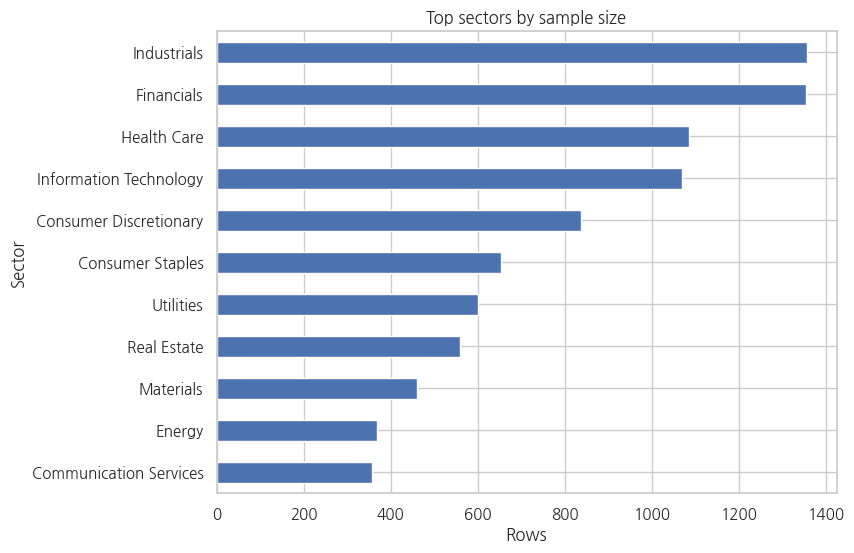

In [36]:
# ============================================================
# [변경] Industry 정책 — UNKNOWN 자동탈락 효과를 분리해 비교
# ============================================================
def build_industry_eval(panel):
    return panel.merge(
        forward_daily[["Date", "Ticker", "future_mdd_120d"]],
        on=["Date", "Ticker"], how="left", validate="one_to_one"
    ).merge(
        risk_eval[["Date", "Ticker", "future_risky_30"]],
        on=["Date", "Ticker"], how="left", validate="one_to_one"
    )

def industry_policy_table(panel, version):
    x = build_industry_eval(panel)
    x["market_stable_unknown"] = x["market_stable"] & x["industry_unknown"]
    rows = [
        summarize_policy(x.assign(flag=x["market_stable"]), "flag", f"{version} | Market Stable"),
        summarize_policy(x.assign(flag=x["balanced_verified"]), "flag", f"{version} | Balanced Verified"),
        summarize_policy(x.assign(flag=x["balanced_eligible"]), "flag", f"{version} | Balanced Eligible"),
    ]
    return x, pd.DataFrame(rows)

industry_eval_baseline, industry_policies_baseline = industry_policy_table(
    sector_panel_baseline, "BASELINE MAP"
)
industry_eval, industry_policies_final = industry_policy_table(
    sector_panel, "FINAL MAP"
)

industry_policies = pd.concat(
    [industry_policies_baseline, industry_policies_final],
    ignore_index=True
).drop_duplicates("policy")

display(industry_policies)

print("[해석 핵심]")
print("발표 표/그래프에서는 미매핑 산업 범주를 직접 노출하지 않고, Verified/Eligible 차이만 보조적으로 해석합니다.")

sector_counts = sector_panel.loc[sector_panel["Sector"].notna() & sector_panel["Sector"].astype(str).str.upper().ne("UNKNOWN"), "Sector"].value_counts().head(15)
plt.figure(figsize=(8,6))
sector_counts.sort_values().plot(kind="barh")
plt.xlabel("Rows")
plt.title("Top sectors by sample size")
plt.show()


## [H4 정책 비교 최종 해석] Industry 재검증 효과는 작지만 개선 방향

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.



### [시각화 보강] 산업별 재검증 효과를 Sector 단위로 직접 확인

기존 H4 계산은 그대로 유지합니다.  
아래 그래프는 **Market Stable → Industry Verified**로 다시 걸렀을 때 Sector별 False-Stable이 어떻게 달라졌는지 보여주는 표현 보강입니다.

주의:
- 미매핑 산업 값은 발표 표·그래프에서 제외합니다.
- Balanced Verified의 개선을 전부 Industry K-Means의 순수효과로 단정하지 않습니다.


,Sector,rows,market_candidates,balanced_candidates,market_false_stable,balanced_false_stable
5,Health Care,1086,607,497,0.1791,0.1570
2,Consumer Staples,654,560,345,0.1147,0.0805
4,Financials,1353,556,449,0.0374,0.0384
6,Industrials,1356,539,458,0.0520,0.0477
10,Utilities,601,532,391,0.0376,0.0188
9,Real Estate,560,366,247,0.1091,0.1043
1,Consumer Discretionary,838,272,255,0.1836,0.1632
7,Information Technology,1070,189,176,0.1207,0.1304
8,Materials,460,172,152,0.1392,0.1377
0,Communication Services,357,169,119,0.1104,0.0577


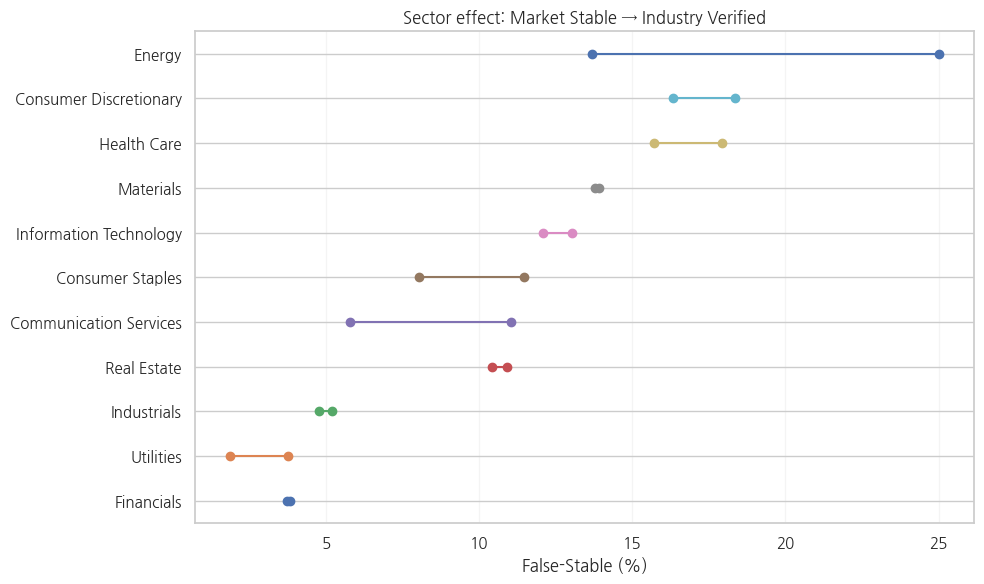

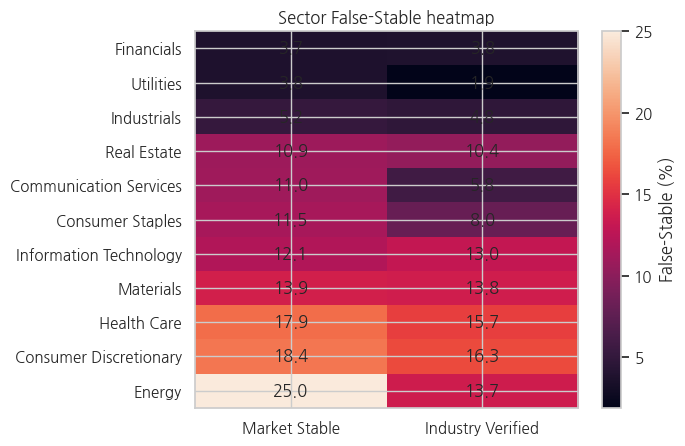

In [37]:

sector_effect_rows = []

for sector, g in industry_eval.loc[
    industry_eval["Sector"].notna()
].groupby("Sector"):
    market_flag = g["market_stable"].fillna(False)
    balanced_flag = g["balanced_verified"].fillna(False)

    if market_flag.sum() < 10:
        continue

    sector_effect_rows.append({
        "Sector": sector,
        "rows": len(g),
        "market_candidates": int(market_flag.sum()),
        "balanced_candidates": int(balanced_flag.sum()),
        "market_false_stable": g.loc[market_flag, "future_risky_30"].mean(),
        "balanced_false_stable": (
            g.loc[balanced_flag, "future_risky_30"].mean()
            if balanced_flag.sum() else np.nan
        ),
    })

sector_effect = (
    pd.DataFrame(sector_effect_rows)
    .sort_values("market_candidates", ascending=False)
)

display(sector_effect)

plot_sector = (
    sector_effect.dropna(subset=["balanced_false_stable"])
    .head(15)
    .sort_values("market_false_stable")
)

if len(plot_sector):
    y = np.arange(len(plot_sector))
    plt.figure(figsize=(10,6))
    for i, row in enumerate(plot_sector.itertuples()):
        plt.plot(
            [row.market_false_stable * 100, row.balanced_false_stable * 100],
            [i, i],
            marker="o"
        )
    plt.yticks(y, plot_sector["Sector"])
    plt.xlabel("False-Stable (%)")
    plt.title("Sector effect: Market Stable → Industry Verified")
    plt.grid(axis="x", alpha=.2)
    plt.tight_layout()
    plt.show()

    heat = (
        plot_sector.set_index("Sector")[
            ["market_false_stable","balanced_false_stable"]
        ] * 100
    )

    plt.figure(figsize=(7, max(4.5, len(heat)*0.42)))
    im = plt.imshow(heat.values, aspect="auto")
    plt.colorbar(im, label="False-Stable (%)")
    plt.xticks(
        range(2),
        ["Market Stable","Industry Verified"]
    )
    plt.yticks(range(len(heat)), heat.index)
    plt.title("Sector False-Stable heatmap")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            value = heat.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, f"{value:.1f}", ha="center", va="center")
    plt.tight_layout()
    plt.show()


## [H4 Sector별 효과] 산업마다 효과 방향이 다름

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## [실행 의존성 보존] 원본 보조정책
**원본 v13: 셀 71~75**

아래 코드는 H4 가설의 핵심 주장이 아니라,  
원본 `final_policy_df` → Date-block bootstrap → Stability Handoff가 **원래 v13과 동일하게 실행되도록 필요한 의존코드**입니다.

발표 본문에서는 축약해도 되지만 코드 실행을 위해 보존합니다.


## 변동성 보강 — Core는 유지하고 보조신호로만 사용

이 섹션은 반드시 수행합니다.

### Core는 그대로
- `Volatility_120d`
- `|Beta_120d|`

### 보조신호
1. `vol_ratio_20_120` : 최근 20일 변동성이 120일 평균보다 얼마나 커졌는지
2. `vol_ratio_60_120`
3. `vol_ratio_120_252`
4. `downside_vol_120d_aux` : 하락 수익률만 사용한 하방변동성
5. `vol_acceleration_warning` : 최근 변동성 급등 경고

### 핵심
이 보조지표를 K-Means에 넣지 않습니다.  
Stable 후보에 warning을 붙이고, **후보 감소 대비 False-Stable/MDD 개선이 실제로 있는지** 확인합니다.


In [38]:
# 16-1. Volatility ratio
# vol_aux: Core를 바꾸지 않고 변동성 보조신호만 계산하는 표
vol_aux = base120[[
    "Date","Ticker","volatility_20d","volatility_60d","volatility_120d","volatility_252d"
]].copy()

vol_aux["vol_ratio_20_120"] = vol_aux["volatility_20d"] / vol_aux["volatility_120d"]
vol_aux["vol_ratio_60_120"] = vol_aux["volatility_60d"] / vol_aux["volatility_120d"]
vol_aux["vol_ratio_120_252"] = vol_aux["volatility_120d"] / vol_aux["volatility_252d"]

# 16-2. Downside Volatility 120d 보조계산
daily = daily_prices.sort_values(["Ticker","Date"]).copy()
daily["daily_return"] = daily.groupby("Ticker")["Close"].pct_change(fill_method=None)
daily["downside_sq"] = daily["daily_return"].clip(upper=0.0).pow(2)

daily["downside_vol_120d_aux"] = (
    daily.groupby("Ticker")["downside_sq"]
    .transform(lambda s: s.rolling(120, min_periods=120).mean())
    .pow(0.5) * np.sqrt(252)
)

downside_aux = daily[["Date","Ticker","downside_vol_120d_aux"]].copy()

vol_aux = vol_aux.merge(downside_aux, on=["Date","Ticker"], how="left", validate="one_to_one")

# 각 날짜별 상대위치로 warning 생성
def pct_rank_by_date(df, col):
    return df.groupby("Date")[col].rank(pct=True)

vol_aux["ratio20_pct"] = pct_rank_by_date(vol_aux, "vol_ratio_20_120")
vol_aux["ratio60_pct"] = pct_rank_by_date(vol_aux, "vol_ratio_60_120")
vol_aux["downside_pct"] = pct_rank_by_date(vol_aux, "downside_vol_120d_aux")

# 기본 warning 기준은 상위 20%를 사용하되, 이후 결과표로 효율성을 평가
vol_aux["vol_acceleration_warning"] = (
    (vol_aux["ratio20_pct"] >= 0.80) |
    (vol_aux["ratio60_pct"] >= 0.80)
)
vol_aux["downside_warning"] = vol_aux["downside_pct"] >= 0.80

vol_policy = industry_eval.merge(
    vol_aux[[
        "Date","Ticker","vol_ratio_20_120","vol_ratio_60_120","vol_ratio_120_252",
        "downside_vol_120d_aux","vol_acceleration_warning","downside_warning"
    ]],
    on=["Date","Ticker"], how="left"
)

# 산업정보가 없는 종목은 balanced_verified로 따로 보존
vol_policy["balanced_verified"] = vol_policy["balanced_stable"]
vol_policy["market_stable_sector_unknown"] = (
    vol_policy["market_stable"] & vol_policy["industry_status"].eq("UNKNOWN")
)

vol_policy["balanced_no_vol_warning"] = (
    vol_policy["balanced_stable"] &
    ~vol_policy["vol_acceleration_warning"].fillna(False)
)
vol_policy["balanced_no_downside_warning"] = (
    vol_policy["balanced_stable"] &
    ~vol_policy["downside_warning"].fillna(False)
)
vol_policy["balanced_no_both_warning"] = (
    vol_policy["balanced_stable"] &
    ~vol_policy["vol_acceleration_warning"].fillna(False) &
    ~vol_policy["downside_warning"].fillna(False)
)

vol_policy_summary = pd.DataFrame([
    summarize_policy(vol_policy.assign(flag=vol_policy["market_stable"]), "flag", "Market Stable"),
    summarize_policy(vol_policy.assign(flag=vol_policy["balanced_stable"]), "flag", "Balanced Stable"),
    summarize_policy(vol_policy.assign(flag=vol_policy["balanced_no_vol_warning"]), "flag", "Balanced - Vol warning"),
    summarize_policy(vol_policy.assign(flag=vol_policy["balanced_no_downside_warning"]), "flag", "Balanced - Downside warning"),
    summarize_policy(vol_policy.assign(flag=vol_policy["balanced_no_both_warning"]), "flag", "Balanced - Both warnings"),
])

display(vol_policy_summary)

,policy,n,share,false_stable,future_mdd_n,future_mdd_mean,future_mdd_median,mdd_le_10,mdd_le_15,mdd_le_20
0,Market Stable,4510,0.4349,0.1208,4198,-0.1516,-0.1311,0.7025,0.4092,0.2122
1,Balanced Stable,3168,0.3055,0.0887,2942,-0.1464,-0.1262,0.6798,0.3821,0.1866
2,Balanced - Vol warning,2146,0.2069,0.0843,1993,-0.1467,-0.1255,0.6764,0.3793,0.1821
3,Balanced - Downside warning,3132,0.3020,0.0842,2909,-0.1457,-0.1260,0.6782,0.3799,0.1836
4,Balanced - Both warnings,2130,0.2054,0.0794,1978,-0.1458,-0.1251,0.6754,0.3761,0.1780


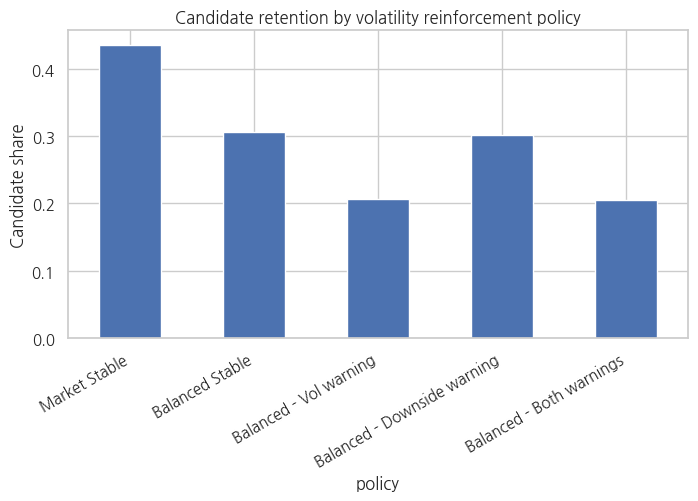

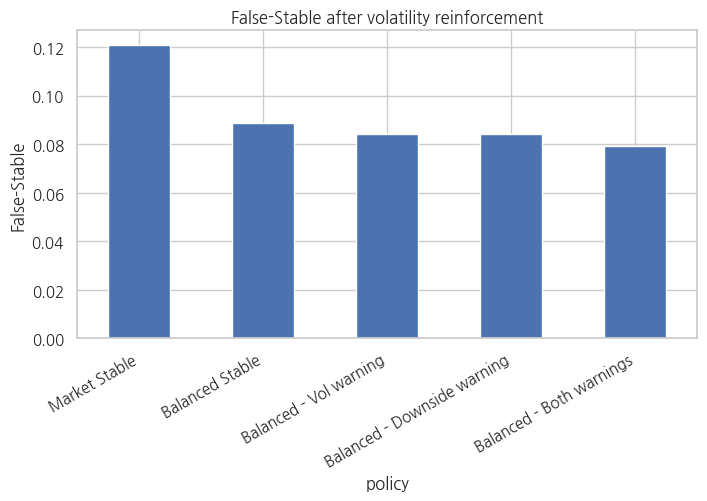

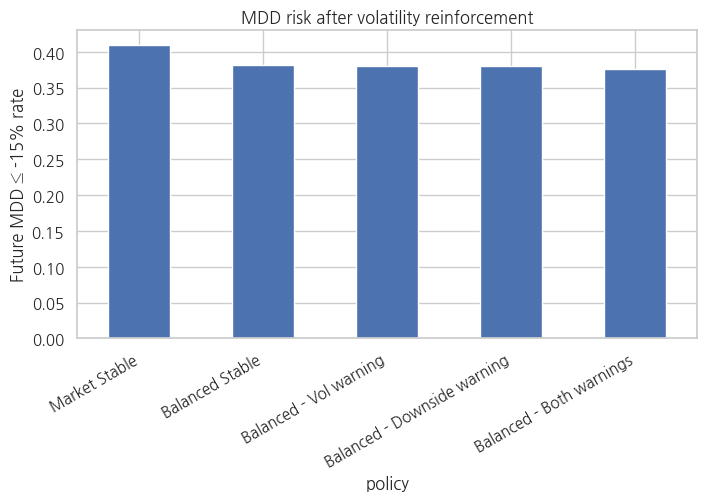

In [39]:
# 변동성 보강 시각화
plt.figure(figsize=(8,4))
vol_policy_summary.set_index("policy")["share"].plot(kind="bar")
plt.ylabel("Candidate share")
plt.title("Candidate retention by volatility reinforcement policy")
plt.xticks(rotation=30, ha="right")
plt.show()

plt.figure(figsize=(8,4))
vol_policy_summary.set_index("policy")["false_stable"].plot(kind="bar")
plt.ylabel("False-Stable")
plt.title("False-Stable after volatility reinforcement")
plt.xticks(rotation=30, ha="right")
plt.show()

plt.figure(figsize=(8,4))
vol_policy_summary.set_index("policy")["mdd_le_15"].plot(kind="bar")
plt.ylabel("Future MDD ≤ -15% rate")
plt.title("MDD risk after volatility reinforcement")
plt.xticks(rotation=30, ha="right")
plt.show()

## [H4 보조 warning 정책] 결과는 참고하되 Core 지표로 승격시키지 않음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## H4 정책효과 검증

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## 최종 정책 비교 — 후보 유지율 vs False-Stable

이 표가 프로젝트 최종 의사결정의 핵심입니다.

각 보강정책이:
- 후보를 얼마나 남기는지
- False-Stable을 얼마나 줄이는지
- MDD -15% 위험률을 얼마나 낮추는지

를 동시에 봅니다.

후보를 많이 버리는데 위험 개선이 거의 없다면 그 보강은 채택하지 않습니다.


,policy,n,share,false_stable,future_mdd_n,future_mdd_mean,future_mdd_median,mdd_le_10,mdd_le_15,mdd_le_20
0,Market Stable,4510,0.4349,0.1208,4198,-0.1516,-0.1311,0.7025,0.4092,0.2122
1,Balanced Stable,3168,0.3055,0.0887,2942,-0.1464,-0.1262,0.6798,0.3821,0.1866
2,Balanced + 252 Not-Risky,3165,0.3052,0.0888,2939,-0.1464,-0.1261,0.6798,0.3818,0.1868
3,Balanced + 252 Stable,2540,0.2449,0.0786,2353,-0.1481,-0.1278,0.6974,0.3914,0.1900
4,Balanced + recent-vol filter,2146,0.2069,0.0843,1993,-0.1467,-0.1255,0.6764,0.3793,0.1821
5,Balanced + downside filter,3132,0.3020,0.0842,2909,-0.1457,-0.1260,0.6782,0.3799,0.1836
6,Balanced + both vol filters,2130,0.2054,0.0794,1978,-0.1458,-0.1251,0.6754,0.3761,0.1780


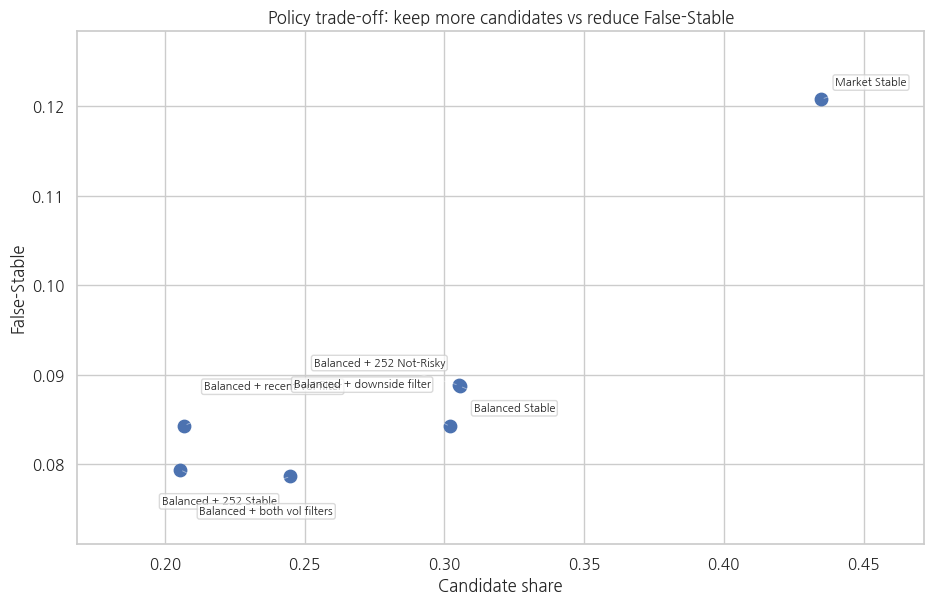

In [40]:
# final_policy_df: Market/Industry/252/변동성 보강정책을 한곳에서 비교하는 최종 정책표
final_policy_df = vol_policy.copy()

# 252 정책도 연결
p252_flags = policy_252[[
    "Date","Ticker","p120_252_not_risky","p120_252_stable"
]].copy()
final_policy_df = final_policy_df.merge(p252_flags, on=["Date","Ticker"], how="left")

# 최종 정책 후보
final_policy_df["market_only"] = final_policy_df["market_stable"]
final_policy_df["balanced"] = final_policy_df["balanced_stable"]
final_policy_df["balanced_plus_252_not_risky"] = (
    final_policy_df["balanced_stable"] & final_policy_df["p120_252_not_risky"].fillna(False)
)
final_policy_df["balanced_plus_252_stable"] = (
    final_policy_df["balanced_stable"] & final_policy_df["p120_252_stable"].fillna(False)
)
final_policy_df["balanced_plus_vol_warning_filter"] = final_policy_df["balanced_no_vol_warning"]
final_policy_df["balanced_plus_downside_filter"] = final_policy_df["balanced_no_downside_warning"]
final_policy_df["balanced_plus_both_vol_filters"] = final_policy_df["balanced_no_both_warning"]

policy_cols = {
    "market_only":"Market Stable",
    "balanced":"Balanced Stable",
    "balanced_plus_252_not_risky":"Balanced + 252 Not-Risky",
    "balanced_plus_252_stable":"Balanced + 252 Stable",
    "balanced_plus_vol_warning_filter":"Balanced + recent-vol filter",
    "balanced_plus_downside_filter":"Balanced + downside filter",
    "balanced_plus_both_vol_filters":"Balanced + both vol filters",
}

final_rows = []
for c, name in policy_cols.items():
    final_rows.append(summarize_policy(final_policy_df, c, name))

final_policy_summary = pd.DataFrame(final_rows)
display(final_policy_summary)

# 후보 유지율 vs False-Stable scatter
plt.figure(figsize=(9.5,6.2))
plt.scatter(final_policy_summary["share"], final_policy_summary["false_stable"], s=80)
_policy_offsets = [(10,12),(10,-16),(-10,16),(-10,-18),(14,28),(-14,30),(14,-30)]
for pos, (_, r) in enumerate(final_policy_summary.iterrows()):
    dx, dy = _policy_offsets[pos % len(_policy_offsets)]
    plt.annotate(
        r["policy"],
        (r["share"], r["false_stable"]),
        xytext=(dx,dy),
        textcoords="offset points",
        ha="left" if dx >= 0 else "right",
        va="center",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.72, ec="0.8"),
        arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.5),
    )
plt.xlabel("Candidate share")
plt.ylabel("False-Stable")
plt.title("Policy trade-off: keep more candidates vs reduce False-Stable")
plt.margins(x=0.16, y=0.18)
plt.tight_layout()
plt.show()


## [H4 최종 정책 trade-off] 최저 False-Stable과 후보 유지는 같은 정책이 아님

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## 정책효과 불확실성 — Date-block bootstrap

Market Stable과 Balanced Verified의 False-Stable 차이는 같은 날짜 종목들이 시장요인을 공유하므로 행 단위 bootstrap 대신 **평가일(Date)을 block으로 재표집**합니다.

이 CI는 정책효과 검증용입니다. Sector별 ML Test는 2025년 평가일이 매우 적어 block bootstrap을 적용하지 않고 날짜별 결과와 paired 비교를 그대로 표시합니다.


In [41]:
# ============================================================
# [추가] Date-block bootstrap — 정책 False-Stable 차이
# ============================================================
def false_stable_rate(df, flag_col):
    g = df[df[flag_col] & df["future_risky_30"].notna()]
    return g["future_risky_30"].mean() if len(g) else np.nan

def block_bootstrap_policy_diff(df, flag_a, flag_b, n_boot=2000, random_state=RANDOM_STATE):
    dates = pd.Index(pd.to_datetime(df["Date"].dropna().unique()))
    rng = np.random.default_rng(random_state)
    diffs = []
    for _ in range(n_boot):
        sampled = rng.choice(dates.to_numpy(), size=len(dates), replace=True)
        parts = [df[pd.to_datetime(df["Date"]).eq(d)].copy() for d in sampled]
        boot = pd.concat(parts, ignore_index=True)
        ra = false_stable_rate(boot, flag_a)
        rb = false_stable_rate(boot, flag_b)
        if pd.notna(ra) and pd.notna(rb):
            diffs.append(rb - ra)
    diffs = np.asarray(diffs, dtype=float)
    return {
        "n_dates": len(dates),
        "n_boot": len(diffs),
        "point_diff": false_stable_rate(df, flag_b) - false_stable_rate(df, flag_a),
        "ci_low": np.nanpercentile(diffs, 2.5),
        "ci_high": np.nanpercentile(diffs, 97.5),
    }

# final_policy_df 안의 market_only / balanced는 기존 정책 플래그를 그대로 사용
policy_bootstrap_ci = pd.DataFrame([
    block_bootstrap_policy_diff(final_policy_df, "market_only", "balanced")
]).assign(comparison="Balanced Stable - Market Stable")

display(policy_bootstrap_ci[["comparison", "n_dates", "n_boot", "point_diff", "ci_low", "ci_high"]])
print("※ CI가 넓다면 평가일 수가 제한적이라는 불확실성을 정직하게 반영한 결과입니다.")

,comparison,n_dates,n_boot,point_diff,ci_low,ci_high
0,Balanced Stable - Market Stable,21,2000,-0.0321,-0.0447,-0.0206


※ CI가 넓다면 평가일 수가 제한적이라는 불확실성을 정직하게 반영한 결과입니다.


## [H4 불확실성 검증] 현재 Date-resampling에서는 개선 방향이 유지되지만 확정적 95% CI로 과장하지 않음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


# PART 10. ML 보조검증 — v17 기존 검증


# H5. Sector별 별도 ML은 Global 모델보다 우월한가?

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


##Classification 보조검증

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


[Classification 연도 기반 시계열 분할]
원본 가격 데이터 종료일 : 2026-06-30
미래 검증 Horizon        : 120 trading days

Train      : ~ 2023
Validation : 2024
Test       : 2025

※ 2026년은 이후 120거래일의 정답 데이터가 충분하지 않아 동일 기준의 최종 Test로 사용하지 않습니다.


,split,start,end,rows,unique_dates,positive_rate
0,Train (<=2023),2016-06-24,2023-08-21,7818,16,0.3005
1,Validation (2024),2024-02-12,2024-08-05,995,2,0.3005
2,Test (2025),2025-01-28,2025-07-22,997,2,0.3009


[해석 주의]
Validation/Test의 rows는 종목 횡단면 수이며, unique_dates는 실제 평가시점 수입니다.
같은 날짜의 종목들은 동일 시장국면을 공유하므로 관측치의 완전한 독립성 가정이 약합니다.

[Classification Validation 모델 비교]


,model_name,accuracy,precision,recall,f1,roc_auc,pr_auc
0,DecisionTree,0.7819,0.6258,0.6823,0.6528,0.8056,0.6363
1,RandomForest,0.7819,0.6414,0.6221,0.6316,0.8121,0.6680
2,ExtraTrees,0.7879,0.6654,0.5920,0.6265,0.7985,0.6619
3,SVM,0.7799,0.6504,0.5786,0.6124,0.8010,0.6238
4,Logistic,0.7859,0.6748,0.5552,0.6092,0.7860,0.6599
5,RidgeClassifier,0.7809,0.6709,0.5318,0.5933,0.7771,0.6529
6,KNN,0.7588,0.7007,0.3445,0.4619,0.7764,0.6303
7,HistGradientBoosting,0.7628,0.7266,0.3378,0.4612,0.8039,0.6585
8,GradientBoosting,0.7588,0.7323,0.3110,0.4366,0.8150,0.6729
9,AdaBoost,0.7538,0.7109,0.3043,0.4262,0.7943,0.6151


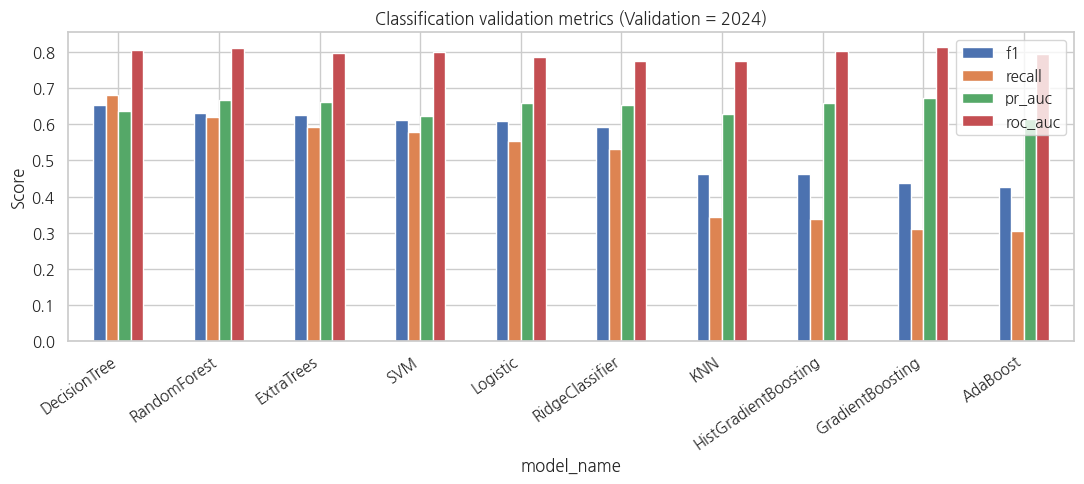


[Validation 지표별 최고 모델]
f1       : DecisionTree (0.6528)
recall   : DecisionTree (0.6823)
pr_auc   : GradientBoosting (0.6729)
roc_auc  : GradientBoosting (0.8150)


In [42]:
# ============================================================
# Classification 보조검증
# ============================================================
# 목적:
# 현재 안정성 Core 2개
#   1) volatility_120d
#   2) abs_beta
# 만으로 미래 Risky 여부를 어느 정도 구분할 수 있는지 확인합니다.
#
# 중요:
# 이 Classification은 Stable 종목을 새로 선정하는 메인 모델이 아닙니다.
# 기존 K-Means 안정성 결과를 보조적으로 검증하는 역할입니다.
#
# 시간 분할:
# Train      : 2023년까지
# Validation : 2024년
# Test       : 2025년
#
# 이유:
# 원본 가격 데이터가 2026-06-30까지이고,
# target은 이후 120거래일의 미래 위험을 이용합니다.
# 따라서 2026년에는 동일한 120일 미래 정답을 충분히 확보할 수 없습니다.
# 가장 최근의 독립 Test 가능 연도를 2025년으로 둡니다.
# ============================================================


# ------------------------------------------------------------
# 1. Classification용 데이터 준비
# ------------------------------------------------------------

# model_df:
# 현재 Core 2개 지표와 미래 Risky 정답이 모두 있는 Classification 분석표
model_df = (
    risk_eval
    .dropna(
        subset=[
            "volatility_120d",
            "abs_beta",
            "future_risky_30"
        ]
    )
    .copy()
)

model_df["Date"] = pd.to_datetime(model_df["Date"])
model_df = model_df.sort_values("Date").reset_index(drop=True)


# ------------------------------------------------------------
# 2. 입력변수 / Target 정의
# ------------------------------------------------------------

# CLS_FEATURES:
# Classification에 사용하는 현재시점 안정성 Core 2개
CLS_FEATURES = [
    "volatility_120d",
    "abs_beta"
]

# CLS_TARGET:
# 미래 위험 상위 30% 여부
CLS_TARGET = "future_risky_30"


# xy:
# DataFrame에서 모델 입력 X와 정답 y를 분리하는 함수
def xy(df):
    X = df[CLS_FEATURES].copy()
    y = df[CLS_TARGET].astype(int).copy()
    return X, y


# ------------------------------------------------------------
# 3. 연도 기반 시계열 Train / Validation / Test
# ------------------------------------------------------------
#
# 미래 데이터를 과거 학습에 섞지 않기 위해
# 시간 순서를 유지합니다.
#
# Train      : ~ 2023-12-31
# Validation : 2024-01-01 ~ 2024-12-31
# Test       : 2025-01-01 ~ 2025-12-31
#
# model_df 자체가 future target 결측치를 제외했으므로
# 미래 120일 정답이 없는 행은 포함되지 않습니다.
# ------------------------------------------------------------

# train:
# 2023년까지의 과거 학습 데이터
train = model_df[
    model_df["Date"] < pd.Timestamp("2024-01-01")
].copy()


# valid:
# 모델 비교 및 선택에 사용할 2024년 Validation
valid = model_df[
    (model_df["Date"] >= pd.Timestamp("2024-01-01"))
    &
    (model_df["Date"] < pd.Timestamp("2025-01-01"))
].copy()


# test:
# 최종 일반화 성능을 확인할 2025년 독립 Test
test = model_df[
    (model_df["Date"] >= pd.Timestamp("2025-01-01"))
    &
    (model_df["Date"] < pd.Timestamp("2026-01-01"))
].copy()


# ------------------------------------------------------------
# 4. 실제 분할 범위 확인
# ------------------------------------------------------------

# split_info:
# Train/Validation/Test가 실제로 어느 날짜와 표본을 사용하는지 확인
def split_info(name, df):

    return {
        "split": name,
        "start": df["Date"].min(),
        "end": df["Date"].max(),
        "rows": len(df),
        "unique_dates": df["Date"].nunique(),
        "positive_rate": (
            df[CLS_TARGET].mean()
            if len(df) > 0
            else np.nan
        )
    }


# split_summary_cls:
# Classification의 실제 시간분할 확인표
split_summary_cls = pd.DataFrame([
    split_info("Train (<=2023)", train),
    split_info("Validation (2024)", valid),
    split_info("Test (2025)", test)
])


print("=" * 70)
print("[Classification 연도 기반 시계열 분할]")
print("원본 가격 데이터 종료일 : 2026-06-30")
print("미래 검증 Horizon        : 120 trading days")
print()
print("Train      : ~ 2023")
print("Validation : 2024")
print("Test       : 2025")
print()
print(
    "※ 2026년은 이후 120거래일의 정답 데이터가 충분하지 않아 "
    "동일 기준의 최종 Test로 사용하지 않습니다."
)
print("=" * 70)

display(split_summary_cls)

print("[해석 주의]")
print("Validation/Test의 rows는 종목 횡단면 수이며, unique_dates는 실제 평가시점 수입니다.")
print("같은 날짜의 종목들은 동일 시장국면을 공유하므로 관측치의 완전한 독립성 가정이 약합니다.")


# 분할이 잘못되었으면 즉시 확인
if len(train) == 0:
    raise ValueError("Train 데이터가 없습니다.")

if len(valid) == 0:
    raise ValueError("2024 Validation 데이터가 없습니다.")

if len(test) == 0:
    raise ValueError(
        "2025 Test 데이터가 없습니다. "
        "model_df의 실제 날짜범위를 확인하세요."
    )


# ------------------------------------------------------------
# 5. X / y 분리
# ------------------------------------------------------------

# Xtr, ytr:
# Train 입력변수와 정답
Xtr, ytr = xy(train)

# Xva, yva:
# Validation 입력변수와 정답
Xva, yva = xy(valid)

# Xte, yte:
# Test 입력변수와 정답
Xte, yte = xy(test)


# ------------------------------------------------------------
# 6. StandardScaler
# ------------------------------------------------------------
#
# 데이터 누수를 막기 위해
# Train 데이터에만 scaler를 fit합니다.
# Validation / Test에는 transform만 적용합니다.
# ------------------------------------------------------------

# scaler_cls:
# Classification Core 2개 변수의 Train 기준 표준화기
scaler_cls = StandardScaler()

scaler_cls.fit(Xtr)

Xtr_s = scaler_cls.transform(Xtr)
Xva_s = scaler_cls.transform(Xva)
Xte_s = scaler_cls.transform(Xte)


# ------------------------------------------------------------
# 7. 기본 Classification 모델
# ------------------------------------------------------------

# clf_models:
# 동일한 Core 2개 변수로 여러 분류 알고리즘의 Validation 성능 비교
clf_models = {

    "Logistic": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "RidgeClassifier": RidgeClassifier(
        class_weight="balanced"
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=25
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "DecisionTree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=250,
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=250,
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=RANDOM_STATE
    )
}


# ------------------------------------------------------------
# 8. Classification 평가 함수
# ------------------------------------------------------------

# cls_scores:
# 한 모델을 학습하고 Validation 성능지표를 계산
def cls_scores(
    model,
    Xfit,
    yfit,
    Xeval,
    yeval
):

    model.fit(
        Xfit,
        yfit
    )

    pred = model.predict(
        Xeval
    )

    # 연속형 위험점수 생성
    if hasattr(model, "predict_proba"):

        score = model.predict_proba(
            Xeval
        )[:, 1]

    elif hasattr(model, "decision_function"):

        score = model.decision_function(
            Xeval
        )

    else:

        score = pred.astype(float)


    return {

        "accuracy":
            accuracy_score(
                yeval,
                pred
            ),

        "precision":
            precision_score(
                yeval,
                pred,
                zero_division=0
            ),

        "recall":
            recall_score(
                yeval,
                pred,
                zero_division=0
            ),

        "f1":
            f1_score(
                yeval,
                pred,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                yeval,
                score
            ),

        "pr_auc":
            average_precision_score(
                yeval,
                score
            ),

        "model":
            model,

        "score":
            score,

        "pred":
            pred
    }


# ------------------------------------------------------------
# 9. Validation 모델 비교
# ------------------------------------------------------------

# cls_results:
# 각 모델의 Validation 평가값 저장
cls_results = []

# cls_artifacts:
# 모델 객체와 prediction 결과를 이후 분석에 재사용
cls_artifacts = {}


for name, model in clf_models.items():

    r = cls_scores(
        model,
        Xtr_s,
        ytr,
        Xva_s,
        yva
    )

    cls_results.append({

        "model_name": name,

        "accuracy":
            r["accuracy"],

        "precision":
            r["precision"],

        "recall":
            r["recall"],

        "f1":
            r["f1"],

        "roc_auc":
            r["roc_auc"],

        "pr_auc":
            r["pr_auc"]
    })

    cls_artifacts[name] = r


# cls_result_df:
# 기본 Classification 모델의 Validation 성능 비교표
cls_result_df = (
    pd.DataFrame(
        cls_results
    )
    .sort_values(
        [
            "f1",
            "pr_auc",
            "recall"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print()
print("[Classification Validation 모델 비교]")
display(cls_result_df)


# ------------------------------------------------------------
# 10. Validation 그래프
# ------------------------------------------------------------

cls_result_df.set_index(
    "model_name"
)[
    [
        "f1",
        "recall",
        "pr_auc",
        "roc_auc"
    ]
].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Score")

plt.title(
    "Classification validation metrics "
    "(Validation = 2024)"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 11. 가장 좋은 지표별 모델 확인
# ------------------------------------------------------------
#
# 임의 가중치를 만들지 않습니다.
# F1 / Recall / PR-AUC / ROC-AUC를 각각 따로 확인합니다.
# ------------------------------------------------------------

print()
print("[Validation 지표별 최고 모델]")

for metric in [
    "f1",
    "recall",
    "pr_auc",
    "roc_auc"
]:

    best_row = cls_result_df.loc[
        cls_result_df[metric].idxmax()
    ]

    print(
        f"{metric:8s} : "
        f"{best_row['model_name']} "
        f"({best_row[metric]:.4f})"
    )

## [H5 Classification Validation] 행 수보다 평가일 2개가 핵심 한계

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## Classification 파라미터 튜닝 — 선택규칙을 실행 전에 고정

기존 모델군과 하이퍼파라미터 grid는 유지합니다.

### 최종 조합 선택 규칙
1. 전체 튜닝 후보의 **F1 중앙값 이상**인 조합만 guardrail 통과
2. 그 안에서 **Recall 최댓값** 선택
3. 동률이면 **PR-AUC → F1 → ROC-AUC** 순으로 비교

기존의 `0.4×F1 + 0.3×Recall + 0.3×PR-AUC` 임의 가중합은 사용하지 않습니다.


In [43]:
top3 = cls_result_df["model_name"].head(3).tolist()
print("튜닝 대상:", top3)

param_grids = {
    "Logistic": [
        {"C":c} for c in [0.01,0.1,1,10]
    ],
    "RandomForest": [
        {"n_estimators":n, "max_depth":d, "min_samples_leaf":leaf}
        for n in [150,300] for d in [4,6,8,None] for leaf in [5,10,20]
    ],
    "ExtraTrees": [
        {"n_estimators":n, "max_depth":d, "min_samples_leaf":leaf}
        for n in [150,300] for d in [4,6,8,None] for leaf in [5,10,20]
    ],
    "DecisionTree": [
        {"max_depth":d, "min_samples_leaf":leaf}
        for d in [3,5,8,None] for leaf in [5,10,20]
    ],
    "GradientBoosting": [
        {"n_estimators":n, "learning_rate":lr, "max_depth":d}
        for n in [100,200] for lr in [0.03,0.1] for d in [2,3]
    ],
    "HistGradientBoosting": [
        {"learning_rate":lr, "max_leaf_nodes":leaf}
        for lr in [0.03,0.1] for leaf in [15,31]
    ],
    "AdaBoost": [
        {"n_estimators":n, "learning_rate":lr}
        for n in [50,100,200] for lr in [0.03,0.1,0.5]
    ],
    "KNN": [
        {"n_neighbors":k} for k in [10,25,50,100]
    ],
    "SVM": [
        {"C":c, "gamma":g} for c in [0.1,1,10] for g in ["scale","auto"]
    ],
    "RidgeClassifier": [
        {"alpha":a} for a in [0.1,1,10]
    ]
}

def build_clf(name, params):
    if name=="Logistic":
        return LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE, **params)
    if name=="RidgeClassifier":
        return RidgeClassifier(class_weight="balanced", **params)
    if name=="KNN":
        return KNeighborsClassifier(**params)
    if name=="SVM":
        return SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE, **params)
    if name=="DecisionTree":
        return DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE, **params)
    if name=="RandomForest":
        return RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, **params)
    if name=="ExtraTrees":
        return ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, **params)
    if name=="GradientBoosting":
        return GradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    if name=="HistGradientBoosting":
        return HistGradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    if name=="AdaBoost":
        return AdaBoostClassifier(random_state=RANDOM_STATE, **params)
    raise ValueError(name)

tuning_rows = []
for name in top3:
    for params in param_grids.get(name, [{}]):
        model = build_clf(name, params)
        r = cls_scores(model, Xtr_s, ytr, Xva_s, yva)
        tuning_rows.append({
            "model":name, "params":params,
            "f1":r["f1"], "recall":r["recall"],
            "pr_auc":r["pr_auc"], "roc_auc":r["roc_auc"]
        })

tuning_df = pd.DataFrame(tuning_rows)

# [변경] 임의 가중합 삭제. 실행 전에 선언한 lexicographic 규칙 적용
f1_guardrail = tuning_df["f1"].median()
tuning_eligible = tuning_df[tuning_df["f1"] >= f1_guardrail].copy()

best_tuned = (
    tuning_eligible
    .sort_values(
        ["recall", "pr_auc", "f1", "roc_auc"],
        ascending=[False, False, False, False]
    )
    .iloc[0]
)

print(f"F1 guardrail (전체 튜닝후보 중앙값) = {f1_guardrail:.4f}")
print("guardrail 통과 조합 수:", len(tuning_eligible), "/", len(tuning_df))
display(
    tuning_eligible
    .sort_values(["recall", "pr_auc", "f1", "roc_auc"], ascending=False)
    .head(20)
)
print("최종 튜닝 선택 (Recall primary):", best_tuned.to_dict())

튜닝 대상: ['DecisionTree', 'RandomForest', 'ExtraTrees']
F1 guardrail (전체 튜닝후보 중앙값) = 0.6223
guardrail 통과 조합 수: 30 / 60


,model,params,f1,recall,pr_auc,roc_auc
4,DecisionTree,"{'max_depth': 5, 'min_samples_leaf': 10}",0.6471,0.6990,0.6358,0.8034
5,DecisionTree,"{'max_depth': 5, 'min_samples_leaf': 20}",0.6471,0.6990,0.6340,0.8034
0,DecisionTree,"{'max_depth': 3, 'min_samples_leaf': 5}",0.6499,0.6923,0.6154,0.8103
1,DecisionTree,"{'max_depth': 3, 'min_samples_leaf': 10}",0.6499,0.6923,0.6154,0.8103
2,DecisionTree,"{'max_depth': 3, 'min_samples_leaf': 20}",0.6499,0.6923,0.6154,0.8103
3,DecisionTree,"{'max_depth': 5, 'min_samples_leaf': 5}",0.6528,0.6823,0.6363,0.8056
8,DecisionTree,"{'max_depth': 8, 'min_samples_leaf': 20}",0.6281,0.6722,0.6442,0.7880
6,DecisionTree,"{'max_depth': 8, 'min_samples_leaf': 5}",0.6309,0.6488,0.6281,0.7854
12,RandomForest,"{'n_estimators': 150, 'max_depth': 4, 'min_sam...",0.6332,0.6321,0.6700,0.8102
24,RandomForest,"{'n_estimators': 300, 'max_depth': 4, 'min_sam...",0.6321,0.6321,0.6691,0.8102


최종 튜닝 선택 (Recall primary): {'model': 'DecisionTree', 'params': {'max_depth': 5, 'min_samples_leaf': 10}, 'f1': 0.6470588235294118, 'recall': 0.6989966555183946, 'pr_auc': 0.6358434005789306, 'roc_auc': 0.8033507284819129}


## [H5 Classification 튜닝] Recall-primary 선택은 일관되지만 Validation 자체가 얕음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


In [44]:
# ============================================================
# [최종] Classification Test — 모델/파라미터 확정 후 1회 평가
# ============================================================
# final_clf: Validation에서 선택된 모델 구조를 Train+Validation으로 재학습한 최종 분류모델

final_clf_name = best_tuned["model"]
final_clf_params = best_tuned["params"]
final_clf = build_clf(final_clf_name, final_clf_params)

# train_valid_cls: 최종 학습에 사용할 과거 Train + Validation 데이터
train_valid_cls = pd.concat([train, valid], ignore_index=True)
Xtv, ytv = xy(train_valid_cls)

# scaler_cls_final: Train+Validation만으로 다시 맞춘 최종 표준화기
scaler_cls_final = StandardScaler().fit(Xtv)
Xtv_s = scaler_cls_final.transform(Xtv)
Xte_final_s = scaler_cls_final.transform(Xte)

final_clf.fit(Xtv_s, ytv)
test_pred = final_clf.predict(Xte_final_s)

# test_score: ROC-AUC / PR-AUC 계산용 연속 위험점수
if hasattr(final_clf, "predict_proba"):
    test_score = final_clf.predict_proba(Xte_final_s)[:,1]
elif hasattr(final_clf, "decision_function"):
    raw = final_clf.decision_function(Xte_final_s)
    test_score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
else:
    test_score = test_pred.astype(float)

classification_test = pd.DataFrame([{
    "model": final_clf_name,
    "params": final_clf_params,
    "accuracy": accuracy_score(yte, test_pred),
    "precision": precision_score(yte, test_pred, zero_division=0),
    "recall": recall_score(yte, test_pred, zero_division=0),
    "f1": f1_score(yte, test_pred, zero_division=0),
    "roc_auc": roc_auc_score(yte, test_score),
    "pr_auc": average_precision_score(yte, test_score),
    "test_rows": len(yte),
    "test_positive_rate": yte.mean(),
}])

print("Classification 최종 Test")
display(classification_test)

# classification_test_confusion: Test 혼동행렬
classification_test_confusion = pd.DataFrame(
    confusion_matrix(yte, test_pred),
    index=["Actual Safe", "Actual Risky"],
    columns=["Pred Safe", "Pred Risky"]
)
display(classification_test_confusion)

Classification 최종 Test


,model,params,accuracy,precision,recall,f1,roc_auc,pr_auc,test_rows,test_positive_rate
0,DecisionTree,"{'max_depth': 5, 'min_samples_leaf': 10}",0.7081,0.5097,0.7867,0.6186,0.8141,0.6604,997,0.3009


,Pred Safe,Pred Risky
Actual Safe,470,227
Actual Risky,64,236


## [H5 Classification Test] Risky 탐지는 높지만 False Positive가 많음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


##Classification 추가 모델 확장 검증 — 기존 선택 로직은 변경하지 않음

기존 Classification 결과를 수정하지 않고, **Core 2개 지표가 다양한 알고리즘에서도 미래 Risky를 구분하는지** 추가로 확인합니다.

추가 모델은 GaussianNB, LDA, QDA, SGD(Log Loss), MLP, Passive-Aggressive입니다.

- 새로운 가중치나 임의 종합점수는 만들지 않습니다.
- 동일한 Train / Validation 시간분할과 동일한 입력변수 `Volatility_120d + |Beta_120d|`만 사용합니다.
- 각 모델은 F1, Recall, ROC-AUC, PR-AUC를 나란히 보여주며 특정 지표를 임의 비율로 합치지 않습니다.
- 이 섹션은 기존 ExtraTrees 최종 Test를 삭제하거나 바꾸는 것이 아니라 **추가적인 강건성 비교**입니다.


,model_name,accuracy,precision,recall,f1,roc_auc,pr_auc
8,GradientBoosting,0.7588,0.7323,0.3110,0.4366,0.8150,0.6729
1,RandomForest,0.7819,0.6414,0.6221,0.6316,0.8121,0.6680
14,MLP,0.7568,0.7355,0.2977,0.4238,0.8121,0.6642
2,ExtraTrees,0.7879,0.6654,0.5920,0.6265,0.7985,0.6619
4,Logistic,0.7859,0.6748,0.5552,0.6092,0.7860,0.6599
13,SGD_LogLoss,0.7487,0.8267,0.2074,0.3316,0.7860,0.6599
7,HistGradientBoosting,0.7628,0.7266,0.3378,0.4612,0.8039,0.6585
11,LDA,0.7568,0.8353,0.2375,0.3698,0.7842,0.6582
5,RidgeClassifier,0.7809,0.6709,0.5318,0.5933,0.7771,0.6529
12,QDA,0.7487,0.8101,0.2140,0.3386,0.7760,0.6444


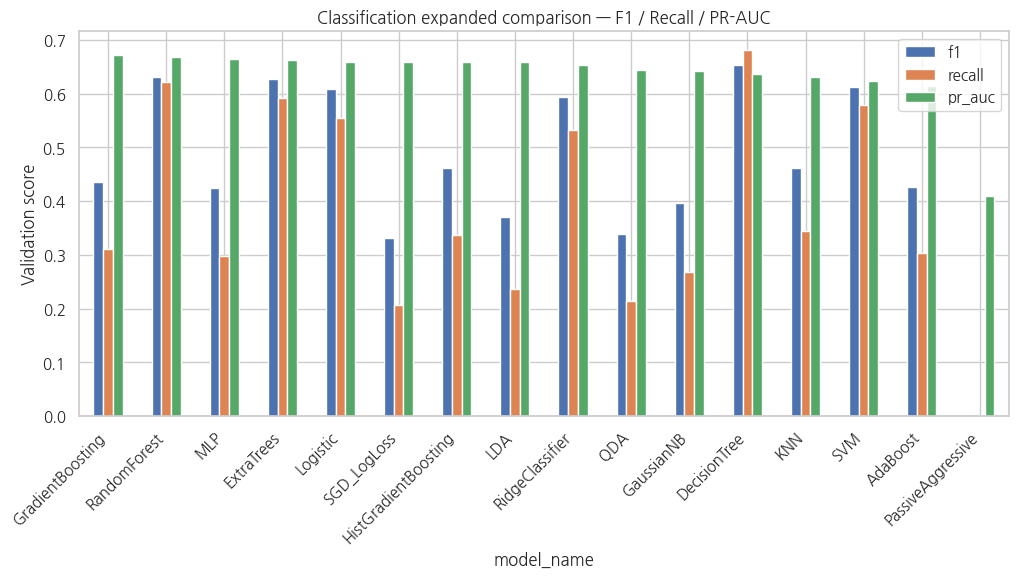

f1 최고: DecisionTree (0.6528)
recall 최고: DecisionTree (0.6823)
pr_auc 최고: GradientBoosting (0.6729)
roc_auc 최고: GradientBoosting (0.8150)


In [45]:
# ============================================================
# Classification 추가 모델 확장 검증
# ============================================================
# cls_extra_models: 기존 모델에 없던 분류 알고리즘의 보조 비교 목록

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier
from sklearn.neural_network import MLPClassifier

cls_extra_models = {
    "GaussianNB": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "SGD_LogLoss": SGDClassifier(
        loss="log_loss",
        random_state=RANDOM_STATE
    ),
    "MLP": MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    "PassiveAggressive": PassiveAggressiveClassifier(
        random_state=RANDOM_STATE
    ),
}

# cls_extra_rows: 추가 분류모델별 Validation 성능 저장
cls_extra_rows = []

for name, model in cls_extra_models.items():
    model.fit(Xtr_s, ytr)
    pred = model.predict(Xva_s)

    # score: ROC-AUC / PR-AUC 계산을 위한 연속형 위험점수
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(Xva_s)[:, 1]
    elif hasattr(model, "decision_function"):
        score = model.decision_function(Xva_s)
    else:
        score = pred.astype(float)

    cls_extra_rows.append({
        "model_name": name,
        "accuracy": accuracy_score(yva, pred),
        "precision": precision_score(yva, pred, zero_division=0),
        "recall": recall_score(yva, pred, zero_division=0),
        "f1": f1_score(yva, pred, zero_division=0),
        "roc_auc": roc_auc_score(yva, score),
        "pr_auc": average_precision_score(yva, score),
    })

# cls_extra_result_df: 추가된 모델들의 Validation 비교표
cls_extra_result_df = pd.DataFrame(cls_extra_rows)

# cls_all_validation_compare: 기존 모델 + 추가 모델을 한 표에서 비교
cls_all_validation_compare = pd.concat(
    [
        cls_result_df[
            ["model_name","accuracy","precision","recall","f1","roc_auc","pr_auc"]
        ],
        cls_extra_result_df[
            ["model_name","accuracy","precision","recall","f1","roc_auc","pr_auc"]
        ],
    ],
    ignore_index=True
).drop_duplicates("model_name", keep="first")

display(
    cls_all_validation_compare
    .sort_values("pr_auc", ascending=False)
)

# 지표를 임의 가중합하지 않고 F1 / Recall / PR-AUC를 각각 함께 표시
cls_all_validation_compare.set_index("model_name")[
    ["f1","recall","pr_auc"]
].sort_values("pr_auc", ascending=False).plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Validation score")
plt.title("Classification expanded comparison — F1 / Recall / PR-AUC")
plt.xticks(rotation=45, ha="right")
plt.show()

# 지표별 최고 모델을 각각 출력하여 임의 종합가중치를 피함
for metric in ["f1","recall","pr_auc","roc_auc"]:
    best_row = cls_all_validation_compare.loc[
        cls_all_validation_compare[metric].idxmax()
    ]
    print(
        f"{metric} 최고: {best_row['model_name']} "
        f"({best_row[metric]:.4f})"
    )

## [H5 추가 Classification 모델] 알고리즘을 늘려도 결론은 크게 바뀌지 않음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


### 추가 Classification 그래프 해석 방법

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## Regression 보조검증

### 질문
현재 `Volatility + |Beta|`가 미래 위험의 **크기**를 얼마나 설명할 수 있는가?

- Linear/Ridge/Lasso/ElasticNet: 선형관계
- KNN/SVR: 주변/비선형 관계
- Tree/RandomForest/ExtraTrees: 조건분기와 비선형 상호작용
- Boosting: 오차를 순차적으로 보완

Regression 역시 후보 생성 엔진이 아니라 **설명력 보조검증**입니다.


[Regression 연도 기반 시계열 분할]
원본 가격 데이터 종료일 : 2026-06-30
미래 검증 Horizon        : 120 trading days

Train      : ~ 2023
Validation : 2024
Test       : 2025

※ 2026년은 이후 120거래일 미래 정답을 동일 기준으로 확보할 수 없어 Test로 사용하지 않습니다.


,split,start,end,rows,unique_dates,target_mean
0,Train (<=2023),2016-06-24,2023-08-21,7818,16,-0.0000
1,Validation (2024),2024-02-12,2024-08-05,995,2,-0.0000
2,Test (2025),2025-01-28,2025-07-22,997,2,-0.0000


[Regression target 해석]
future_risk_score는 날짜별 z-score 결합이므로 split의 target_mean이 0 근처인 것이 정상입니다.
R²는 절대 위험수준보다 같은 날짜 안 종목 간 상대위험 차이 설명력으로 해석합니다.

[Regression Validation 모델 비교]


,model,mae,rmse,r2
0,RandomForest,0.4936,0.7379,0.3500
1,DecisionTree,0.5031,0.7468,0.3343
2,Linear,0.5085,0.7474,0.3332
3,Ridge,0.5085,0.7474,0.3332
4,ElasticNet,0.5085,0.7474,0.3331
5,Lasso,0.5085,0.7474,0.3331
6,ExtraTrees,0.5063,0.7481,0.3319
7,GradientBoosting,0.4942,0.7494,0.3296
8,HistGradientBoosting,0.5042,0.7512,0.3264
9,KNN,0.5080,0.7545,0.3204


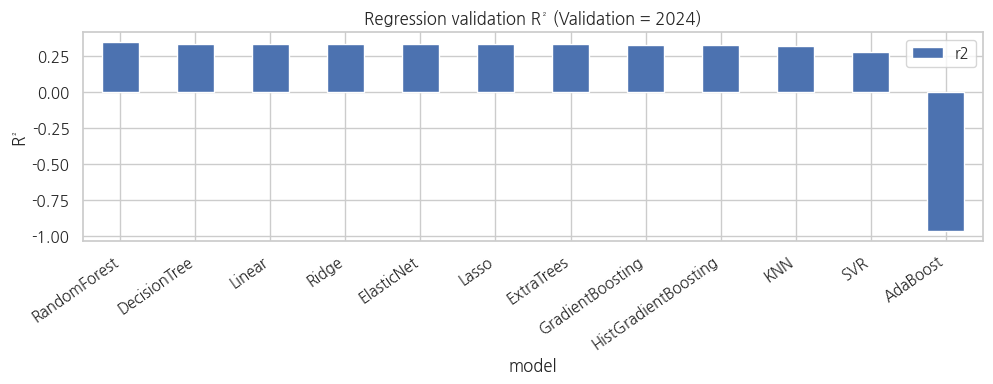

Validation R² 최고 모델: RandomForest


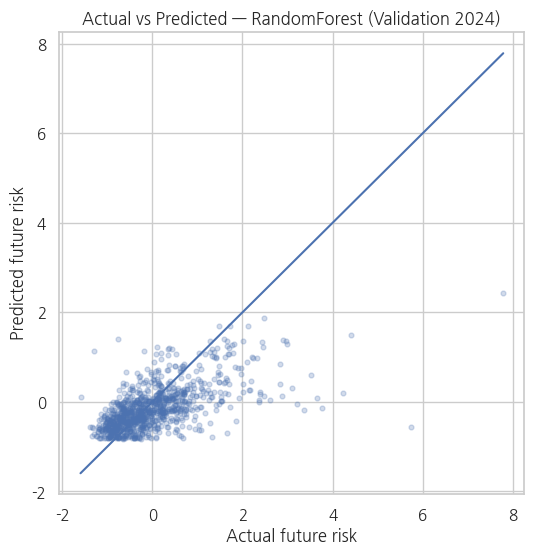

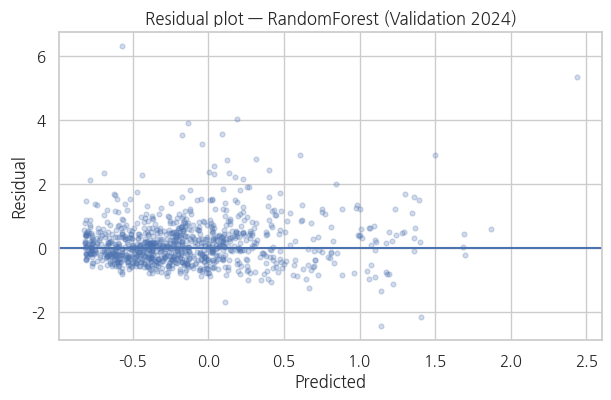

In [46]:
# ============================================================
# Regression 보조검증
# ============================================================
# 목적:
# 현재 안정성 Core 2개
#   1) volatility_120d
#   2) abs_beta
# 만으로 미래 위험의 "크기"를 어느 정도 설명할 수 있는지 확인합니다.
#
# 중요:
# Regression은 Stable 종목을 새로 선정하는 메인 모델이 아닙니다.
# 기존 K-Means 안정성 결과를 보조적으로 검증하는 역할입니다.
#
# 시간 분할:
# Train      : 2023년까지
# Validation : 2024년
# Test       : 2025년
#
# 이유:
# 원본 가격 데이터가 2026-06-30까지이고,
# Target은 이후 120거래일 미래 위험을 사용합니다.
# 따라서 2026년은 동일한 120일 미래 정답을 충분히 확보할 수 없어
# 최종 독립 Test는 2025년으로 설정합니다.
# ============================================================


# ------------------------------------------------------------
# 1. Regression 데이터 준비
# ------------------------------------------------------------

# reg_df:
# 현재 Core 2개 지표와 미래 연속형 위험점수가 모두 존재하는 회귀 분석표
reg_df = (
    risk_eval
    .dropna(
        subset=[
            "volatility_120d",
            "abs_beta",
            "future_risk_score"
        ]
    )
    .copy()
)

reg_df["Date"] = pd.to_datetime(reg_df["Date"])
reg_df = (
    reg_df
    .sort_values("Date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. 입력변수 / Target 정의
# ------------------------------------------------------------

# REG_FEATURES:
# Regression에서 사용할 현재시점 안정성 Core 2개
REG_FEATURES = [
    "volatility_120d",
    "abs_beta"
]

# REG_TARGET:
# 미래 위험의 연속형 정답값
REG_TARGET = "future_risk_score"


# xy_reg:
# Regression용 X와 y를 분리하는 함수
def xy_reg(df):
    X = df[REG_FEATURES].copy()
    y = df[REG_TARGET].astype(float).copy()
    return X, y


# ------------------------------------------------------------
# 3. 연도 기반 Train / Validation / Test 분리
# ------------------------------------------------------------
#
# Train      : ~ 2023-12-31
# Validation : 2024-01-01 ~ 2024-12-31
# Test       : 2025-01-01 ~ 2025-12-31
#
# reg_df는 이미 future_risk_score 결측치를 제거했기 때문에
# 미래 정답을 계산할 수 없는 행은 자동 제외됩니다.
# ------------------------------------------------------------

# train_r:
# 2023년까지의 과거 회귀 학습 데이터
train_r = reg_df[
    reg_df["Date"] < pd.Timestamp("2024-01-01")
].copy()


# valid_r:
# 모델 비교/선택에 사용할 2024년 Validation
valid_r = reg_df[
    (reg_df["Date"] >= pd.Timestamp("2024-01-01"))
    &
    (reg_df["Date"] < pd.Timestamp("2025-01-01"))
].copy()


# test_r:
# 최종 일반화 성능 확인용 2025년 독립 Test
test_r = reg_df[
    (reg_df["Date"] >= pd.Timestamp("2025-01-01"))
    &
    (reg_df["Date"] < pd.Timestamp("2026-01-01"))
].copy()


# ------------------------------------------------------------
# 4. 실제 분할 범위 확인
# ------------------------------------------------------------

# split_info_reg:
# Regression Train/Validation/Test의 실제 날짜·행 수 확인
def split_info_reg(name, df):
    return {
        "split": name,
        "start": df["Date"].min(),
        "end": df["Date"].max(),
        "rows": len(df),
        "unique_dates": df["Date"].nunique(),
        "target_mean": (
            df[REG_TARGET].mean()
            if len(df) > 0
            else np.nan
        )
    }


# split_summary_reg:
# 실제 회귀 시간분할 확인표
split_summary_reg = pd.DataFrame([
    split_info_reg(
        "Train (<=2023)",
        train_r
    ),
    split_info_reg(
        "Validation (2024)",
        valid_r
    ),
    split_info_reg(
        "Test (2025)",
        test_r
    )
])


print("=" * 70)
print("[Regression 연도 기반 시계열 분할]")
print("원본 가격 데이터 종료일 : 2026-06-30")
print("미래 검증 Horizon        : 120 trading days")
print()
print("Train      : ~ 2023")
print("Validation : 2024")
print("Test       : 2025")
print()
print(
    "※ 2026년은 이후 120거래일 미래 정답을 "
    "동일 기준으로 확보할 수 없어 Test로 사용하지 않습니다."
)
print("=" * 70)

display(split_summary_reg)

print("[Regression target 해석]")
print("future_risk_score는 날짜별 z-score 결합이므로 split의 target_mean이 0 근처인 것이 정상입니다.")
print("R²는 절대 위험수준보다 같은 날짜 안 종목 간 상대위험 차이 설명력으로 해석합니다.")


# 분할 오류 즉시 확인
if len(train_r) == 0:
    raise ValueError(
        "Regression Train 데이터가 없습니다."
    )

if len(valid_r) == 0:
    raise ValueError(
        "Regression 2024 Validation 데이터가 없습니다."
    )

if len(test_r) == 0:
    raise ValueError(
        "Regression 2025 Test 데이터가 없습니다. "
        "reg_df의 실제 날짜범위를 확인하세요."
    )


# ------------------------------------------------------------
# 5. X / y 분리
# ------------------------------------------------------------

# Xtr_r, ytr_r:
# Train 입력변수와 정답
Xtr_r, ytr_r = xy_reg(train_r)

# Xva_r, yva_r:
# Validation 입력변수와 정답
Xva_r, yva_r = xy_reg(valid_r)

# Xte_r, yte_r:
# Test 입력변수와 정답
Xte_r, yte_r = xy_reg(test_r)


# ------------------------------------------------------------
# 6. StandardScaler
# ------------------------------------------------------------
#
# Train에만 scaler를 fit하여
# Validation/Test 미래정보가 학습과정에 들어가지 않도록 합니다.
# ------------------------------------------------------------

# scaler_reg:
# Regression Core 2개 변수의 Train 기준 표준화기
scaler_reg = StandardScaler()

scaler_reg.fit(Xtr_r)

Xtr_rs = scaler_reg.transform(Xtr_r)
Xva_rs = scaler_reg.transform(Xva_r)
Xte_rs = scaler_reg.transform(Xte_r)


# ------------------------------------------------------------
# 7. Regression 모델 정의
# ------------------------------------------------------------

# reg_models:
# 동일한 Core 2개 변수로 여러 회귀 알고리즘을 비교
reg_models = {

    "Linear":
        LinearRegression(),

    "Ridge":
        Ridge(
            alpha=1.0
        ),

    "Lasso":
        Lasso(
            alpha=0.001
        ),

    "ElasticNet":
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5
        ),

    "KNN":
        KNeighborsRegressor(
            n_neighbors=25
        ),

    "SVR":
        SVR(
            C=1.0
        ),

    "DecisionTree":
        DecisionTreeRegressor(
            max_depth=5,
            min_samples_leaf=10,
            random_state=RANDOM_STATE
        ),

    "RandomForest":
        RandomForestRegressor(
            n_estimators=250,
            max_depth=6,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "ExtraTrees":
        ExtraTreesRegressor(
            n_estimators=250,
            max_depth=6,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "GradientBoosting":
        GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ),

    "HistGradientBoosting":
        HistGradientBoostingRegressor(
            random_state=RANDOM_STATE
        ),

    "AdaBoost":
        AdaBoostRegressor(
            random_state=RANDOM_STATE
        ),
}


# ------------------------------------------------------------
# 8. Validation 모델 비교
# ------------------------------------------------------------

# reg_rows:
# 모델별 Validation MAE / RMSE / R² 저장
reg_rows = []

# reg_artifacts:
# 학습된 모델과 Validation 예측값 보존
reg_artifacts = {}


for name, model in reg_models.items():

    model.fit(
        Xtr_rs,
        ytr_r
    )

    pred = model.predict(
        Xva_rs
    )

    reg_rows.append({
        "model":
            name,

        "mae":
            mean_absolute_error(
                yva_r,
                pred
            ),

        "rmse":
            mean_squared_error(
                yva_r,
                pred
            ) ** 0.5,

        "r2":
            r2_score(
                yva_r,
                pred
            )
    })

    reg_artifacts[name] = (
        model,
        pred
    )


# reg_result_df:
# Regression Validation 성능 비교표
reg_result_df = (
    pd.DataFrame(
        reg_rows
    )
    .sort_values(
        "r2",
        ascending=False
    )
    .reset_index(drop=True)
)


print()
print("[Regression Validation 모델 비교]")
display(reg_result_df)


# ------------------------------------------------------------
# 9. R² 비교 그래프
# ------------------------------------------------------------

reg_result_df.set_index(
    "model"
)[
    ["r2"]
].plot(
    kind="bar",
    figsize=(10, 4)
)

plt.ylabel("R²")

plt.title(
    "Regression validation R² "
    "(Validation = 2024)"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Validation 기준 최고 R² 모델
# ------------------------------------------------------------

# best_reg_name:
# 2024 Validation에서 R²가 가장 높은 모델
best_reg_name = (
    reg_result_df
    .iloc[0]["model"]
)

# best_reg_pred:
# 최고 모델의 2024 Validation 예측값
best_reg_pred = (
    reg_artifacts[
        best_reg_name
    ][1]
)

print(
    f"Validation R² 최고 모델: "
    f"{best_reg_name}"
)


# ------------------------------------------------------------
# 11. Actual vs Predicted
# ------------------------------------------------------------

plt.figure(
    figsize=(6, 6)
)

plt.scatter(
    yva_r,
    best_reg_pred,
    alpha=0.25,
    s=12
)

mn = min(
    np.nanmin(yva_r),
    np.nanmin(best_reg_pred)
)

mx = max(
    np.nanmax(yva_r),
    np.nanmax(best_reg_pred)
)

plt.plot(
    [mn, mx],
    [mn, mx]
)

plt.xlabel(
    "Actual future risk"
)

plt.ylabel(
    "Predicted future risk"
)

plt.title(
    f"Actual vs Predicted — "
    f"{best_reg_name} "
    f"(Validation 2024)"
)

plt.show()


# ------------------------------------------------------------
# 12. Residual Plot
# ------------------------------------------------------------

# resid:
# 실제 미래위험 - 예측 미래위험
resid = (
    yva_r
    - best_reg_pred
)

plt.figure(
    figsize=(7, 4)
)

plt.scatter(
    best_reg_pred,
    resid,
    alpha=0.25,
    s=12
)

plt.axhline(
    0
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Residual"
)

plt.title(
    f"Residual plot — "
    f"{best_reg_name} "
    f"(Validation 2024)"
)

plt.show()

## [H5 Regression Validation] Core 2개는 미래 상대위험 일부를 설명하지만 충분하지 않음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


Regression 최종 Test


,model,mae,rmse,r2,test_rows
0,RandomForest,0.5551,0.7318,0.3874,997


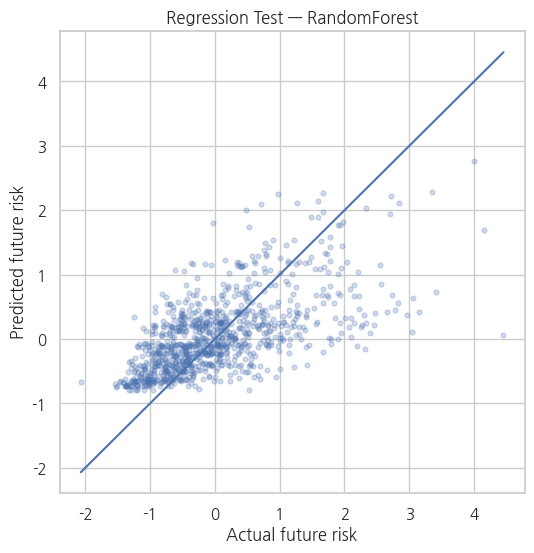

In [47]:
# ============================================================
# [최종] Regression Test — Validation 최고 모델을 미래 Test에서 1회 평가
# ============================================================
# final_reg_name: Validation R²가 가장 높았던 회귀모델 이름
final_reg_name = best_reg_name

# final_reg: Validation에서 선택된 모델과 동일한 설정의 새 모델
final_reg = reg_models[final_reg_name]

# train_valid_reg: 최종 학습용 Train + Validation 회귀 데이터
train_valid_reg = pd.concat([train_r, valid_r], ignore_index=True)
Xtv_r, ytv_r = xy_reg(train_valid_reg)

# scaler_reg_final: Train+Validation에만 맞춘 최종 회귀 표준화기
scaler_reg_final = StandardScaler().fit(Xtv_r)
Xtv_rs = scaler_reg_final.transform(Xtv_r)
Xte_final_rs = scaler_reg_final.transform(Xte_r)

final_reg.fit(Xtv_rs, ytv_r)

# reg_test_pred: 가장 미래 Test 구간의 미래위험 예측값
reg_test_pred = final_reg.predict(Xte_final_rs)

regression_test = pd.DataFrame([{
    "model": final_reg_name,
    "mae": mean_absolute_error(yte_r, reg_test_pred),
    "rmse": mean_squared_error(yte_r, reg_test_pred) ** 0.5,
    "r2": r2_score(yte_r, reg_test_pred),
    "test_rows": len(yte_r),
}])

print("Regression 최종 Test")
display(regression_test)

plt.figure(figsize=(6,6))
plt.scatter(yte_r, reg_test_pred, alpha=0.25, s=12)
mn = min(np.nanmin(yte_r), np.nanmin(reg_test_pred))
mx = max(np.nanmax(yte_r), np.nanmax(reg_test_pred))
plt.plot([mn,mx],[mn,mx])
plt.xlabel("Actual future risk")
plt.ylabel("Predicted future risk")
plt.title(f"Regression Test — {final_reg_name}")
plt.show()

## [H5 Regression Test] RandomForest Test R² 0.3874 — 보조적인 연관성은 확인

Validation R²가 가장 높았던 RandomForest를 Train+Validation으로 다시 학습해 Test에서 1회 평가한 결과는 MAE **0.5551**, RMSE **0.7318**, R² **0.3874**, Test rows **997**입니다. Validation R² **0.3500**보다 Test에서 낮아지지 않았고, 오히려 소폭 높게 나타났습니다.

다만 Test 역시 **평가일 2개**에 불과합니다. 따라서 “Core 2개가 미래 상대위험과 일정한 관련성을 보였다”는 보조근거로는 사용할 수 있지만, 이를 장기 일반 예측 정확도 **38.74%**라고 표현해서는 안 됩니다.


## Regression 추가 모델 확장 검증 — 기존 결과를 보존한 보조 비교

기존 회귀모델을 수정하지 않고, 선형·강건회귀·온라인학습·신경망 계열을 추가해 **복잡한 모델이 실제로 미래 위험 설명력을 높이는지** 확인합니다.

추가 모델은 Bayesian Ridge, Huber, SGD, Passive-Aggressive, MLP, RANSAC입니다.

- 기존 Train / Validation 시간분할을 그대로 사용합니다.
- 입력변수는 계속 `Volatility_120d + |Beta_120d|` 두 개뿐입니다.
- MAE·RMSE는 낮을수록, R²는 높을수록 좋다고 각각 비교하며 임의 종합가중치는 사용하지 않습니다.


,model,mae,rmse,r2
16,MLPRegressor,0.4917,0.7347,0.3556
0,RandomForest,0.4936,0.7379,0.3500
1,DecisionTree,0.5031,0.7468,0.3343
2,Linear,0.5085,0.7474,0.3332
3,Ridge,0.5085,0.7474,0.3332
12,BayesianRidge,0.5085,0.7474,0.3331
4,ElasticNet,0.5085,0.7474,0.3331
5,Lasso,0.5085,0.7474,0.3331
14,SGDRegressor,0.5091,0.7477,0.3326
6,ExtraTrees,0.5063,0.7481,0.3319


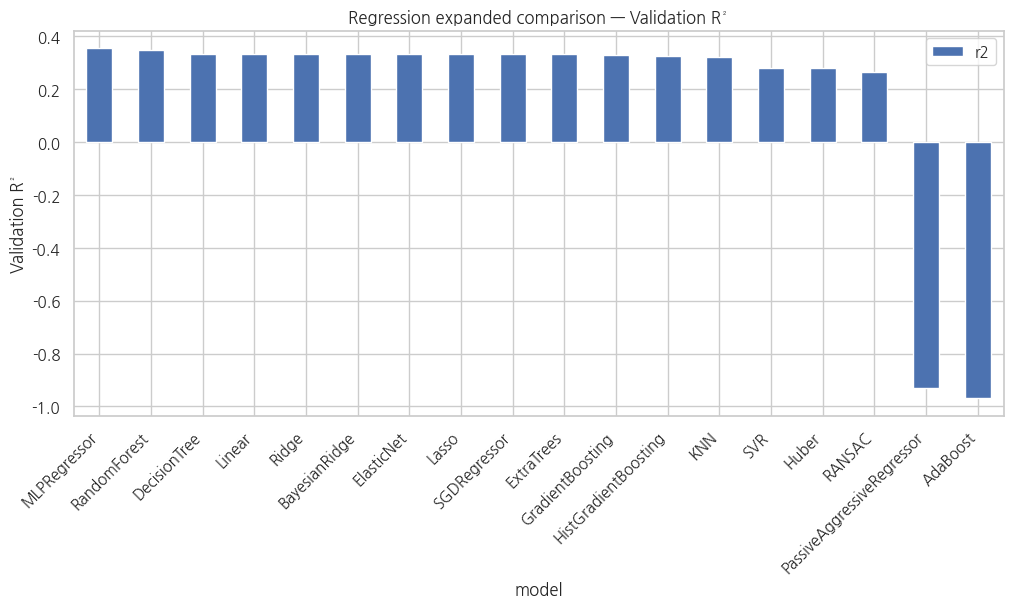

R² 최고: MLPRegressor (0.3556)
MAE 최저: MLPRegressor (0.4917)
RMSE 최저: MLPRegressor (0.7347)


In [48]:
# ============================================================
# Regression 추가 모델 확장 검증
# ============================================================
# reg_extra_models: 기존 목록에 없던 회귀 알고리즘의 보조 비교 목록

from sklearn.linear_model import (
    BayesianRidge,
    HuberRegressor,
    SGDRegressor,
    PassiveAggressiveRegressor,
    RANSACRegressor,
)
from sklearn.neural_network import MLPRegressor

reg_extra_models = {
    "BayesianRidge": BayesianRidge(),
    "Huber": HuberRegressor(),
    "SGDRegressor": SGDRegressor(
        random_state=RANDOM_STATE
    ),
    "PassiveAggressiveRegressor": PassiveAggressiveRegressor(
        random_state=RANDOM_STATE
    ),
    "MLPRegressor": MLPRegressor(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    "RANSAC": RANSACRegressor(
        random_state=RANDOM_STATE
    ),
}

# reg_extra_rows: 추가 회귀모델별 Validation 성능 저장
reg_extra_rows = []

for name, model in reg_extra_models.items():
    model.fit(Xtr_rs, ytr_r)
    pred = model.predict(Xva_rs)

    reg_extra_rows.append({
        "model": name,
        "mae": mean_absolute_error(yva_r, pred),
        "rmse": mean_squared_error(yva_r, pred) ** 0.5,
        "r2": r2_score(yva_r, pred),
    })

# reg_extra_result_df: 추가된 회귀모델들의 Validation 비교표
reg_extra_result_df = pd.DataFrame(reg_extra_rows)

# reg_all_validation_compare: 기존 회귀모델 + 추가 회귀모델 통합 비교
reg_all_validation_compare = pd.concat(
    [
        reg_result_df[["model","mae","rmse","r2"]],
        reg_extra_result_df[["model","mae","rmse","r2"]],
    ],
    ignore_index=True
).drop_duplicates("model", keep="first")

display(
    reg_all_validation_compare
    .sort_values("r2", ascending=False)
)

reg_all_validation_compare.set_index("model")[
    ["r2"]
].sort_values("r2", ascending=False).plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Validation R²")
plt.title("Regression expanded comparison — Validation R²")
plt.xticks(rotation=45, ha="right")
plt.show()

# 각 평가기준별 최고 모델을 따로 출력
best_r2 = reg_all_validation_compare.loc[
    reg_all_validation_compare["r2"].idxmax()
]
best_mae = reg_all_validation_compare.loc[
    reg_all_validation_compare["mae"].idxmin()
]
best_rmse = reg_all_validation_compare.loc[
    reg_all_validation_compare["rmse"].idxmin()
]

print(f"R² 최고: {best_r2['model']} ({best_r2['r2']:.4f})")
print(f"MAE 최저: {best_mae['model']} ({best_mae['mae']:.4f})")
print(f"RMSE 최저: {best_rmse['model']} ({best_rmse['rmse']:.4f})")

## [H5 추가 Regression] MLPRegressor Validation 우위는 새 최종모델 승리가 아님

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


### 추가 Regression 그래프 해석 방법

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


#[신규 확장 PART] 산업 Sector별 모델링 — 기존 Global 모델을 응용

> **이 파트는 기존 15번 Industry K-Means와 별도입니다.**

| 구분 | 기존 Industry K-Means | 신규 Sector별 ML |
|---|---|---|
| 목적 | 같은 Sector 안에서 상대적으로 Stable/Middle/Risky 구분 | 기존 Global 미래위험 모델이 Sector별로 다르게 작동하는지 검증 |
| 입력 | `Volatility_120d`, `|Beta_120d|` | 동일 |
| 방식 | 비지도 K-Means | 기존 Global Classification/Regression 구조를 Sector별 Train에 재적합 |
| 새 모델 탐색 | 없음 | **없음 — Global에서 확정된 구조/파라미터 고정** |
| 미매핑 값 | 내부 진단용으로만 보존 | Sector ML 및 발표 출력에서는 제외 |

### 실행 전 사전 규칙
- 공식 평가격자: **기존 120일**
- Primary metric: **Recall**
- Recall 목표 정밀도: **±15%p**
- worst-case 기준 필요한 actual Risky 수는 약 **43개**를 계획 기준으로 사용
- Confirmatory Sector가 **최소 2개 이상**이어야 Sector-wide 비교를 정식 진행
- 0개: 공식 Sector ML 결론 불가
- 1개: exploratory case note만 유지
- 2개 이상: Global vs Sector-refit 정식 paired 비교
- Sector별 grid search **금지**
- 60일 robustness는 120일에서 Confirmatory Sector가 2개 미만일 때만 실행
- 60일에서도 기준을 완화하지 않음


In [49]:
# ============================================================
# [추가 PART H-1] 공통 함수 / 사전 표본충분성 기준
# ============================================================
RECALL_MARGIN_TARGET = 0.15
Z_95 = 1.96
MIN_RISKY_FOR_CONFIRMATORY = math.ceil(0.25 * (Z_95 / RECALL_MARGIN_TARGET) ** 2)
MIN_CONFIRMATORY_SECTORS = 2

print("Recall 목표 오차(95%): ±", RECALL_MARGIN_TARGET)
print("worst-case p=0.5 계획상 필요한 actual Risky 수:", MIN_RISKY_FOR_CONFIRMATORY)
print("Sector-wide 정식 비교에 필요한 Confirmatory Sector 수:", MIN_CONFIRMATORY_SECTORS)

def wilson_ci(successes, n, z=1.96):
    if n <= 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = z * np.sqrt((p*(1-p)/n) + (z*z/(4*n*n))) / denom
    return center - half, center + half

def safe_pr_auc(y_true, score):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, score)

def model_score(model, X):
    pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        raw = model.decision_function(X)
        score = (raw - np.nanmin(raw)) / (np.nanmax(raw) - np.nanmin(raw) + 1e-12)
    else:
        score = pred.astype(float)
    return pred, score

# Sector ML은 보완 인터페이스가 연결되면 final mapping을, 아니면 baseline을 사용합니다.
sector_lookup_for_model = (
    sector_panel[["Date", "Ticker", "Sector"]]
    .drop_duplicates(["Date", "Ticker"])
)

Recall 목표 오차(95%): ± 0.15
worst-case p=0.5 계획상 필요한 actual Risky 수: 43
Sector-wide 정식 비교에 필요한 Confirmatory Sector 수: 2


## [H5 Sector ML 표본기준] actual_risky_n≥43은 프로젝트용 계획기준

43개 기준은 95% 수준에서 recall의 최악조건 p=0.5를 가정하고 ±0.15 정도의 오차폭을 목표로 한 **사전 표본계획 heuristic**입니다. 43개 이상이면 무조건 충분하다는 보편 법칙이 아닙니다. 특히 Test 날짜가 2개뿐이면 종목 수만 충족해도 시간적 일반화가 확보되는 것은 아닙니다.

Wilson interval 참고: Brown, Cai & DasGupta (2001) https://doi.org/10.1214/ss/1009213286


## [신규 / Step 0] 재학습 없이 Global Test 예측을 Sector별로 먼저 보기

기존 최종 Global Classification의 2025 Test 예측값을 그대로 두고 Sector만 붙입니다. 여기서 차이가 거의 없으면 Sector별 재학습을 과대해석하지 않습니다.


,Sector,rows,unique_dates,actual_risky_n,global_recall,recall_ci_low,recall_ci_high,recall_ci_half_width,global_f1,global_pr_auc,status
7,Information Technology,131,2,79,0.8987,0.8127,0.9478,0.0675,0.7978,0.8775,CONFIRMATORY
1,Consumer Discretionary,90,2,41,0.9024,0.7745,0.9614,0.0934,0.7327,0.7160,EXPLORATORY
5,Health Care,116,2,41,0.6341,0.4812,0.7641,0.1414,0.5591,0.5273,EXPLORATORY
6,Industrials,152,2,32,0.7500,0.5789,0.8675,0.1443,0.4706,0.5093,EXPLORATORY
4,Financials,143,2,26,0.8077,0.6212,0.9149,0.1468,0.5250,0.5469,EXPLORATORY
8,Materials,50,2,15,0.8000,0.5481,0.9295,0.1907,0.6316,0.6355,EXPLORATORY
2,Consumer Staples,66,2,12,0.3333,0.1381,0.6094,0.2356,0.3333,0.3913,EXPLORATORY
3,Energy,41,2,11,0.5455,0.2801,0.7873,0.2536,0.3333,0.3376,EXPLORATORY
0,Communication Services,40,2,9,0.7778,0.4526,0.9368,0.2421,0.5000,0.5772,EXPLORATORY
10,Utilities,62,2,7,1.0000,0.6457,1.0000,0.1772,0.7368,0.9405,EXPLORATORY


Confirmatory Sector 수: 1 ['Information Technology']


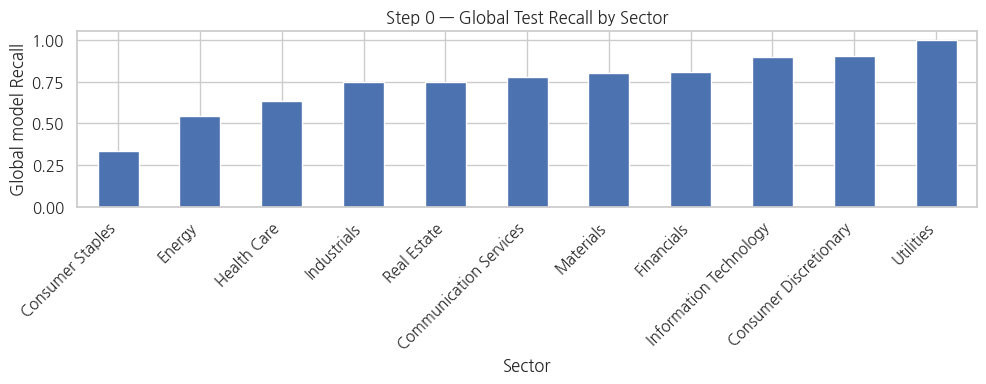

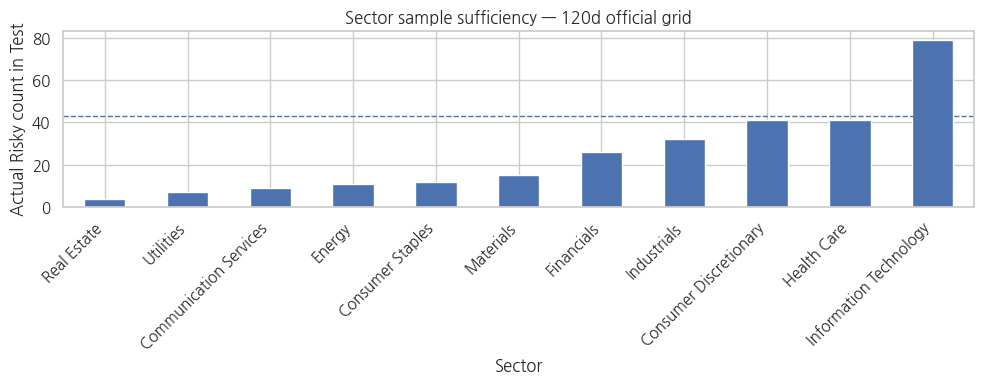

,Sector,Date,rows,actual_risky_n,global_recall
0,Communication Services,2025-01-28,19,2,0.0000
1,Communication Services,2025-07-22,21,7,1.0000
2,Consumer Discretionary,2025-01-28,44,21,0.8571
3,Consumer Discretionary,2025-07-22,46,20,0.9500
4,Consumer Staples,2025-01-28,33,4,0.5000
5,Consumer Staples,2025-07-22,33,8,0.2500
6,Energy,2025-01-28,20,9,0.4444
7,Energy,2025-07-22,21,2,1.0000
8,Financials,2025-01-28,71,14,0.8571
9,Financials,2025-07-22,72,12,0.7500


In [50]:
# Global 120d Test 예측 + Sector 결합
global_test_cls = test[["Date", "Ticker", CLS_TARGET] + CLS_FEATURES].copy()
global_test_cls["global_pred"] = np.asarray(test_pred)
global_test_cls["global_score"] = np.asarray(test_score)
global_test_cls = global_test_cls.merge(
    sector_lookup_for_model, on=["Date", "Ticker"], how="left", validate="one_to_one"
)
global_test_cls = global_test_cls.dropna(subset=["Sector"]).copy()
global_test_cls = global_test_cls[global_test_cls["Sector"].astype(str).str.upper().ne("UNKNOWN")].copy()

step0_rows = []
for sector, g in global_test_cls.groupby("Sector"):
    y = g[CLS_TARGET].astype(int).to_numpy()
    p = g["global_pred"].astype(int).to_numpy()
    s = g["global_score"].to_numpy()
    pos_n = int(y.sum())
    tp = int(((y == 1) & (p == 1)).sum())
    lo, hi = wilson_ci(tp, pos_n)
    step0_rows.append({
        "Sector": sector,
        "rows": len(g),
        "unique_dates": g["Date"].nunique(),
        "actual_risky_n": pos_n,
        "global_recall": recall_score(y, p, zero_division=0),
        "recall_ci_low": lo,
        "recall_ci_high": hi,
        "recall_ci_half_width": (hi - lo) / 2 if pos_n > 0 else np.nan,
        "global_f1": f1_score(y, p, zero_division=0),
        "global_pr_auc": safe_pr_auc(y, s),
        "status": "CONFIRMATORY" if pos_n >= MIN_RISKY_FOR_CONFIRMATORY else "EXPLORATORY",
    })

sector_step0 = pd.DataFrame(step0_rows).sort_values(["status", "actual_risky_n"], ascending=[True, False])
display(sector_step0)

confirmatory_sectors = sector_step0.loc[sector_step0["status"].eq("CONFIRMATORY"), "Sector"].tolist()
print("Confirmatory Sector 수:", len(confirmatory_sectors), confirmatory_sectors)

plt.figure(figsize=(10,4))
sector_step0.sort_values("global_recall").set_index("Sector")["global_recall"].plot(kind="bar")
plt.ylabel("Global model Recall")
plt.title("Step 0 — Global Test Recall by Sector")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sector_step0.sort_values("actual_risky_n").set_index("Sector")["actual_risky_n"].plot(kind="bar")
plt.axhline(MIN_RISKY_FOR_CONFIRMATORY, linestyle="--", linewidth=1)
plt.ylabel("Actual Risky count in Test")
plt.title("Sector sample sufficiency — 120d official grid")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Test가 두 날짜뿐인 점을 숨기지 않고 날짜별 Recall도 출력
step0_by_date = []
for (sector, dt), g in global_test_cls.groupby(["Sector", "Date"]):
    y = g[CLS_TARGET].astype(int)
    p = g["global_pred"].astype(int)
    step0_by_date.append({
        "Sector": sector, "Date": dt, "rows": len(g),
        "actual_risky_n": int(y.sum()),
        "global_recall": recall_score(y, p, zero_division=0) if y.sum() > 0 else np.nan,
    })
sector_step0_by_date = pd.DataFrame(step0_by_date)
display(sector_step0_by_date.sort_values(["Sector", "Date"]))


## [H5 Sector Step 0] 120d 공식 Test에서 정식 표본기준을 충족한 Sector는 1개뿐

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## [신규] Sector별 Classification 재적합 — Global 모델 구조 고정

**새 모델을 고르지 않습니다.** `final_clf_name`과 `final_clf_params`를 그대로 사용하고 전체시장 최종 Test와 공정하게 비교하기 위해 **Global final model과 동일하게 Train+Validation(≤2024) 구간으로 최종 fit**합니다. 단, Sector별 Validation 성능으로 모델/파라미터를 다시 고르지는 않습니다.

- 모든 Sector 결과는 표시하되 `CONFIRMATORY / EXPLORATORY`를 분리합니다.
- 1개 Confirmatory Sector만 존재하면 단일 사례 관찰로만 남깁니다.
- 2개 이상일 때만 Sector-wide 비교를 정식으로 해석합니다.
> **공정 비교 주의:** Global 최종 Test 모델이 Train+Validation으로 재학습되므로 Sector-refit도 동일하게 ≤2024 데이터를 최종 fit에 사용합니다. 2024를 Sector별 모델 선택에 사용하지는 않습니다.


,Sector,status,train_rows,test_rows,test_dates,actual_risky_n,global_recall,sector_refit_recall,delta_recall,global_f1,sector_refit_f1,global_pr_auc,sector_refit_pr_auc,global_only_correct_risky_b,sector_only_correct_risky_c,discordant_pairs,paired_exact_p
7,Information Technology,CONFIRMATORY,871,131,2,79,0.8987,0.7722,-0.1266,0.7978,0.7821,0.8775,0.8274,10,0,10,0.0020
2,Consumer Staples,EXPLORATORY,555,66,2,12,0.3333,0.5000,0.1667,0.3333,0.3529,0.3913,0.2787,3,5,8,0.7266
3,Energy,EXPLORATORY,307,41,2,11,0.5455,0.6364,0.0909,0.3333,0.4242,0.3376,0.3750,0,1,1,1.0000
6,Industrials,EXPLORATORY,1126,152,2,32,0.7500,0.8125,0.0625,0.4706,0.4771,0.5093,0.3641,1,3,4,0.6250
4,Financials,EXPLORATORY,1134,143,2,26,0.8077,0.8077,0.0000,0.5250,0.4200,0.5469,0.4078,1,1,2,1.0000
5,Health Care,EXPLORATORY,912,116,2,41,0.6341,0.6341,0.0000,0.5591,0.5253,0.5273,0.4578,7,7,14,1.0000
0,Communication Services,EXPLORATORY,295,40,2,9,0.7778,0.6667,-0.1111,0.5000,0.4800,0.5772,0.5649,3,2,5,1.0000
8,Materials,EXPLORATORY,384,50,2,15,0.8000,0.6667,-0.1333,0.6316,0.6452,0.6355,0.6243,2,0,2,0.5000
1,Consumer Discretionary,EXPLORATORY,701,90,2,41,0.9024,0.7561,-0.1463,0.7327,0.7209,0.7160,0.7211,9,3,12,0.1460
10,Utilities,EXPLORATORY,508,62,2,7,1.0000,0.2857,-0.7143,0.7368,0.1818,0.9405,0.2949,5,0,5,0.0625


,Sector,Date,actual_risky_n,global_recall,sector_refit_recall,delta_recall
0,Communication Services,2025-01-28,2,0.0000,1.0000,1.0000
1,Communication Services,2025-07-22,7,1.0000,0.5714,-0.4286
2,Consumer Discretionary,2025-01-28,21,0.8571,0.8095,-0.0476
3,Consumer Discretionary,2025-07-22,20,0.9500,0.7000,-0.2500
4,Consumer Staples,2025-01-28,4,0.5000,0.5000,0.0000
5,Consumer Staples,2025-07-22,8,0.2500,0.5000,0.2500
6,Energy,2025-01-28,9,0.4444,0.5556,0.1111
7,Energy,2025-07-22,2,1.0000,1.0000,0.0000
8,Financials,2025-01-28,14,0.8571,0.9286,0.0714
9,Financials,2025-07-22,12,0.7500,0.6667,-0.0833


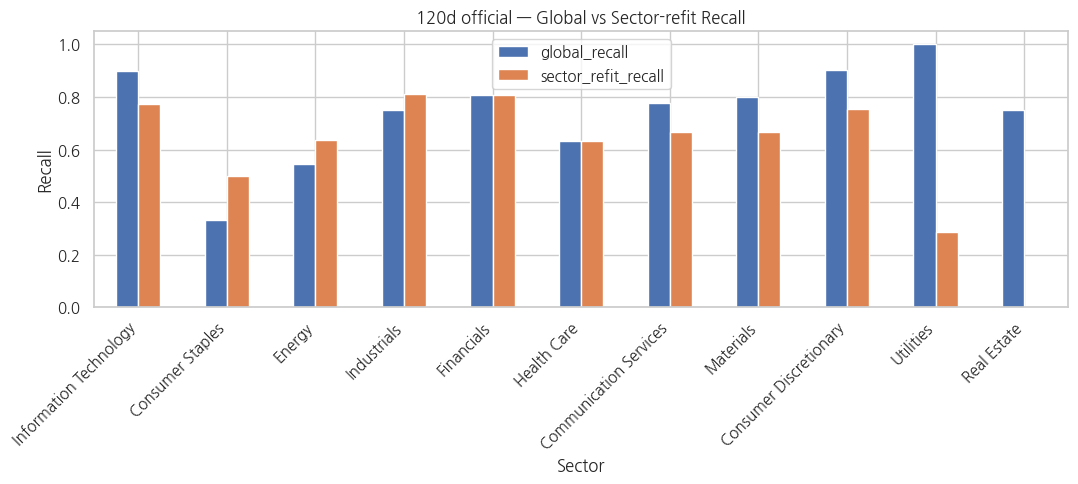

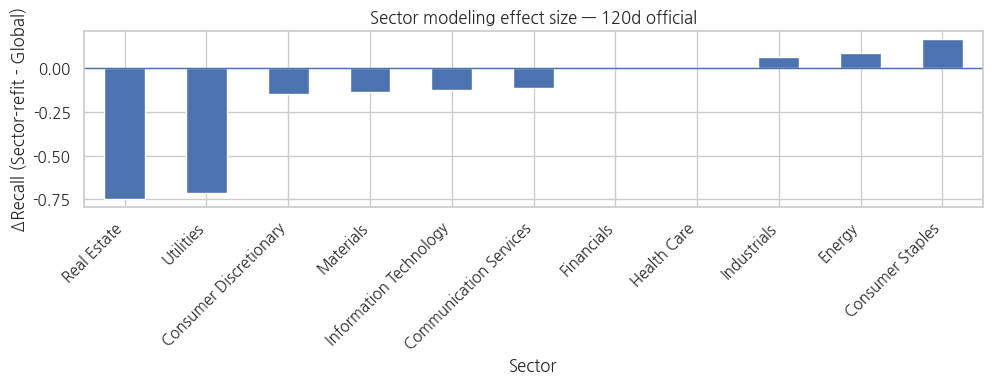

정식 해석 가능한 Confirmatory Sector 수: 1
→ 1개 Sector만 충족: exploratory case note로만 남기고 Sector-wide 결론은 내리지 않습니다.


In [51]:
# ============================================================
# [추가 PART H-3] 120d Sector-refit Classification
# ============================================================
sector_train_cls = train_valid_cls[["Date", "Ticker", CLS_TARGET] + CLS_FEATURES].merge(
    sector_lookup_for_model, on=["Date", "Ticker"], how="left", validate="one_to_one"
)
sector_test_cls = global_test_cls.copy()

sector_refit_rows = []
sector_date_rows = []

for sector, gtest in sector_test_cls.groupby("Sector"):
    gtrain = sector_train_cls[sector_train_cls["Sector"].eq(sector)].dropna(subset=CLS_FEATURES + [CLS_TARGET]).copy()
    if len(gtrain) == 0 or gtrain[CLS_TARGET].nunique() < 2:
        continue

    Xtr_sec = gtrain[CLS_FEATURES]
    ytr_sec = gtrain[CLS_TARGET].astype(int)
    Xte_sec = gtest[CLS_FEATURES]
    yte_sec = gtest[CLS_TARGET].astype(int).to_numpy()

    sec_scaler = StandardScaler().fit(Xtr_sec)
    sec_model = build_clf(final_clf_name, final_clf_params)
    sec_model.fit(sec_scaler.transform(Xtr_sec), ytr_sec)
    sec_pred, sec_score = model_score(sec_model, sec_scaler.transform(Xte_sec))

    global_pred_sec = gtest["global_pred"].astype(int).to_numpy()
    global_score_sec = gtest["global_score"].to_numpy()

    risky_mask = yte_sec == 1
    global_correct_risky = global_pred_sec[risky_mask] == 1
    sector_correct_risky = sec_pred[risky_mask] == 1
    b = int((global_correct_risky & ~sector_correct_risky).sum())  # Global only correct
    c = int((~global_correct_risky & sector_correct_risky).sum())  # Sector only correct
    discordant = b + c
    paired_p = binomtest(b, n=discordant, p=0.5, alternative="two-sided").pvalue if discordant > 0 else np.nan

    global_recall = recall_score(yte_sec, global_pred_sec, zero_division=0)
    sector_recall = recall_score(yte_sec, sec_pred, zero_division=0)
    pos_n = int(yte_sec.sum())

    sector_refit_rows.append({
        "Sector": sector,
        "status": "CONFIRMATORY" if pos_n >= MIN_RISKY_FOR_CONFIRMATORY else "EXPLORATORY",
        "train_rows": len(gtrain),
        "test_rows": len(gtest),
        "test_dates": gtest["Date"].nunique(),
        "actual_risky_n": pos_n,
        "global_recall": global_recall,
        "sector_refit_recall": sector_recall,
        "delta_recall": sector_recall - global_recall,
        "global_f1": f1_score(yte_sec, global_pred_sec, zero_division=0),
        "sector_refit_f1": f1_score(yte_sec, sec_pred, zero_division=0),
        "global_pr_auc": safe_pr_auc(yte_sec, global_score_sec),
        "sector_refit_pr_auc": safe_pr_auc(yte_sec, sec_score),
        "global_only_correct_risky_b": b,
        "sector_only_correct_risky_c": c,
        "discordant_pairs": discordant,
        "paired_exact_p": paired_p,
    })

    date_temp = gtest[["Date", CLS_TARGET, "global_pred"]].copy()
    date_temp["sector_pred"] = sec_pred
    for dt, gd in date_temp.groupby("Date"):
        y = gd[CLS_TARGET].astype(int)
        if y.sum() == 0:
            continue
        gr = recall_score(y, gd["global_pred"].astype(int), zero_division=0)
        sr = recall_score(y, gd["sector_pred"].astype(int), zero_division=0)
        sector_date_rows.append({
            "Sector": sector, "Date": dt, "actual_risky_n": int(y.sum()),
            "global_recall": gr, "sector_refit_recall": sr, "delta_recall": sr - gr,
        })

sector_refit_cls = pd.DataFrame(sector_refit_rows).sort_values(["status", "delta_recall"], ascending=[True, False])
sector_refit_by_date = pd.DataFrame(sector_date_rows)
display(sector_refit_cls)
display(sector_refit_by_date.sort_values(["Sector", "Date"]))

if len(sector_refit_cls):
    plot_cmp = sector_refit_cls.set_index("Sector")[["global_recall", "sector_refit_recall"]]
    plot_cmp.plot(kind="bar", figsize=(11,5))
    plt.ylabel("Recall")
    plt.title("120d official — Global vs Sector-refit Recall")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    sector_refit_cls.sort_values("delta_recall").set_index("Sector")["delta_recall"].plot(kind="bar")
    plt.axhline(0, linewidth=1)
    plt.ylabel("ΔRecall (Sector-refit - Global)")
    plt.title("Sector modeling effect size — 120d official")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

confirmatory_refit = sector_refit_cls[sector_refit_cls["status"].eq("CONFIRMATORY")].copy()
print("정식 해석 가능한 Confirmatory Sector 수:", len(confirmatory_refit))
if len(confirmatory_refit) == 0:
    print("→ 공식 120d 기준으로 Sector ML 결론을 확정할 수 없습니다.")
elif len(confirmatory_refit) == 1:
    print("→ 1개 Sector만 충족: exploratory case note로만 남기고 Sector-wide 결론은 내리지 않습니다.")
else:
    print("→ 2개 이상 충족: ΔRecall 방향/guardrail/paired counts를 함께 비교할 수 있습니다.")

## [H5 Sector-refit Classification] 공식 120d 결과는 Sector-wide 개선을 지지하지 않음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


##[신규] Sector별 Regression — Classification의 consistency check

Regression은 `future_risk_score`를 사용하므로 Classification의 `future_risky_30`과 완전히 독립적인 증거가 아닙니다. 따라서 Sector별 R²/MAE/RMSE는 **같은 방향인지 확인하는 보조 consistency check**로만 사용합니다.


,Sector,test_rows,global_r2,sector_refit_r2,delta_r2,global_mae,sector_refit_mae,global_rmse,sector_refit_rmse
6,Industrials,152,0.1417,0.1495,0.0078,0.5067,0.4888,0.6766,0.6735
4,Financials,143,0.0859,0.0811,-0.0048,0.5648,0.5430,0.7600,0.7620
8,Materials,50,0.3711,0.3613,-0.0098,0.5100,0.4879,0.6391,0.6440
10,Utilities,62,0.5274,0.4952,-0.0322,0.5476,0.5071,0.6052,0.6255
9,Real Estate,60,0.1090,0.0679,-0.0410,0.4285,0.4243,0.5833,0.5965
5,Health Care,116,0.1895,0.1410,-0.0485,0.6061,0.6300,0.8172,0.8413
1,Consumer Discretionary,90,0.3428,0.2937,-0.0491,0.5830,0.5947,0.7301,0.7569
0,Communication Services,40,0.4482,0.3748,-0.0734,0.5254,0.5330,0.7287,0.7756
7,Information Technology,131,0.3886,0.2534,-0.1352,0.5605,0.5990,0.7560,0.8354
2,Consumer Staples,66,0.1906,0.0118,-0.1787,0.4666,0.4998,0.6061,0.6697


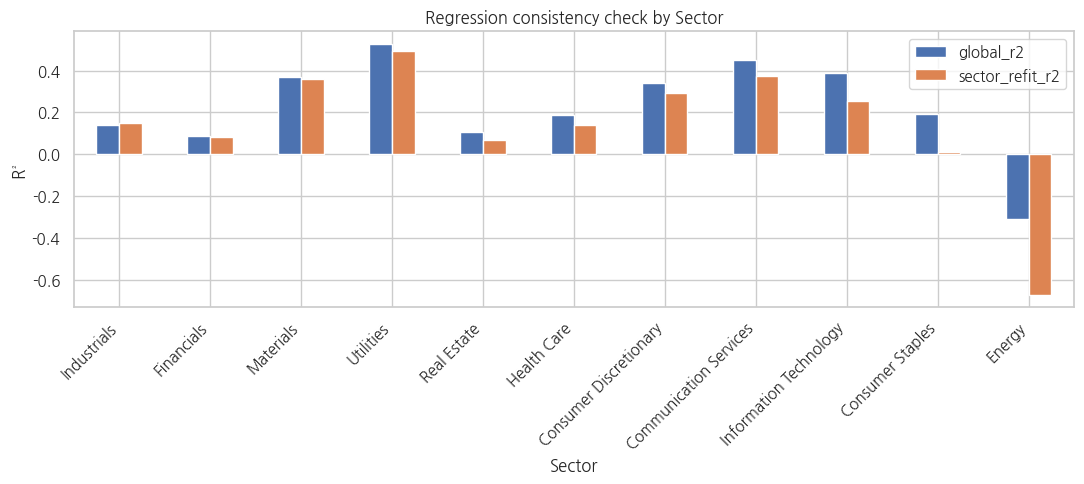

In [52]:
# ============================================================
# [추가 PART H-4] Sector-refit Regression — 기존 final_reg 구조 고정
# ============================================================
global_test_reg = test_r[["Date", "Ticker", REG_TARGET] + REG_FEATURES].copy()
global_test_reg["global_reg_pred"] = np.asarray(reg_test_pred)
global_test_reg = global_test_reg.merge(
    sector_lookup_for_model, on=["Date", "Ticker"], how="left", validate="one_to_one"
).dropna(subset=["Sector"])
global_test_reg = global_test_reg[global_test_reg["Sector"].astype(str).str.upper().ne("UNKNOWN")].copy()

sector_train_reg = train_valid_reg[["Date", "Ticker", REG_TARGET] + REG_FEATURES].merge(
    sector_lookup_for_model, on=["Date", "Ticker"], how="left", validate="one_to_one"
)

reg_sector_rows = []
for sector, gtest in global_test_reg.groupby("Sector"):
    gtrain = sector_train_reg[sector_train_reg["Sector"].eq(sector)].dropna(subset=REG_FEATURES + [REG_TARGET]).copy()
    if len(gtrain) == 0:
        continue
    Xtr_sec = gtrain[REG_FEATURES]
    ytr_sec = gtrain[REG_TARGET].astype(float)
    Xte_sec = gtest[REG_FEATURES]
    yte_sec = gtest[REG_TARGET].astype(float)

    sec_scaler = StandardScaler().fit(Xtr_sec)
    sec_reg = clone(final_reg)
    sec_reg.fit(sec_scaler.transform(Xtr_sec), ytr_sec)
    sec_pred = sec_reg.predict(sec_scaler.transform(Xte_sec))
    glob_pred = gtest["global_reg_pred"].to_numpy()

    # R²는 같은 날짜 내 상대위험 설명력이라는 기존 해석을 유지
    reg_sector_rows.append({
        "Sector": sector,
        "test_rows": len(gtest),
        "global_r2": r2_score(yte_sec, glob_pred) if len(gtest) >= 2 else np.nan,
        "sector_refit_r2": r2_score(yte_sec, sec_pred) if len(gtest) >= 2 else np.nan,
        "delta_r2": (r2_score(yte_sec, sec_pred) - r2_score(yte_sec, glob_pred)) if len(gtest) >= 2 else np.nan,
        "global_mae": mean_absolute_error(yte_sec, glob_pred),
        "sector_refit_mae": mean_absolute_error(yte_sec, sec_pred),
        "global_rmse": mean_squared_error(yte_sec, glob_pred) ** 0.5,
        "sector_refit_rmse": mean_squared_error(yte_sec, sec_pred) ** 0.5,
    })

sector_refit_reg = pd.DataFrame(reg_sector_rows).sort_values("delta_r2", ascending=False)
display(sector_refit_reg)

if len(sector_refit_reg):
    sector_refit_reg.set_index("Sector")[["global_r2", "sector_refit_r2"]].plot(kind="bar", figsize=(11,5))
    plt.ylabel("R²")
    plt.title("Regression consistency check by Sector")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## [H5 Sector-refit Regression] 대부분 Sector에서 Global R²가 더 높거나 차이가 작음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


###  산업 Sector별 모델링 종합 비교

앞의 Classification / Regression 결과를 Sector 단위로 통합하여,
각 산업에서 Global 모델과 Sector-refit 모델이 어떻게 달라졌는지 한눈에 비교합니다.

이 표의 목적은 “어느 산업이 가장 좋다”를 선정하는 것이 아니라,

1. Global 모델이 그대로 잘 작동하는 산업
2. Sector별 재학습에서 개선 가능성이 보이는 산업
3. Sector별 재학습에서 오히려 성능이 악화된 산업

을 구분하는 것입니다.

- Classification Primary: Recall
- Guardrail: F1, PR-AUC
- Regression: R² consistency check
- Confirmatory / Exploratory 상태를 함께 표시


In [53]:
# ============================================================
# [추가] Sector별 모델링 종합 비교표
#
# 목적:
# - 기존 Global Classification / Regression 결과와
#   Sector별 재학습 결과를 하나의 Sector 단위 표로 통합
# - 산업별 모델링 결과를 한눈에 확인
#
# 주의:
# - Sector별 모델을 새로 탐색한 것이 아님
# - Global에서 확정한 모델 구조/파라미터를 그대로 사용
# - Sector별 Train 데이터에 fit만 다시 수행
# ============================================================

# ------------------------------------------------------------
# 1. Classification 결과 정리
# ------------------------------------------------------------
sector_cls_summary = sector_refit_cls[
    [
        "Sector",
        "status",
        "actual_risky_n",
        "global_recall",
        "sector_refit_recall",
        "delta_recall",
        "global_f1",
        "sector_refit_f1",
        "global_pr_auc",
        "sector_refit_pr_auc",
        "discordant_pairs",
        "paired_exact_p",
    ]
].copy()


# ------------------------------------------------------------
# 2. Regression 결과 정리
# ------------------------------------------------------------
sector_reg_summary = sector_refit_reg[
    [
        "Sector",
        "global_r2",
        "sector_refit_r2",
        "delta_r2",
        "global_mae",
        "sector_refit_mae",
        "global_rmse",
        "sector_refit_rmse",
    ]
].copy()


# ------------------------------------------------------------
# 3. Classification + Regression 통합
# ------------------------------------------------------------
sector_model_summary = sector_cls_summary.merge(
    sector_reg_summary,
    on="Sector",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 4. 해석용 판정 컬럼 생성
#
# 임의 점수나 가중치를 만들지 않고,
# Primary인 ΔRecall 방향을 기준으로 단순 분류합니다.
# Regression은 판정을 뒤집는 기준이 아니라 consistency check입니다.
# ------------------------------------------------------------
def classify_sector_model(row):

    delta = row["delta_recall"]

    if pd.isna(delta):
        return "판정 불가"

    if delta > 0:
        return "Sector-refit Recall 개선"

    elif delta < 0:
        return "Global Recall 우세"

    else:
        return "Recall 차이 없음"


sector_model_summary["classification_result"] = (
    sector_model_summary.apply(classify_sector_model, axis=1)
)


# ------------------------------------------------------------
# 5. Regression 방향도 별도 표시
# ------------------------------------------------------------
def classify_regression(row):

    delta = row["delta_r2"]

    if pd.isna(delta):
        return "Regression 판정 불가"

    if delta > 0:
        return "Sector-refit R² 개선"

    elif delta < 0:
        return "Global R² 우세"

    else:
        return "R² 차이 없음"


sector_model_summary["regression_result"] = (
    sector_model_summary.apply(classify_regression, axis=1)
)


# ------------------------------------------------------------
# 6. 발표용 최종 해석 컬럼
#
# Confirmatory인지 Exploratory인지 먼저 표시하고,
# Classification 방향 + Regression consistency를 같이 보여줍니다.
# ------------------------------------------------------------
def build_sector_conclusion(row):

    prefix = (
        "Confirmatory"
        if row["status"] == "CONFIRMATORY"
        else "Exploratory"
    )

    cls_delta = row["delta_recall"]
    reg_delta = row["delta_r2"]

    if pd.isna(cls_delta):
        return f"{prefix} | Classification 판정 불가"

    if cls_delta > 0:
        if pd.notna(reg_delta) and reg_delta > 0:
            return f"{prefix} | Sector-refit 개선 신호 (Cls+Reg 동일 방향)"
        elif pd.notna(reg_delta) and reg_delta < 0:
            return f"{prefix} | Recall 개선 / Regression 불일치"
        else:
            return f"{prefix} | Recall 개선"

    elif cls_delta < 0:
        if pd.notna(reg_delta) and reg_delta < 0:
            return f"{prefix} | Global 우세 (Cls+Reg 동일 방향)"
        elif pd.notna(reg_delta) and reg_delta > 0:
            return f"{prefix} | Recall 악화 / Regression 불일치"
        else:
            return f"{prefix} | Global Recall 우세"

    else:
        if pd.notna(reg_delta) and reg_delta > 0:
            return f"{prefix} | Recall 동일 / Regression 개선"
        elif pd.notna(reg_delta) and reg_delta < 0:
            return f"{prefix} | Recall 동일 / Regression 악화"
        else:
            return f"{prefix} | 차이 거의 없음"


sector_model_summary["final_interpretation"] = (
    sector_model_summary.apply(build_sector_conclusion, axis=1)
)


# ------------------------------------------------------------
# 7. 보기 좋은 순서로 정렬
# Confirmatory → Exploratory
# actual Risky가 많은 Sector부터
# ------------------------------------------------------------
sector_model_summary = (
    sector_model_summary
    .sort_values(
        ["status", "actual_risky_n"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. 발표용 핵심 컬럼
# ------------------------------------------------------------
sector_model_display = sector_model_summary[
    [
        "Sector",
        "status",
        "actual_risky_n",
        "global_recall",
        "sector_refit_recall",
        "delta_recall",
        "global_r2",
        "sector_refit_r2",
        "delta_r2",
        "final_interpretation",
    ]
].copy()


display(sector_model_display)

,Sector,status,actual_risky_n,global_recall,sector_refit_recall,delta_recall,global_r2,sector_refit_r2,delta_r2,final_interpretation
0,Information Technology,CONFIRMATORY,79,0.8987,0.7722,-0.1266,0.3886,0.2534,-0.1352,Confirmatory | Global 우세 (Cls+Reg 동일 방향)
1,Health Care,EXPLORATORY,41,0.6341,0.6341,0.0000,0.1895,0.1410,-0.0485,Exploratory | Recall 동일 / Regression 악화
2,Consumer Discretionary,EXPLORATORY,41,0.9024,0.7561,-0.1463,0.3428,0.2937,-0.0491,Exploratory | Global 우세 (Cls+Reg 동일 방향)
3,Industrials,EXPLORATORY,32,0.7500,0.8125,0.0625,0.1417,0.1495,0.0078,Exploratory | Sector-refit 개선 신호 (Cls+Reg 동일 방향)
4,Financials,EXPLORATORY,26,0.8077,0.8077,0.0000,0.0859,0.0811,-0.0048,Exploratory | Recall 동일 / Regression 악화
5,Materials,EXPLORATORY,15,0.8000,0.6667,-0.1333,0.3711,0.3613,-0.0098,Exploratory | Global 우세 (Cls+Reg 동일 방향)
6,Consumer Staples,EXPLORATORY,12,0.3333,0.5000,0.1667,0.1906,0.0118,-0.1787,Exploratory | Recall 개선 / Regression 불일치
7,Energy,EXPLORATORY,11,0.5455,0.6364,0.0909,-0.3067,-0.6700,-0.3633,Exploratory | Recall 개선 / Regression 불일치
8,Communication Services,EXPLORATORY,9,0.7778,0.6667,-0.1111,0.4482,0.3748,-0.0734,Exploratory | Global 우세 (Cls+Reg 동일 방향)
9,Utilities,EXPLORATORY,7,1.0000,0.2857,-0.7143,0.5274,0.4952,-0.0322,Exploratory | Global 우세 (Cls+Reg 동일 방향)


## [H5 120d 종합판정] Sector별 별도 ML 가설은 지지되지 않음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


##[신규 / 조건부] 60일 평가격자 Robustness

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


60d robustness 실행 여부: True
[60d robustness] 미래 120d outcome이 인접 평가일 사이 약 50% 중첩됩니다.


,Sector,rows,unique_dates,actual_risky_n,global_recall,recall_ci_low,recall_ci_high,status
7,Information Technology,263,4,167,0.8263,0.7617,0.8763,CONFIRMATORY
5,Health Care,232,4,82,0.6585,0.5509,0.7520,CONFIRMATORY
1,Consumer Discretionary,182,4,75,0.9067,0.8197,0.9541,CONFIRMATORY
6,Industrials,305,4,61,0.7869,0.6688,0.8710,CONFIRMATORY
4,Financials,289,4,52,0.7692,0.6387,0.8628,CONFIRMATORY
8,Materials,100,4,33,0.8788,0.7267,0.9518,EXPLORATORY
2,Consumer Staples,132,4,28,0.3929,0.2357,0.5759,EXPLORATORY
3,Energy,83,4,17,0.7059,0.4687,0.8672,EXPLORATORY
0,Communication Services,82,4,16,0.6875,0.4440,0.8584,EXPLORATORY
10,Utilities,124,4,16,0.9375,0.7167,0.9889,EXPLORATORY


,Sector,status,actual_risky_n,global_recall,sector_refit_recall,delta_recall,discordant_pairs,paired_exact_p
9,Real Estate,EXPLORATORY,8,0.5000,0.7500,0.2500,2,0.5000
5,Health Care,CONFIRMATORY,82,0.6585,0.7439,0.0854,31,0.2810
2,Consumer Staples,EXPLORATORY,28,0.3929,0.4643,0.0714,2,0.5000
8,Materials,EXPLORATORY,33,0.8788,0.8788,0.0000,0,NaN
6,Industrials,CONFIRMATORY,61,0.7869,0.7541,-0.0328,4,0.6250
1,Consumer Discretionary,CONFIRMATORY,75,0.9067,0.8667,-0.0400,9,0.5078
10,Utilities,EXPLORATORY,16,0.9375,0.8750,-0.0625,1,1.0000
4,Financials,CONFIRMATORY,52,0.7692,0.6923,-0.0769,6,0.2188
0,Communication Services,EXPLORATORY,16,0.6875,0.5625,-0.1250,6,0.6875
7,Information Technology,CONFIRMATORY,167,0.8263,0.6407,-0.1856,33,0.0000


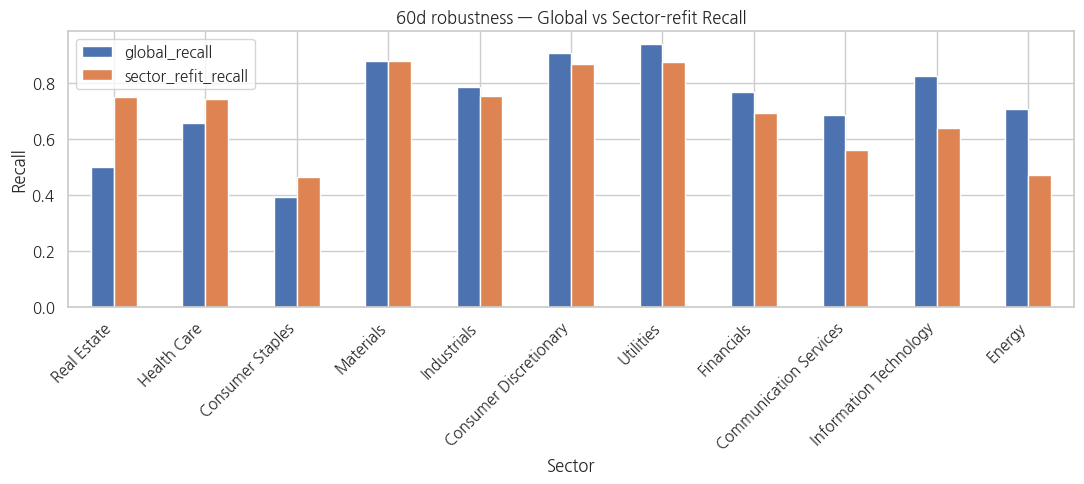

In [54]:
# ============================================================
# [추가 PART H-5] 60d robustness — Confirmatory Sector 부족 시에만
# ============================================================
RUN_60D_ROBUSTNESS = len(confirmatory_refit) < MIN_CONFIRMATORY_SECTORS
print("60d robustness 실행 여부:", RUN_60D_ROBUSTNESS)

sector_60_step0 = pd.DataFrame()
sector_60_refit = pd.DataFrame()

if RUN_60D_ROBUSTNESS:
    rb60 = rebalance_60df.copy()
    rb60["Date"] = pd.to_datetime(rb60["Date"])
    rb60["Ticker"] = normalize_ticker(rb60["Ticker"])
    rb60["abs_beta"] = rb60["beta_120d"].abs()

    robust60 = rb60[["Date", "Ticker", "volatility_120d", "abs_beta"]].merge(
        forward_daily[["Date", "Ticker", "future_vol_120d", "future_mdd_120d"]],
        on=["Date", "Ticker"], how="left", validate="one_to_one"
    ).dropna(subset=["volatility_120d", "abs_beta", "future_vol_120d", "future_mdd_120d"]).copy()

    robust60["z_future_vol"] = within_date_z(robust60, "future_vol_120d")
    robust60["z_future_drawdown"] = within_date_z(robust60, "future_mdd_120d")
    robust60["future_risk_score"] = (robust60["z_future_vol"] - robust60["z_future_drawdown"]) / 2
    robust60["future_risky_30"] = robust60.groupby("Date")["future_risk_score"].transform(
        lambda s: s >= s.quantile(1 - BASE_FUTURE_RISK_Q)
    )
    robust60 = robust60.merge(
        sector_map_final[["Ticker", "Sector"]], on="Ticker", how="left", validate="many_to_one"
    ).dropna(subset=["Sector"])
    robust60 = robust60[robust60["Sector"].astype(str).str.upper().ne("UNKNOWN")].copy()

    tr60 = robust60[robust60["Date"] < pd.Timestamp("2025-01-01")].copy()  # fixed model, final fit uses all pre-Test history
    te60 = robust60[(robust60["Date"] >= pd.Timestamp("2025-01-01")) & (robust60["Date"] < pd.Timestamp("2026-01-01"))].copy()

    # 동일한 Global 모델 구조를 60d pre-Test(≤2024) grid에 fit — 파라미터 재선택 없음
    sc60 = StandardScaler().fit(tr60[CLS_FEATURES])
    global60 = build_clf(final_clf_name, final_clf_params)
    global60.fit(sc60.transform(tr60[CLS_FEATURES]), tr60[CLS_TARGET].astype(int))
    gp60, gs60 = model_score(global60, sc60.transform(te60[CLS_FEATURES]))
    te60["global_pred"] = gp60
    te60["global_score"] = gs60

    rows0, rows_refit = [], []
    for sector, gtest in te60.groupby("Sector"):
        y = gtest[CLS_TARGET].astype(int).to_numpy()
        gp = gtest["global_pred"].astype(int).to_numpy()
        pos_n = int(y.sum())
        tp = int(((y == 1) & (gp == 1)).sum())
        lo, hi = wilson_ci(tp, pos_n)
        status = "CONFIRMATORY" if pos_n >= MIN_RISKY_FOR_CONFIRMATORY else "EXPLORATORY"
        rows0.append({
            "Sector": sector, "rows": len(gtest), "unique_dates": gtest["Date"].nunique(),
            "actual_risky_n": pos_n, "global_recall": recall_score(y, gp, zero_division=0),
            "recall_ci_low": lo, "recall_ci_high": hi, "status": status,
        })

        gtrain = tr60[tr60["Sector"].eq(sector)].copy()
        if len(gtrain) == 0 or gtrain[CLS_TARGET].nunique() < 2:
            continue
        ss = StandardScaler().fit(gtrain[CLS_FEATURES])
        sm = build_clf(final_clf_name, final_clf_params)
        sm.fit(ss.transform(gtrain[CLS_FEATURES]), gtrain[CLS_TARGET].astype(int))
        sp, sscores = model_score(sm, ss.transform(gtest[CLS_FEATURES]))
        global_recall = recall_score(y, gp, zero_division=0)
        sector_recall = recall_score(y, sp, zero_division=0)
        risky = y == 1
        b = int(((gp[risky] == 1) & (sp[risky] != 1)).sum())
        c = int(((gp[risky] != 1) & (sp[risky] == 1)).sum())
        dis = b + c
        rows_refit.append({
            "Sector": sector, "status": status, "actual_risky_n": pos_n,
            "global_recall": global_recall, "sector_refit_recall": sector_recall,
            "delta_recall": sector_recall - global_recall,
            "discordant_pairs": dis,
            "paired_exact_p": binomtest(b, n=dis, p=0.5, alternative="two-sided").pvalue if dis > 0 else np.nan,
        })

    sector_60_step0 = pd.DataFrame(rows0).sort_values("actual_risky_n", ascending=False)
    sector_60_refit = pd.DataFrame(rows_refit).sort_values("delta_recall", ascending=False)
    print("[60d robustness] 미래 120d outcome이 인접 평가일 사이 약 50% 중첩됩니다.")
    display(sector_60_step0)
    display(sector_60_refit)

    if len(sector_60_refit):
        sector_60_refit.set_index("Sector")[["global_recall", "sector_refit_recall"]].plot(kind="bar", figsize=(11,5))
        plt.ylabel("Recall")
        plt.title("60d robustness — Global vs Sector-refit Recall")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("120d 공식 결과에서 Confirmatory Sector가 2개 이상이므로 60d robustness를 추가하지 않습니다.")


## [H5 60d 조건부 재검증] 평가일은 늘었지만 outcome 중첩 때문에 독립 증거가 크게 늘었다고 볼 수 없음

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


# PART 11. Stability Handoff — 안정성 후보 전체를 종목추천 단계로 전달


# 6. 수익성 연결

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


## 22. 수익성 파트 전달용 Stability Handoff

미래정보는 절대 전달하지 않습니다.

전달 가능:
- Date / Ticker
- market_stable
- industry_status
- balanced_stable
- 252 장기 플래그
- 변동성 warning
- 현재 Volatility / |Beta|

전달 금지:
- future_mdd
- future_vol
- future_risk
- future_risky label


In [55]:
# handoff_cols: 수익성 파트에 전달할 현재시점 안정성 정보만 정의
handoff_cols = [
    "Date","Ticker","Sector",
    "market_stable",
    "industry_status","industry_unknown",
    "balanced_stable","balanced_verified","balanced_eligible",
    "p120_252_stable",
    "vol_acceleration_warning","downside_warning",
    "volatility_120d","abs_beta"
]

# handoff: 미래 outcome을 제외한 수익성 파트 전달용 데이터
handoff = final_policy_df.copy()

# sector_info: final_policy_df에 Sector/산업 상태 컬럼이 없으면 sector_panel에서 보완
sector_info_cols = [
    "Date","Ticker","Sector","industry_status",
    "industry_unknown","balanced_verified","balanced_eligible"
]
sector_info_cols = [c for c in sector_info_cols if c in sector_panel.columns]

missing_sector_cols = [
    c for c in sector_info_cols
    if c not in handoff.columns and c not in ["Date","Ticker"]
]

if missing_sector_cols:
    handoff = handoff.merge(
        sector_panel[["Date","Ticker"] + missing_sector_cols].drop_duplicates(["Date","Ticker"]),
        on=["Date","Ticker"],
        how="left",
        validate="one_to_one"
    )

# balanced_verified가 없으면 기존 balanced_stable과 동일하게 보존
if "balanced_verified" not in handoff.columns:
    handoff["balanced_verified"] = handoff["balanced_stable"]

# industry_unknown: 산업판정을 못한 후보를 별도 보존
if "industry_unknown" not in handoff.columns:
    handoff["industry_unknown"] = handoff["industry_status"].eq("UNKNOWN")

# balanced_eligible: Market Stable + (Industry Stable 또는 UNKNOWN)
if "balanced_eligible" not in handoff.columns:
    handoff["balanced_eligible"] = (
        handoff["market_stable"] &
        (
            handoff["industry_status"].eq("STABLE") |
            handoff["industry_unknown"]
        )
    )

available_handoff_cols = [c for c in handoff_cols if c in handoff.columns]

# [FIX] 수익성 Handoff에서는 Unknown/미매핑 산업행 완전 제외
valid_handoff_mask = (
    handoff["Sector"].notna()
    & handoff["Sector"].astype(str).str.strip().str.upper().ne("UNKNOWN")
    & handoff["industry_status"].notna()
    & handoff["industry_status"].astype(str).str.strip().str.upper().ne("UNKNOWN")
    & ~handoff["industry_unknown"].fillna(True)
)
handoff = handoff.loc[valid_handoff_mask].copy()

handoff = (
    handoff[available_handoff_cols]
    .drop_duplicates(["Date","Ticker"])
    .sort_values(["Date","Ticker"])
)

# handoff_path: Google Drive outputs에 저장할 안정성→수익성 전달 parquet 경로
handoff_path = OUTPUT_DIR / "stability_handoff.parquet"
handoff.to_parquet(handoff_path, index=False)

print("handoff 저장:", handoff_path)
print("shape:", handoff.shape)
print("future 컬럼 포함 여부:", [c for c in handoff.columns if c.startswith("future_")])
handoff_preview = handoff.copy()
if "industry_status" in handoff_preview.columns:
    handoff_preview = handoff_preview[handoff_preview["industry_status"].astype(str).str.upper().ne("UNKNOWN")]
display(handoff_preview.head())


handoff 저장: /content/drive/MyDrive/Colab Notebooks/lab_middle_project/outputs/stability_handoff.parquet
shape: (8704, 14)
future 컬럼 포함 여부: []


,Date,Ticker,Sector,market_stable,industry_status,industry_unknown,balanced_stable,balanced_verified,balanced_eligible,p120_252_stable,vol_acceleration_warning,downside_warning,volatility_120d,abs_beta
0,2016-06-24,A,Health Care,False,MIDDLE,False,False,False,False,False,False,False,0.2474,1.2570
4,2016-06-24,AAPL,Information Technology,True,STABLE,False,True,True,True,False,False,False,0.2715,1.1310
5,2016-06-24,ABBV,Health Care,True,MIDDLE,False,False,False,False,False,False,False,0.3087,0.8272
6,2016-06-24,ABT,Health Care,True,MIDDLE,False,False,False,False,False,False,False,0.2706,1.0443
7,2016-06-24,ACN,Information Technology,True,STABLE,False,True,True,True,False,False,False,0.2359,1.1735


## [Handoff 최종 해석] Leakage와 중복 감사 통과

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.


In [56]:
# ============================================================
# [Handoff 추가 감사] 수익성 전달 직전 구조 확인
# ============================================================
handoff_audit = pd.DataFrame({
    "check": ["rows","columns","Date+Ticker duplicates","future_* columns","market_stable exists","balanced_verified exists","balanced_eligible exists"],
    "value": [
        len(handoff), handoff.shape[1], int(handoff.duplicated(["Date","Ticker"]).sum()),
        len([c for c in handoff.columns if c.startswith("future_")]),
        "market_stable" in handoff.columns,
        "balanced_verified" in handoff.columns,
        "balanced_eligible" in handoff.columns,
    ]
})
display(handoff_audit)
print("\nHandoff columns:")
print(handoff.columns.tolist())


,check,value
0,rows,8704
1,columns,14
2,Date+Ticker duplicates,0
3,future_* columns,0
4,market_stable exists,True
5,balanced_verified exists,True
6,balanced_eligible exists,True



Handoff columns:
['Date', 'Ticker', 'Sector', 'market_stable', 'industry_status', 'industry_unknown', 'balanced_stable', 'balanced_verified', 'balanced_eligible', 'p120_252_stable', 'vol_acceleration_warning', 'downside_warning', 'volatility_120d', 'abs_beta']


## Handoff 감사 기준

v17 실제 code output 기준 비교값:
- shape: **10,370 × 14**
- `Date+Ticker` duplicates: **0**
- `future_*` 컬럼: **0개**

중요: 군집별 9개만 넘기는 것이 아닙니다.  
**Stability Gate를 통과한 전체 후보군**을 마지막 종목추천 단계에서 사용합니다.


# PART 12. 최종 종목추천 — 3가지 방법을 각각 실행

동일한 Stability Gate 후보군에서 아래 세 방법을 **별도 추천안**으로 만듭니다.

### A. Momentum
`momentum_120d`가 높은 순

### B. RSI
`rsi_56d`가 높은 순

### C. Momentum + RSI
같은 날짜 후보에서:
- Momentum percentile rank
- RSI percentile rank

를 계산하고 **1:1 평균**한 조합점수가 높은 순

### 공정 비교 규칙
- 세 방법 모두 **동일한 Stability Gate 후보군**
- 세 신호 비교를 위해 Momentum과 RSI가 모두 계산 가능한 후보만 사용
- 동점은 `Ticker` 오름차순으로 고정
- 각 방법마다 **Top10 / Top3를 따로 출력**


In [57]:
# ============================================================
# PART 12-0 — Momentum / RSI 계산 + Stability Gate 연결
# ============================================================
STABILITY_GATE = "balanced_verified"

profit_signal_daily = (
    daily_prices[["Date", "Ticker", "Close"]]
    .drop_duplicates(["Date", "Ticker"])
    .sort_values(["Ticker", "Date"])
    .copy()
)

# Momentum 120d
profit_signal_daily["momentum_120d"] = (
    profit_signal_daily.groupby("Ticker")["Close"]
    .transform(lambda s: s / s.shift(120) - 1.0)
)

# RSI 56d
def _rsi_56(close):
    delta = close.diff()
    up = delta.clip(lower=0).rolling(56).mean()
    down = (-delta.clip(upper=0)).rolling(56).mean()

    rsi = 100 - 100 / (1 + up / down)
    rsi = rsi.where(down.ne(0), 100)
    rsi = rsi.mask(up.eq(0) & down.eq(0), 50)
    return rsi

profit_signal_daily["rsi_56d"] = (
    profit_signal_daily.groupby("Ticker")["Close"]
    .transform(_rsi_56)
)

recommendation_panel = handoff.merge(
    profit_signal_daily[["Date", "Ticker", "momentum_120d", "rsi_56d"]],
    on=["Date", "Ticker"],
    how="left",
    validate="one_to_one"
)

# 세 추천방법의 비교대상을 동일하게 유지
recommendation_panel["recommendation_eligible"] = (
    recommendation_panel[STABILITY_GATE].fillna(False)
    & recommendation_panel["momentum_120d"].notna()
    & recommendation_panel["rsi_56d"].notna()
)

latest_recommendation_date = pd.Timestamp(
    recommendation_panel.loc[
        recommendation_panel["recommendation_eligible"],
        "Date"
    ].max()
)

recommendation_pool = recommendation_panel.loc[
    recommendation_panel["Date"].eq(latest_recommendation_date)
    & recommendation_panel["recommendation_eligible"]
].copy()

print("최종 추천 기준일:", latest_recommendation_date.date())
print("동일 Stability Gate 추천 후보수:", len(recommendation_pool))

if len(recommendation_pool) < 10:
    raise RuntimeError(
        f"추천 후보가 {len(recommendation_pool)}개뿐입니다. "
        "Stability Gate 또는 Momentum/RSI 결측을 확인하세요."
    )


최종 추천 기준일: 2026-01-12
동일 Stability Gate 추천 후보수: 226


## PART 12-A. Momentum 단독 추천 — Top10 / Top3


In [58]:
# Momentum: 높은 값 우선, 동점 Ticker 오름차순
momentum_ranked = recommendation_pool.sort_values(
    ["momentum_120d", "Ticker"],
    ascending=[False, True]
).copy()

momentum_ranked["recommendation_rank"] = np.arange(1, len(momentum_ranked) + 1)

momentum_top10 = momentum_ranked.head(10).copy()
momentum_top3 = momentum_ranked.head(3).copy()

print("[Momentum Top10]")
display(momentum_top10[[
    "recommendation_rank", "Ticker", "Sector",
    "momentum_120d", "rsi_56d"
]])

print("\n[Momentum Top3]")
display(momentum_top3[[
    "recommendation_rank", "Ticker", "Sector", "momentum_120d"
]])


[Momentum Top10]


,recommendation_rank,Ticker,Sector,momentum_120d,rsi_56d
8274,1,BIIB,Health Care,0.4519,65.9852
8599,2,ROST,Consumer Discretionary,0.4232,74.1993
8385,3,EXPD,Industrials,0.4167,70.7456
8677,4,VTRS,Health Care,0.4040,66.0966
8591,5,REGN,Health Care,0.3730,64.0226
8520,6,MRK,Health Care,0.3627,66.2740
8490,7,LMT,Industrials,0.3621,59.7931
8429,8,HCA,Health Care,0.3559,56.7358
8370,9,ELV,Health Care,0.3452,55.2296
8402,10,FOXA,Communication Services,0.3289,69.0518



[Momentum Top3]


,recommendation_rank,Ticker,Sector,momentum_120d
8274,1,BIIB,Health Care,0.4519
8599,2,ROST,Consumer Discretionary,0.4232
8385,3,EXPD,Industrials,0.4167


## PART 12-B. RSI 단독 추천 — Top10 / Top3


In [59]:
# RSI: 높은 값 우선, 동점 Ticker 오름차순
rsi_ranked = recommendation_pool.sort_values(
    ["rsi_56d", "Ticker"],
    ascending=[False, True]
).copy()

rsi_ranked["recommendation_rank"] = np.arange(1, len(rsi_ranked) + 1)

rsi_top10 = rsi_ranked.head(10).copy()
rsi_top3 = rsi_ranked.head(3).copy()

print("[RSI Top10]")
display(rsi_top10[[
    "recommendation_rank", "Ticker", "Sector",
    "rsi_56d", "momentum_120d"
]])

print("\n[RSI Top3]")
display(rsi_top3[[
    "recommendation_rank", "Ticker", "Sector", "rsi_56d"
]])


[RSI Top10]


,recommendation_rank,Ticker,Sector,rsi_56d,momentum_120d
8599,1,ROST,Consumer Discretionary,74.1993,0.4232
8401,2,FOX,Communication Services,71.2247,0.3060
8385,3,EXPD,Industrials,70.7456,0.4167
8288,4,CAH,Health Care,70.4048,0.2965
8402,5,FOXA,Communication Services,69.0518,0.3289
8332,6,CTSH,Information Technology,68.9061,0.1196
8467,7,JKHY,Financials,68.0225,0.0610
8569,8,PH,Industrials,67.0220,0.2940
8279,9,BMY,Health Care,66.3757,0.1913
8520,10,MRK,Health Care,66.2740,0.3627



[RSI Top3]


,recommendation_rank,Ticker,Sector,rsi_56d
8599,1,ROST,Consumer Discretionary,74.1993
8401,2,FOX,Communication Services,71.2247
8385,3,EXPD,Industrials,70.7456


## PART 12-C. Momentum + RSI 조합 추천 — Top10 / Top3


In [60]:
# 동일 후보 안에서 percentile rank 계산
combo_ranked = recommendation_pool.copy()

combo_ranked["momentum_rank_pct"] = (
    combo_ranked["momentum_120d"]
    .rank(method="average", pct=True, ascending=True)
)
combo_ranked["rsi_rank_pct"] = (
    combo_ranked["rsi_56d"]
    .rank(method="average", pct=True, ascending=True)
)

# 조합은 두 rank의 1:1 평균
combo_ranked["momentum_rsi_score"] = (
    combo_ranked["momentum_rank_pct"] + combo_ranked["rsi_rank_pct"]
) / 2

combo_ranked = combo_ranked.sort_values(
    ["momentum_rsi_score", "Ticker"],
    ascending=[False, True]
).copy()
combo_ranked["recommendation_rank"] = np.arange(1, len(combo_ranked) + 1)

momentum_rsi_top10 = combo_ranked.head(10).copy()
momentum_rsi_top3 = combo_ranked.head(3).copy()

print("[Momentum + RSI Top10]")
display(momentum_rsi_top10[[
    "recommendation_rank", "Ticker", "Sector",
    "momentum_120d", "momentum_rank_pct",
    "rsi_56d", "rsi_rank_pct", "momentum_rsi_score"
]])

print("\n[Momentum + RSI Top3]")
display(momentum_rsi_top3[[
    "recommendation_rank", "Ticker", "Sector",
    "momentum_120d", "rsi_56d", "momentum_rsi_score"
]])


[Momentum + RSI Top10]


,recommendation_rank,Ticker,Sector,momentum_120d,momentum_rank_pct,rsi_56d,rsi_rank_pct,momentum_rsi_score
8599,1,ROST,Consumer Discretionary,0.4232,0.9956,74.1993,1.0000,0.9978
8385,2,EXPD,Industrials,0.4167,0.9912,70.7456,0.9912,0.9912
8274,3,BIIB,Health Care,0.4519,1.0000,65.9852,0.9513,0.9757
8401,4,FOX,Communication Services,0.3060,0.9469,71.2247,0.9956,0.9712
8402,5,FOXA,Communication Services,0.3289,0.9602,69.0518,0.9823,0.9712
8677,6,VTRS,Health Care,0.4040,0.9867,66.0966,0.9558,0.9712
8520,7,MRK,Health Care,0.3627,0.9779,66.2740,0.9602,0.9690
8591,8,REGN,Health Care,0.3730,0.9823,64.0226,0.9381,0.9602
8288,9,CAH,Health Care,0.2965,0.9292,70.4048,0.9867,0.9580
8569,10,PH,Industrials,0.2940,0.9248,67.0220,0.9690,0.9469



[Momentum + RSI Top3]


,recommendation_rank,Ticker,Sector,momentum_120d,rsi_56d,momentum_rsi_score
8599,1,ROST,Consumer Discretionary,0.4232,74.1993,0.9978
8385,2,EXPD,Industrials,0.4167,70.7456,0.9912
8274,3,BIIB,Health Care,0.4519,65.9852,0.9757


# PART 13. 세 추천방법 최종 비교

세 방법을 합쳐 하나로 만드는 것이 아니라, **각 방법의 추천 종목을 나란히 비교**합니다.

- Momentum 추천
- RSI 추천
- Momentum + RSI 추천

최종 Top3도 세 방법별로 각각 유지합니다.


In [61]:
# Top10 Ticker 나란히 비교
recommendation_compare_top10 = pd.DataFrame({
    "Rank": np.arange(1, 11),
    "Momentum": momentum_top10["Ticker"].to_numpy(),
    "RSI": rsi_top10["Ticker"].to_numpy(),
    "Momentum + RSI": momentum_rsi_top10["Ticker"].to_numpy(),
})

print("[세 방법 Top10 비교]")
display(recommendation_compare_top10)

recommendation_compare_top3 = recommendation_compare_top10.head(3).copy()

print("\n[세 방법 Top3 비교]")
display(recommendation_compare_top3)

# 겹치는 종목 확인
momentum_set = set(momentum_top10["Ticker"])
rsi_set = set(rsi_top10["Ticker"])
combo_set = set(momentum_rsi_top10["Ticker"])

overlap_summary = pd.DataFrame([
    ["Momentum ∩ RSI", len(momentum_set & rsi_set), sorted(momentum_set & rsi_set)],
    ["Momentum ∩ Combo", len(momentum_set & combo_set), sorted(momentum_set & combo_set)],
    ["RSI ∩ Combo", len(rsi_set & combo_set), sorted(rsi_set & combo_set)],
    ["All 3", len(momentum_set & rsi_set & combo_set), sorted(momentum_set & rsi_set & combo_set)],
], columns=["comparison", "overlap_n", "tickers"])

print("\n[Top10 중복 종목]")
display(overlap_summary)


[세 방법 Top10 비교]


,Rank,Momentum,RSI,Momentum + RSI
0,1,BIIB,ROST,ROST
1,2,ROST,FOX,EXPD
2,3,EXPD,EXPD,BIIB
3,4,VTRS,CAH,FOX
4,5,REGN,FOXA,FOXA
5,6,MRK,CTSH,VTRS
6,7,LMT,JKHY,MRK
7,8,HCA,PH,REGN
8,9,ELV,BMY,CAH
9,10,FOXA,MRK,PH



[세 방법 Top3 비교]


,Rank,Momentum,RSI,Momentum + RSI
0,1,BIIB,ROST,ROST
1,2,ROST,FOX,EXPD
2,3,EXPD,EXPD,BIIB



[Top10 중복 종목]


,comparison,overlap_n,tickers
0,Momentum ∩ RSI,4,"[EXPD, FOXA, MRK, ROST]"
1,Momentum ∩ Combo,7,"[BIIB, EXPD, FOXA, MRK, REGN, ROST, VTRS]"
2,RSI ∩ Combo,7,"[CAH, EXPD, FOX, FOXA, MRK, PH, ROST]"
3,All 3,4,"[EXPD, FOXA, MRK, ROST]"


# FINAL / 마지막본

> 결과 해석 문구는 제거했습니다. 재실행 후 실제 출력값 기준으로 해석합니다.
